# Load all routines path necessary for the FPDEM code to run (scripts/, src/ and environment path)

In [1]:
import sys
src_path = "/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src"
sys.path.append(f"{src_path}")
scripts_path = "/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/scripts"
sys.path.append(f"{scripts_path}")

# Define all parameters of FPDEM

Fill in all the parameters necessary to run this notebook.

In [2]:
model_main_path = "/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/testcases/Koshi"
model_pixc_main_path = "/work/SWOT/swotdev/swotdev/stephag/floodplain/run/testcase_Koshi"

# Pixc list (1 space blank between each file)
pixc_files = f"{model_pixc_main_path}/input/pixc/SWOT_L2_HR_PIXC_*.nc"

# PixcVec list (1 space blank between each file)ls 
pixcvec_files = f"{model_pixc_main_path}/input/pixcvec/SWOT_L2_HR_PIXCVec_*.nc"

# Output directory
output_dir = f"{model_main_path}/output_nbk"

# Output file name extension
tile_name = "26N86E"
first_date = "20210111T184700"
last_date = "20241119T180313"


# Geographical extrema of the studied region : filtering of points applied on this box
latitude_min = 26.22
latitude_max = 26.73
longitude_min = 86.62
longitude_max = 87.13


# Select model approach : 
# Bathtub ring method or a mix of bathtub and clustering and direct extraction of land
approach = 'mixed' # mixed or bathtub


# Pekel info : 
# Path and name of the Pekel occurrences file
pekel_path = "/work/datalake/static_aux/MASQUES/PEKEL/data2021/occurrence/occurrence.vrt"

# SWORD info : 
# Path to SWORD database
sword_path = "/work/SWOT/swotdev/swotpub/BD/BD_rivers/SWORD_v17/shp"
# Paths and names of hydrobasins (level1 and level2) files
hydrobasin_lv1_file = "/work/SWOT/swotdev/swotpub/BD/major_basins/HydroBASINS/level1/hybas_lev01_v1c.shp"
hydrobasin_lv2_file = "/work/SWOT/swotdev/swotpub/BD/major_basins/HydroBASINS/level2/hybas_lev02_v1c.shp"

# Swot science orbits and tiles path and filename
swot_tiles_file = "/work/SWOT/swotdev/swotdev/stephag/orbits/swot_science_hr_2.0s_4.0s_June2019-v3_swath_tile.shp"


#
# Mask
#
# To filter points around a specific lake, river, 
# or filter only points present in Pekel occurrences (1->100%; with a buffer if mask_buffer_size != 0)
# 0 : no; 1 : yes (with PLD); 2 : yes (with Pekel); 3 : yes (with Sword)
use_mask = 0
# Buffer in soil geometry (degrees)
mask_buffer_size = 0.02 # Optional parameter : only required if use_mask >= 1
# PLD info
lake_id = 0 # Optional parameter : only required if use_mask = 1
pld_path = "/work/SWOT/swotdev/swotpub/BD/BD_lakes/PLD/Nom/" # Optional parameter : only required if use_mask = 1


# Plot
plot = "yes2" # Options: no, yes1 (only for Python script), yes2 (for notebook)


#
# PIXC pre-processing
#
# Range value of the crosstrack minimum value wanted
cross_track_min = 10000.
# Minimum surface of a water body kept for FPDEM method
threshold = 100000. # Minimum surface of a water body kept for FPDEM method


#
# Clustering method params : performed on WATER_LAND labels (optional if approach='bathtub')
#
# zscore or isolation_forest
clustering_outlier_filter_method = "isolation_forest"
# kmeans, birch, hdbscan_tsne or hdbscan_umap are possible choices
clustering_method = "kmeans"
# Once the clustering is performed, all water bodies will get their contour extracted;
# Choose either the bathtub ring method (like it is already done for WATER labels) 
# or the geopandas concave hull method (might be better for small water bodies)
clustering_contour = "concavehull" # bathtub or concavehull


#
# Filtering
#
# Pekel filtering
# At the beginning of the bathy extraction,
# Filtering Dark water, all PIXC points within Pekel occurrences > {chosen value}% are kept
filtering_pekel_val_DW = 90
# At the end of the bathy extraction,
# Filter out all points within Pekel occurrences > {chosen value}% 
filtering_pekel_end = 'yes' # yes or no
filtering_pekel_end_val = 99 # Threshold occurrence value

# Quality flags for filtering
# At the beginning of the bathy extraction
# Filter sig0_qual: 'no' = do not filter; 'yes' = keep only good points (i.e., sig0_qual=0)
sig0_qual = 'yes' # yes or no
# At the end of the bathy extraction
# Select the bit threshold for each quality flag, all FPDEM/PIXC points with a bit higher than the chosen value are filtered out
classification_qual = 33554432
geolocation_qual = 33554432

# Isolated points filtering (with DBSCAN) :
# Maximum distance in degrees for two points to be considered neighbors
distance_to_neighbors = 0.001
# All points with less meighbors than the chosen value are filtered out
number_of_neighbors = 5

# Labeling water bodies :
# Remove objects smaller than or equal to chosen size
body_min_size = 1000
# Connectivity defining the neighborhood of a pixel
body_connectivity = 1


#
# Extract area / Obtain polygons for rasterisation
#
# Concave hull ratio (with geopandas)
plg_ch_ratio = 0.005


#
# Raster
#
# Choose between 'latlon' or 'utm' for the definition of the raster grid
raster_mode = "latlon" # utm or latlon
# The resolution is in degrees for latlon mode and meters for utm mode
# for example: if latlon => 0.000277777; if utm > 100
raster_resolution = 0.000277777


Here are all the imports necessary for the python code.

In [3]:
# Miscellaneous
import os
import copy
import logging
import pandas as pd
import geopandas as gpd
import numpy as np
import utm
import random
import shapely
from shapely.geometry import Point, MultiPoint

# Plotting libraries
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io.img_tiles import GoogleTiles
wgs84 = ccrs.PlateCarree(globe=ccrs.Globe(ellipse='WGS84'))
geodetic = ccrs.Geodetic(globe=ccrs.Globe(datum='WGS84'))
tiler = GoogleTiles(style="satellite")

# FPDEM classes/routines
from process_floodplain import Floodplain

from clustering_method import Clustering_Method

from process_extract_area import Extract_Area

from process_raster import FPDEM_Raster

from nc import PixcReader

from process import (pre_processing_pixc, get_range_azimuth_extrema, prepare_clustering_image,
                     find_attributes, remove_borders, filter_data_based_on_quality_flag,
                     final_filtering_FPDEM_results)

from water_or_land import (compute_label_and_remove_small_object, compute_subwater_extract_from_label,
                           find_body_category)

from Pekel_Sword_PLD_intersect import (get_tiles_geom, get_PLD_mask, get_Pekel_mask, extract_Pekel_polygon,
                                       get_reach_node_info, get_poly_sword_from_reach)

from names import (compute_name, FPDEM_BASENAME, FPDEM_POINTCLOUD_BASENAME, MASK_SUFFIX, FPDEM_RASTER_BASENAME)


In [4]:
# Initialize logging
level = getattr(logging, "INFO")
logging.basicConfig(filename=None, format='%(asctime)s [%(levelname)s] %(message)s', level=level)

# Initialize FPDEM workflow

Create the output directory

In [5]:
if os.path.isdir(output_dir) is False:
    os.mkdir(output_dir)

Get the names of all PIXC (and PIXCVec if there are any) and get the list of tiles information

In [6]:
# Get the list of PIXC and PIXCVEC files
inppixc = os.popen("ls " + pixc_files).readlines()
inpvec = os.popen("ls " + pixcvec_files).readlines()
inputpixcfiles = []
inputvecfiles = []
list_tile_info = []
for i in range(0, len(inppixc)):
    inppixc[i] = inppixc[i].rstrip('\n')
    find = False
    for k in range(0, len(inpvec)):
        inpvec[k] = inpvec[k].rstrip('\n')
        if (inppixc[i].split("_PIXC_")[1].split("_P")[0] == inpvec[k].split("_PIXCVec_")[1].split("_P")[0]) \
            and (find == False):
            inputpixcfiles.append(inppixc[i])
            inputvecfiles.append(inpvec[k])
            find = True
    if find == False:  
        print("PIXCVec file is missing for date " + inppixc[i].split("_PIXC_")[1].split("_PI")[0] + 
              "  => replaced by PIXC")
        inputpixcfiles.append(inppixc[i])
        inputvecfiles.append(inppixc[i])
    if inppixc[i].split('/')[-1][20:28] not in list_tile_info:
        list_tile_info.append(inppixc[i].split('/')[-1][20:28])
print('List of PIXC files: ', inputpixcfiles)
print('List of tiles used: ', list_tile_info)

PIXCVec file is missing for date 009_286_108L_20240114T081442_20240114T081453_PGC0_02.nc  => replaced by PIXC
PIXCVec file is missing for date 020_286_108L_20240830T203033_20240830T203044  => replaced by PIXC
List of PIXC files:  ['/work/SWOT/swotdev/swotdev/stephag/floodplain/run/testcase_Koshi/input/pixc/SWOT_L2_HR_PIXC_009_286_108L_20240114T081442_20240114T081453_PGC0_02.nc', '/work/SWOT/swotdev/swotdev/stephag/floodplain/run/testcase_Koshi/input/pixc/SWOT_L2_HR_PIXC_020_286_108L_20240830T203033_20240830T203044_PIC0_01.nc']
List of tiles used:  ['286_108L']


ls: impossible d'accéder à '/work/SWOT/swotdev/swotdev/stephag/floodplain/run/testcase_Koshi/input/pixcvec/SWOT_L2_HR_PIXCVec_*.nc': No such file or directory


Read Pekel file and get the polygon mask depending on chosen occurrences for the studied area

In [7]:
# Get the geometry of the used PIXC tiles to clip Pekel and SWORD data
pixc_tiles_geom = get_tiles_geom(list_tile_info, swot_tiles_file)

# Pekel info
data_pekel = get_Pekel_mask(pekel_path, pixc_tiles_geom.geometry.values[0])

# Polygon of Pekel used in parametrization of water bodies
pekel_0_100_poly = extract_Pekel_polygon(data_pekel, 
                                         occ_min=0, occ_max=100, 
                                         bufsize=0.)

# Polygon of Pekel used to select dark water points
try:
    pekel_X_100_poly = extract_Pekel_polygon(data_pekel, 
                                             occ_min=filtering_pekel_val_DW, occ_max=100, 
                                             bufsize=0.)
except:
    logging.info(f"    No points in Pekel occurrences > {filtering_pekel_val_DW}% for this region")
    pekel_X_100_poly = None # In some regions water occurrence above 95% does not exist
    
pekel_X2_100_poly = None 
if filtering_pekel_end == 'yes': 
    # Polygon of Pekel used to select dark water points
    try:
        pekel_X2_100_poly = extract_Pekel_polygon(data_pekel, 
                                                  occ_min=filtering_pekel_end_val, occ_max=100,
                                                  bufsize=0.)
    except:
        logging.warning(f"    No points in Pekel occurrences > {filtering_pekel_end_val}% for this region")
        pekel_X2_100_poly = None # In some regions water occurrence above 95% does not exist                                              bufsize=0.)

2026-02-16 16:03:16,537 [WARNING]     No points in Pekel occurrences > 99% for this region


Read SWORD file corresponding to studied region and get the polygon using reaches information

In [8]:
try:
    # SWORD info
    df_reach_data, df_node_data = get_reach_node_info(pixc_tiles_geom,
                                                      sword_path, hydrobasin_lv1_file, hydrobasin_lv2_file)
    # Polygon of the SWORD used in parametrization of water bodies
    poly_sword = get_poly_sword_from_reach(df_reach_data, buffer_size=0.)
except:
    poly_sword = None

2026-02-16 16:03:17,620 [INFO]     Continent number: [4], ['AS'] -- Hydrobasin number: [45]


Show the Pekel (for Dark Water) and SWORD masks on the studied area.
FYI: for the DW mask, all DW points from the PIXC located outside of the mask will be filtered out.

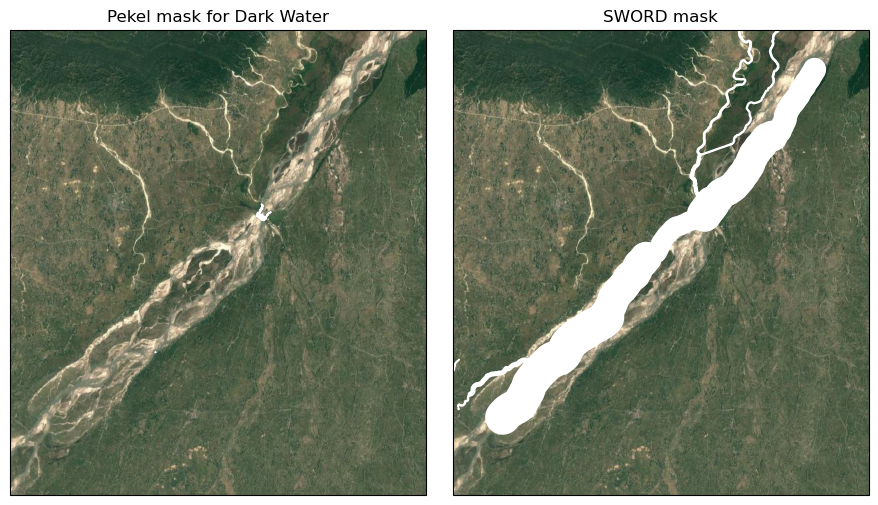

In [9]:
extent = [longitude_min, longitude_max, latitude_min, latitude_max]

fig = plt.figure(figsize=(9,5), layout='tight')
ax1 = fig.add_subplot(1, 2, 1, projection=tiler.crs)
ax1.set_title('Pekel mask for Dark Water')
ax1.set_extent(extent, geodetic)
ax1.add_image(tiler, 11)
ax1.add_geometries(pekel_X_100_poly, wgs84, edgecolor='white', facecolor='white')

if poly_sword is not None:
    ax2 = fig.add_subplot(1, 2, 2, projection=tiler.crs)
    ax2.set_title('SWORD mask')
    ax2.set_extent(extent, geodetic)
    ax2.add_image(tiler, 11)
    ax2.add_geometries(poly_sword, wgs84, edgecolor='white', facecolor='white')
    
plt.show()

Get the mask polygon if the user wants to reduce the studied region (use of Pekel, PLD or SWORD)

In [10]:
# Create the polygon mask needed for intersection with PIXC to limit the number of points
if use_mask == 1:
    print('PLD Mask intersection will be performed\n')
    polygon_mask = get_PLD_mask(lake_id, pld_path, inputpixcfiles[0])
elif use_mask == 2:
    print('Pekel Mask intersection will be performed\n')
    polygon_mask = extract_Pekel_polygon(data_pekel, occ_min=0, occ_max=100, bufsize=mask_buffer_size)
elif use_mask == 3:
    print('Sword Mask intersection will be performed\n')
    polygon_mask = get_poly_sword_from_reach(df_reach_data, buffer_size=mask_buffer_size)
else:
    polygon_mask = None

# Extracting bathymetry points from PIXC

Here is the main part of the notebook where the bathymetry points will be extracted for each PIXC in the list (previously determined).

For each PIXC, all PIXC points are labelized into 'water' bodies. On each body, we either apply the Bathtub Ring method or we categorize them into land, water or water-land depending on the option chosen by the user at the beginning of the notebook. For land bodies a direct extraction is performed. On water bodies the Bathtub Ring method is applied and on water-land bodies we clusterize them to separate water from land and then apply the Bathtub Ring method or do a direct extraction respectively.

At the end of the cell (still on each PIXC), the borders of the PIXC tiles are removed to eliminate false contours/bathymetries and some filtering based on quality flags is applied.

All PIXC results are merged into one single Dataframe.

2026-02-16 16:03:47,494 [INFO] PIXC: /work/SWOT/swotdev/swotdev/stephag/floodplain/run/testcase_Koshi/input/pixc/SWOT_L2_HR_PIXC_009_286_108L_20240114T081442_20240114T081453_PGC0_02.nc


Processing PIXC 1/2


2026-02-16 16:04:37,095 [INFO] Extract water points
2026-02-16 16:04:37,182 [INFO] Remove pixels too close to near_range
2026-02-16 16:04:40,125 [INFO] Extract contiguous water points by keeping only water bodies whose area is greater than threshold


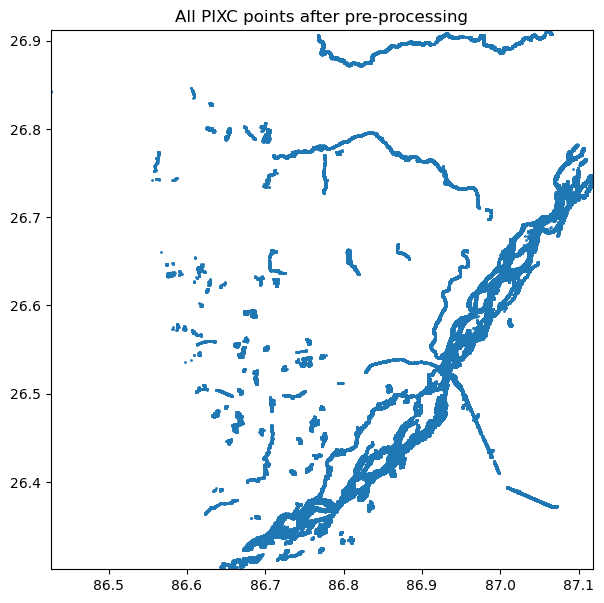

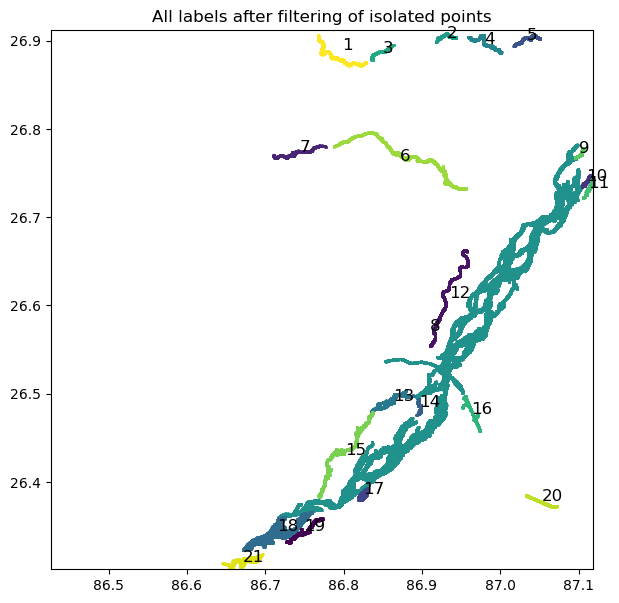

2026-02-16 16:04:48,781 [INFO] Ratio pekel, ratio sword: 0.8681727194738347, 0.9894195024306548
2026-02-16 16:04:48,782 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):14.779569625854492, -0.07225586473941803, -0.3169240653514862, -1.177088975906372, -0.5397253036499023, 0.9487935283200399, 0.984446500069622


Number of water bodies found : 21

Processing Label 1 / 21


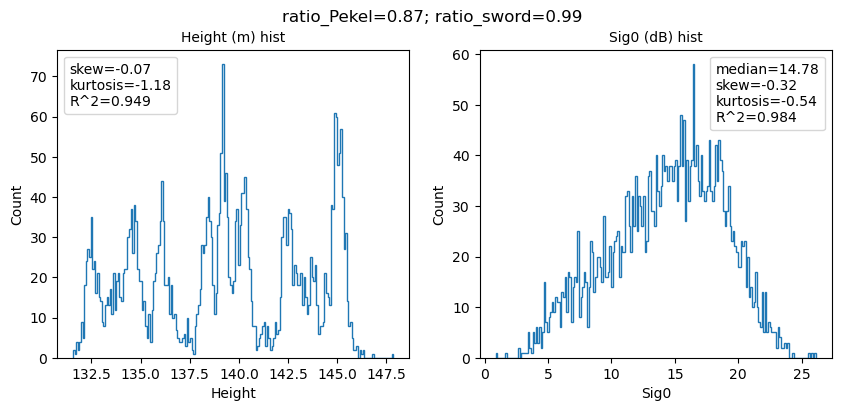

/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point 86.822435178344961 26.87271419106504
  return _ogr.Geometry_IsValid(self, *args)
2026-02-16 16:04:49,130 [INFO] Ratio pekel, ratio sword: 0.9151266255989049, 0.9945242984257358
2026-02-16 16:04:49,130 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):12.323135375976562, 0.36708885431289673, -0.30234643816947937, -0.7649691104888916, -0.40191197395324707, 0.9628366935271129, 0.9878197938659753


Body type: WATER
Bathtub ring method is applied

Processing Label 2 / 21


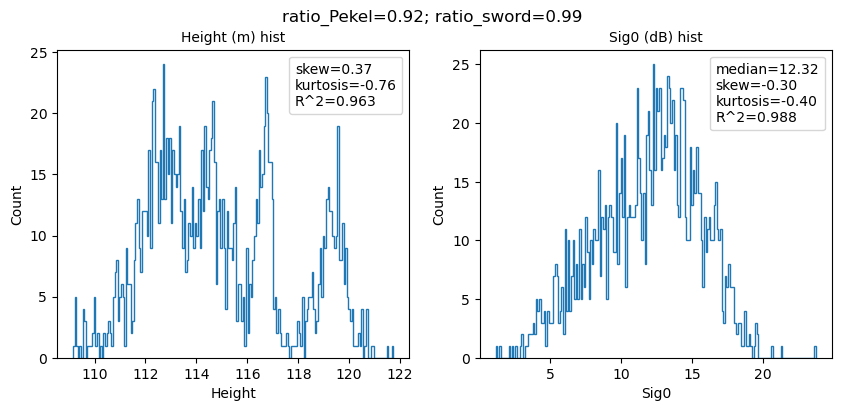

/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point 86.936493117852237 26.905177883862621
  return _ogr.Geometry_IsValid(self, *args)
2026-02-16 16:04:49,392 [INFO] Ratio pekel, ratio sword: 0.7958762886597938, 0.9780068728522336
2026-02-16 16:04:49,393 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):12.834333419799805, 0.42920681834220886, -0.220773845911026, -0.5933511257171631, -0.595365047454834, 0.9657607814255676, 0.9879442399784899


Body type: WATER
Bathtub ring method is applied

Processing Label 3 / 21


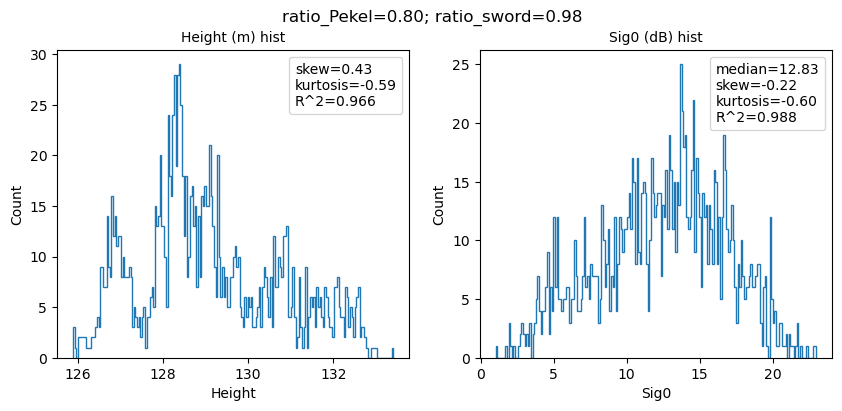

2026-02-16 16:04:49,656 [INFO] Ratio pekel, ratio sword: 0.8788927335640139, 0.9927335640138408
2026-02-16 16:04:49,656 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):11.561088562011719, 0.08731790632009506, -0.013781721703708172, -0.41449904441833496, -0.6020545959472656, 0.9788789369551497, 0.9934912643014201


Body type: WATER
Bathtub ring method is applied

Processing Label 4 / 21


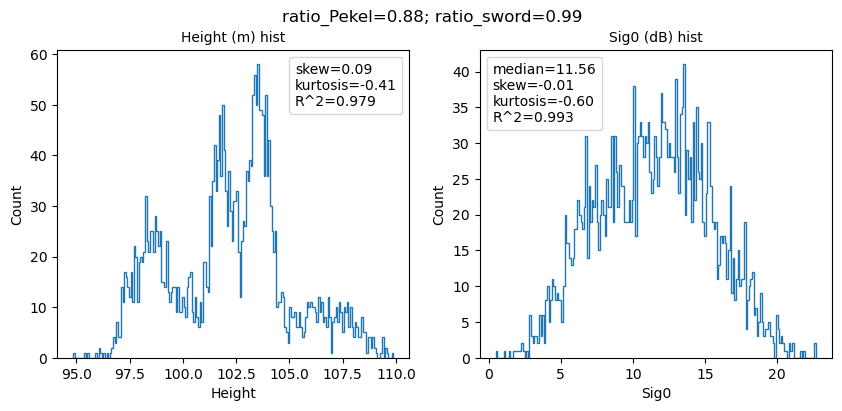

/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point 87.001075443126496 26.886661581350577
  return _ogr.Geometry_IsValid(self, *args)
2026-02-16 16:04:49,949 [INFO] Ratio pekel, ratio sword: 0.13018039980497317, 0.17016089712335447
2026-02-16 16:04:49,950 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):11.66611385345459, -0.36139124631881714, -0.1304181069135666, -0.8700158596038818, -0.477557897567749, 0.9603608649185948, 0.994384480741865


Body type: WATER
Bathtub ring method is applied

Processing Label 5 / 21


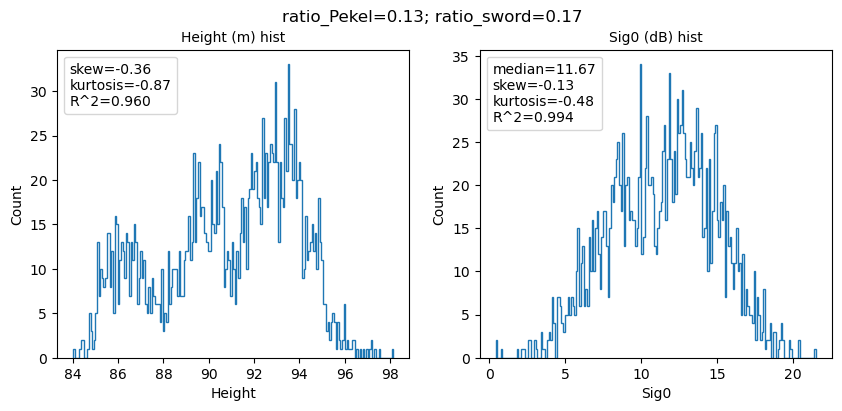

2026-02-16 16:04:50,212 [INFO] Ratio pekel, ratio sword: 0.814018430605976, 0.5339290700921531
2026-02-16 16:04:50,213 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):11.841801643371582, 0.23231267929077148, 0.036584481596946716, -0.7455289363861084, -0.7619369029998779, 0.9752196186005881, 0.9882023522694258


Body type: LAND

Processing Label 6 / 21


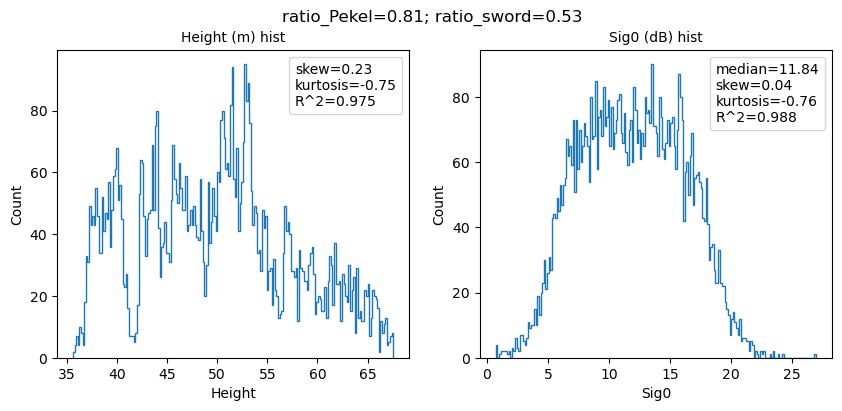

Body type: WATER
Bathtub ring method is applied

Processing Label 7 / 21


/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point 86.9336265471172 26.737826836679844
  return _ogr.Geometry_IsValid(self, *args)
2026-02-16 16:04:50,624 [INFO] Ratio pekel, ratio sword: 0.511400651465798, 0.20276872964169382
2026-02-16 16:04:50,625 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):12.326716423034668, 0.07137754559516907, 0.2570107877254486, -1.0377376079559326, -0.5114936828613281, 0.9695379251844569, 0.9857228072594939


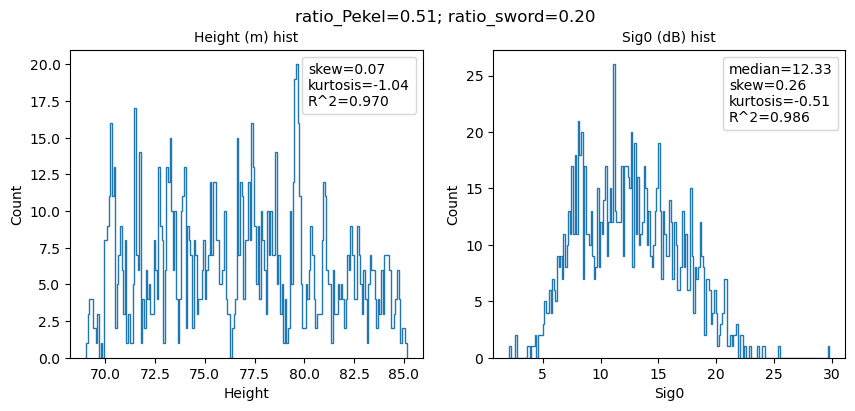

/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point 86.775565915318737 26.780566350065918
  return _ogr.Geometry_IsValid(self, *args)


Body type: WATER
Bathtub ring method is applied

Processing Label 8 / 21


/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
2026-02-16 16:04:51,273 [INFO] Ratio pekel, ratio sword: 0.792493499227245, 0.39104613140962435
2026-02-16 16:04:51,273 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):13.710886001586914, -0.16411066055297852, -0.10873565077781677, -0.9887831211090088, -0.47191524505615234, 0.9698378417274034, 0.9951321392783044


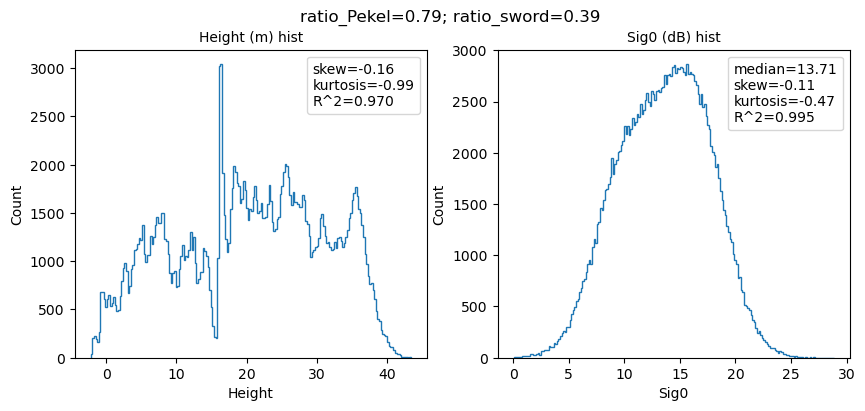

Body type: WATER
Bathtub ring method is applied


/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point 87.095319033598457 26.780122062633872
  return _ogr.Geometry_IsValid(self, *args)
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
2026-02-16 16:05:18,482 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-16 16:05:18,483 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):10.690185546875, 0.18090221285820007, -0.21973586082458496, -0.2126474380493164, 0.0350499153137207, 0.996281129707806, 0.9960576646999456



Processing Label 9 / 21


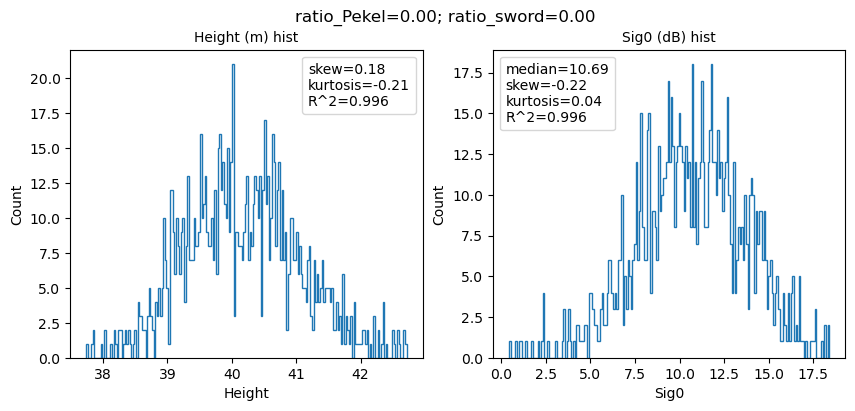

2026-02-16 16:05:18,745 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-16 16:05:18,746 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):11.689519882202148, 0.23981398344039917, -0.2992877960205078, -0.17223572731018066, -0.1363980770111084, 0.9949768116090885, 0.9932499984619392


Body type: LAND

Processing Label 10 / 21


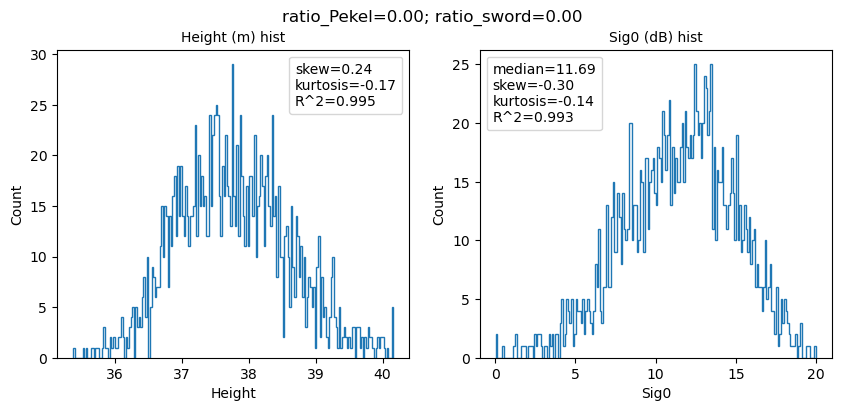

/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
2026-02-16 16:05:18,988 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-16 16:05:18,989 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):9.625143051147461, 0.0639786347746849, 0.15830644965171814, -0.24047613143920898, 0.026834964752197266, 0.9982186167807987, 0.9966771052471406


Body type: LAND

Processing Label 11 / 21


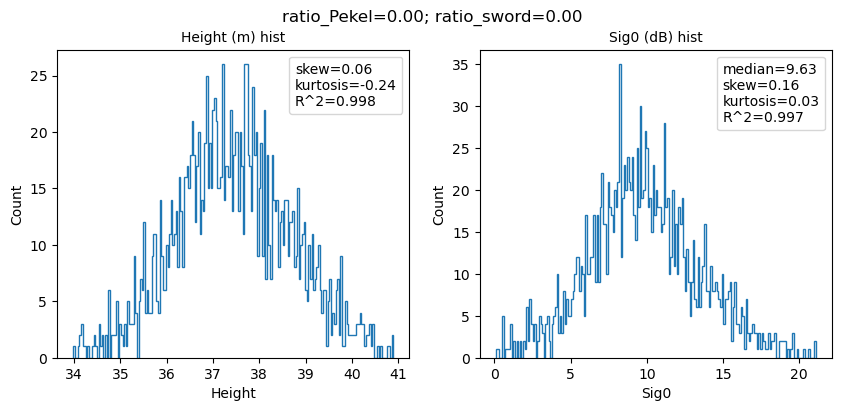

2026-02-16 16:05:19,248 [INFO] Ratio pekel, ratio sword: 0.8094638811980871, 0.3808205386357916
2026-02-16 16:05:19,248 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):12.535507202148438, 0.13185356557369232, -0.11269941180944443, -1.0702896118164062, -0.8358345031738281, 0.9668997576682365, 0.9836119636308434


Body type: LAND

Processing Label 12 / 21


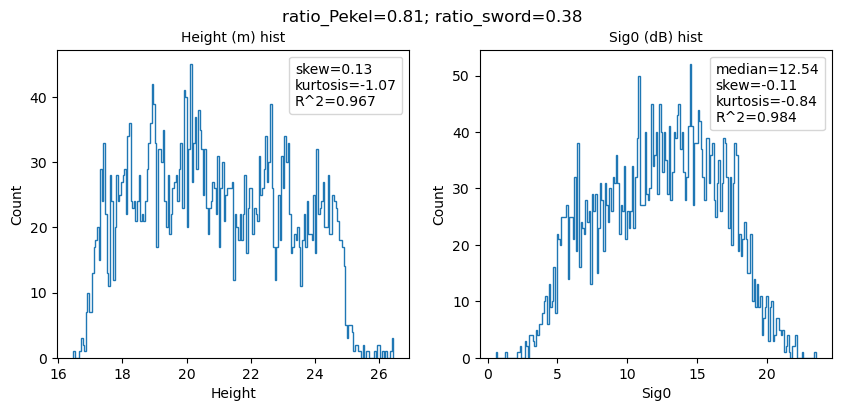

2026-02-16 16:05:19,578 [INFO] Ratio pekel, ratio sword: 0.918724279835391, 0.9931412894375857
2026-02-16 16:05:19,579 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):11.695703506469727, 0.01178191788494587, 0.23343096673488617, -0.6979243755340576, -0.7284049987792969, 0.9882297284690045, 0.9836131394393829


Body type: WATER
Bathtub ring method is applied

Processing Label 13 / 21


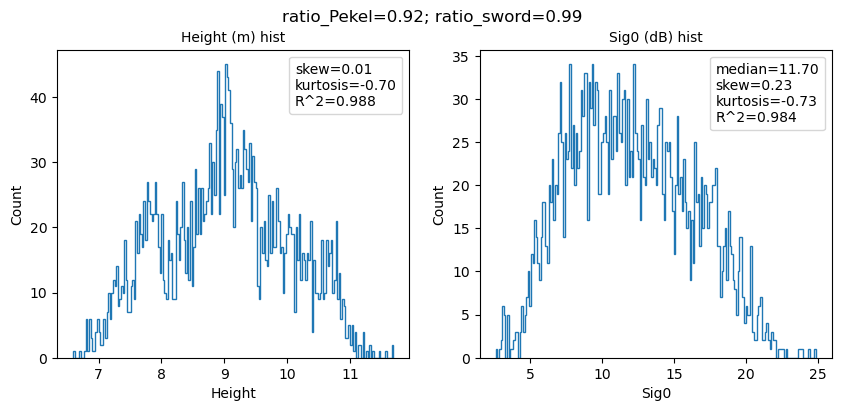

/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point 86.852631939063684 26.491051008261163
  return _ogr.Geometry_IsValid(self, *args)
2026-02-16 16:05:19,877 [INFO] Ratio pekel, ratio sword: 1.0, 0.0
2026-02-16 16:05:19,877 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):12.288575172424316, 0.19516336917877197, 0.11511354893445969, 0.3397254943847656, -0.934636116027832, 0.9920589773769645, 0.9793295661604786


Body type: WATER
Bathtub ring method is applied

Processing Label 14 / 21


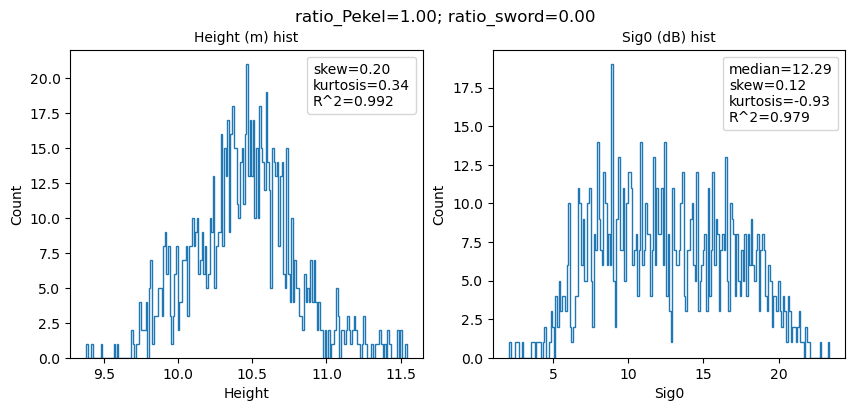

2026-02-16 16:05:20,152 [INFO] Ratio pekel, ratio sword: 0.9980174464710547, 0.8033306899286281
2026-02-16 16:05:20,153 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):12.433349609375, -0.03153246268630028, 0.23848743736743927, -1.223860740661621, -0.7794930934906006, 0.9520039559379221, 0.980855390025376


Body type: WATER
Bathtub ring method is applied

Processing Label 15 / 21


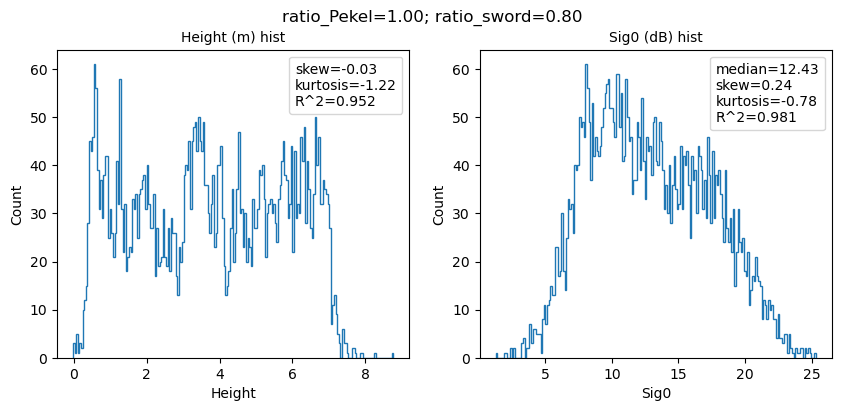

2026-02-16 16:05:20,502 [INFO] Ratio pekel, ratio sword: 0.708613317043372, 0.0
2026-02-16 16:05:20,503 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):10.58113956451416, 1.030068278312683, 0.23185473680496216, 1.443260669708252, -0.8830034732818604, 0.938141157033682, 0.9761027246816343


Body type: WATER
Bathtub ring method is applied

Processing Label 16 / 21


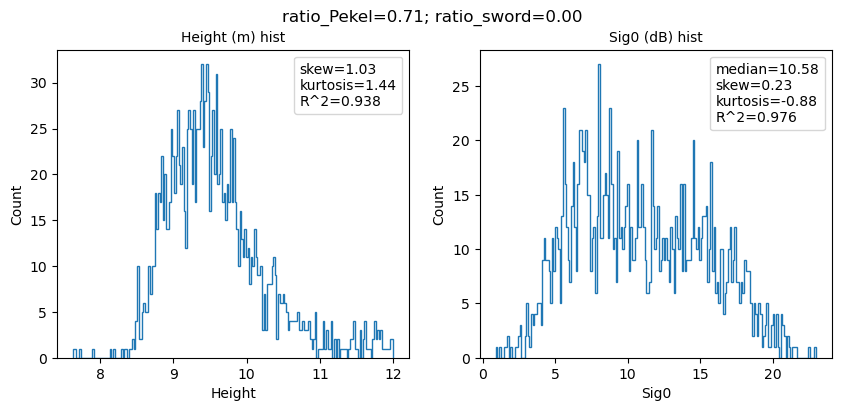

/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point 86.97354176492675 26.458113282552628
  return _ogr.Geometry_IsValid(self, *args)
2026-02-16 16:05:20,769 [INFO] Ratio pekel, ratio sword: 0.004164497657470068, 0.0
2026-02-16 16:05:20,770 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.959634780883789, 0.1336449831724167, -0.09145932644605637, -0.03732752799987793, 0.20104551315307617, 0.9970915487232286, 0.9956309853663446


Body type: WATER
Bathtub ring method is applied

Processing Label 17 / 21


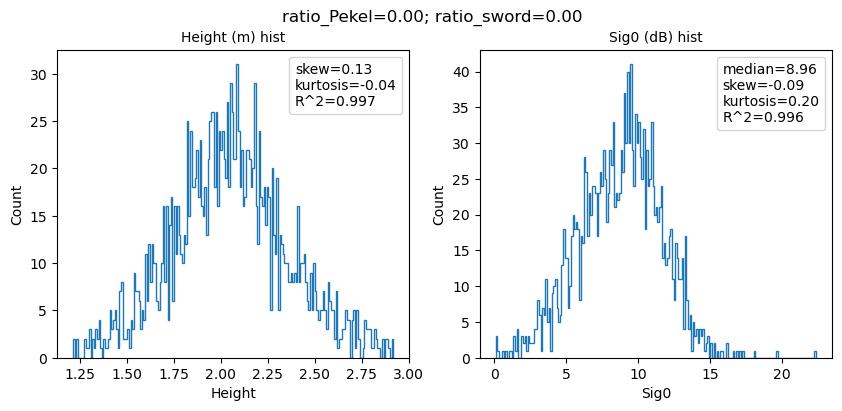

2026-02-16 16:05:21,041 [INFO] Ratio pekel, ratio sword: 0.9955656286953094, 0.956346078044935
2026-02-16 16:05:21,041 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):17.31734848022461, -0.047624487429857254, -0.11211037635803223, -0.5870139598846436, -0.8125951290130615, 0.9858642772774415, 0.9848824291963708


Body type: LAND

Processing Label 18 / 21


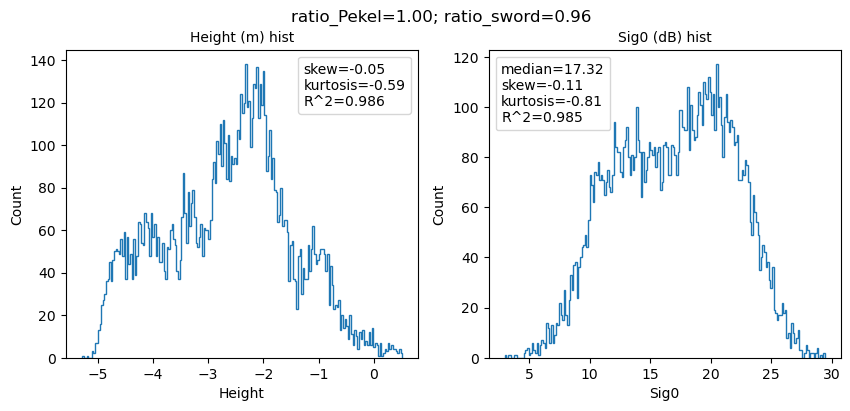

Body type: WATER
Bathtub ring method is applied

Processing Label 19 / 21


2026-02-16 16:05:21,421 [INFO] Ratio pekel, ratio sword: 0.996328029375765, 0.2215422276621787
2026-02-16 16:05:21,422 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):10.28331184387207, 0.09582638740539551, 0.668907880783081, -1.1767737865447998, 0.8808388710021973, 0.9586827629307759, 0.975951873244752


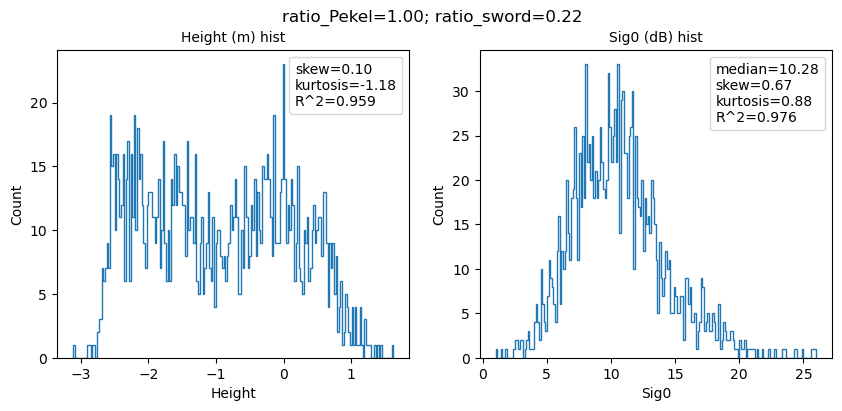

2026-02-16 16:05:21,686 [INFO] Ratio pekel, ratio sword: 0.8332194121667806, 0.0
2026-02-16 16:05:21,687 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):15.560697555541992, 0.15094080567359924, -0.5131719708442688, -0.00685882568359375, -0.3136930465698242, 0.996317723249307, 0.9729047433562898


Body type: WATER
Bathtub ring method is applied

Processing Label 20 / 21


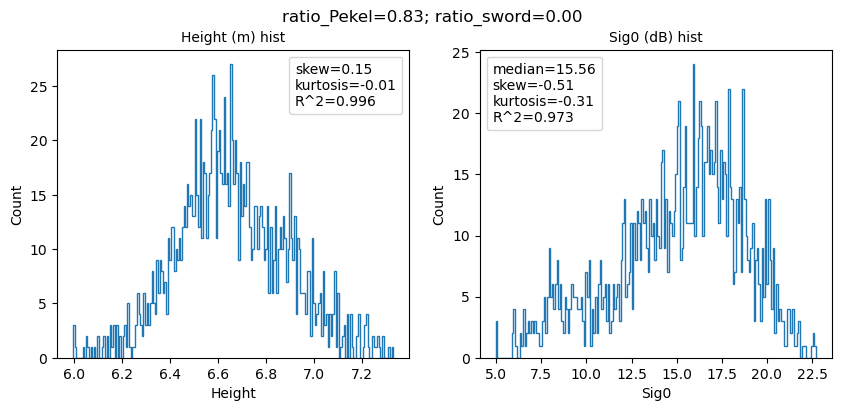

2026-02-16 16:05:21,958 [INFO] Ratio pekel, ratio sword: 0.894137734775185, 0.7455890722822994
2026-02-16 16:05:21,959 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):17.492538452148438, 0.9407418370246887, -0.14596128463745117, 0.22199034690856934, -0.6816315650939941, 0.9231131239153674, 0.9895129086466797


Body type: WATER
Bathtub ring method is applied

Processing Label 21 / 21


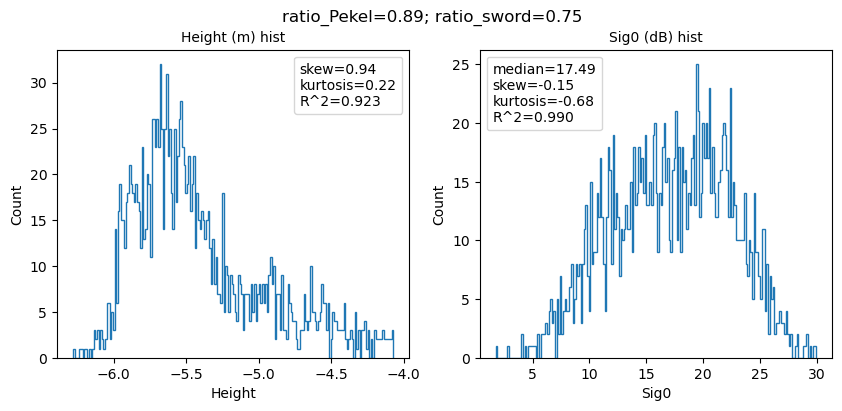

Body type: WATER
Bathtub ring method is applied


2026-02-16 16:06:15,719 [INFO] Filtering using flags
2026-02-16 16:06:22,363 [INFO] PIXC: /work/SWOT/swotdev/swotdev/stephag/floodplain/run/testcase_Koshi/input/pixc/SWOT_L2_HR_PIXC_020_286_108L_20240830T203033_20240830T203044_PIC0_01.nc


Processing PIXC 2/2


2026-02-16 16:08:10,497 [INFO] Extract water points
2026-02-16 16:08:10,801 [INFO] Remove pixels too close to near_range
2026-02-16 16:08:16,417 [INFO] Extract contiguous water points by keeping only water bodies whose area is greater than threshold


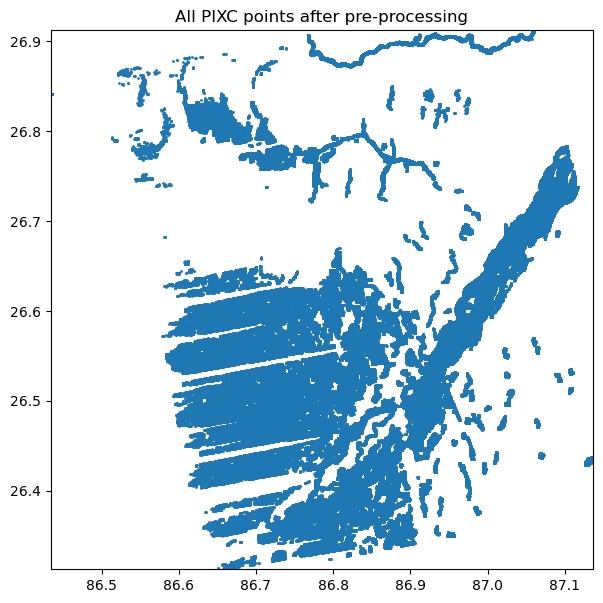

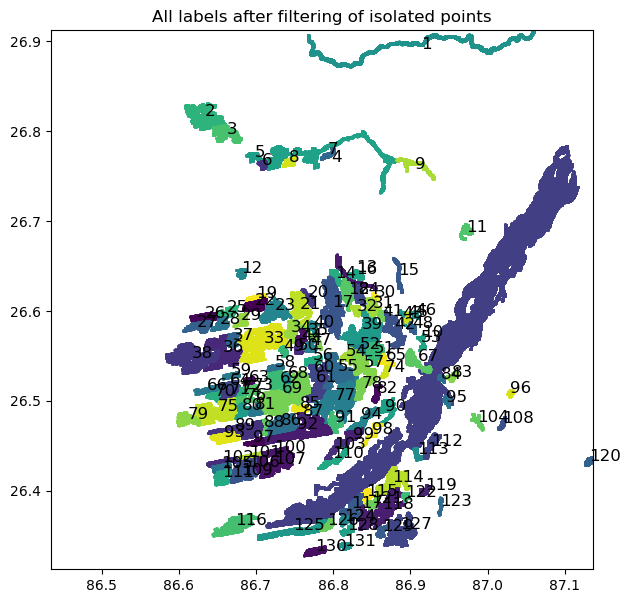

2026-02-16 16:08:47,771 [INFO] Ratio pekel, ratio sword: 0.6385399850376029, 0.837539866913415
2026-02-16 16:08:47,772 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):12.970684051513672, 0.04473607987165451, -0.15372209250926971, -1.2665694952011108, -0.2928633689880371, 0.9496918019322779, 0.9967617710908127


Number of water bodies found : 131

Processing Label 1 / 131


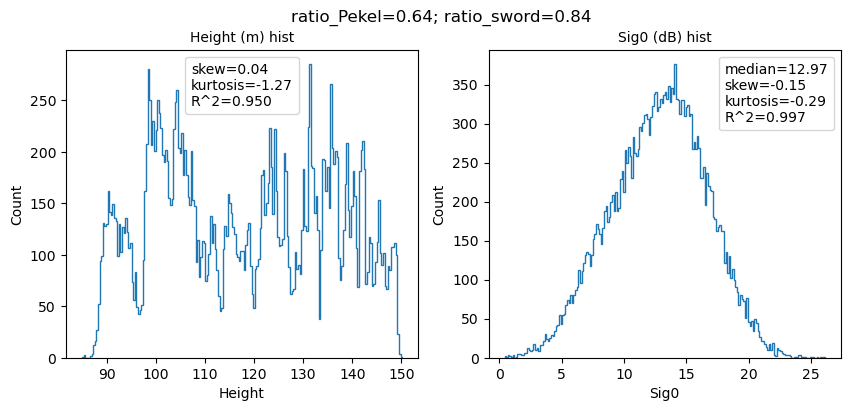

Body type: WATER
Bathtub ring method is applied


/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point 87.057660368195826 26.910102913056125
  return _ogr.Geometry_IsValid(self, *args)
2026-02-16 16:08:48,990 [INFO] Ratio pekel, ratio sword: 0.003430668581458433, 0.1235040689325036
2026-02-16 16:08:48,990 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):11.96029281616211, 0.4147386848926544, -0.1282595694065094, -0.48453712463378906, 0.2838308811187744, 0.974856776025482, 0.9982655239404649



Processing Label 2 / 131


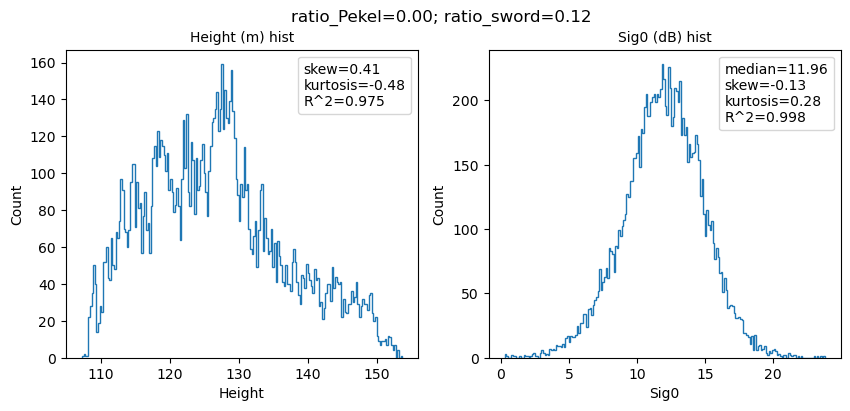

2026-02-16 16:08:49,251 [INFO] Ratio pekel, ratio sword: 0.005701615457713019, 0.10848907190370605
2026-02-16 16:08:49,251 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):10.216894149780273, 0.45931172370910645, -0.09424895793199539, -0.7906234264373779, 0.23607397079467773, 0.9509001286518083, 0.9984647567908855


Body type: LAND

Processing Label 3 / 131


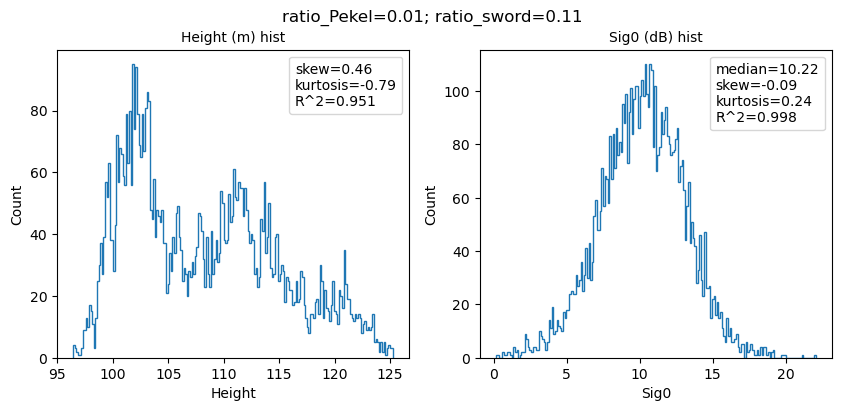

2026-02-16 16:08:49,538 [INFO] Ratio pekel, ratio sword: 0.3241303147432358, 0.22523969680236935
2026-02-16 16:08:49,538 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):10.450435638427734, -0.11007197201251984, 0.34234556555747986, -1.1275333166122437, -0.2282876968383789, 0.9570766016732071, 0.9883796770297281


Body type: LAND

Processing Label 4 / 131


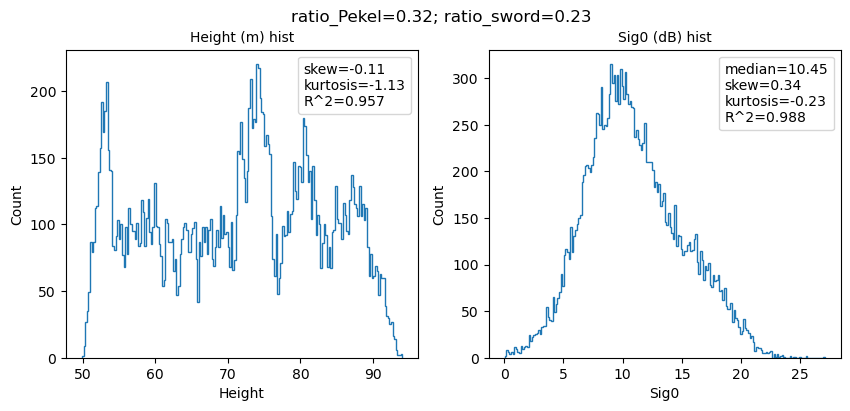

Body type: WATER
Bathtub ring method is applied


/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point 86.840798962996459 26.79683549589268
  return _ogr.Geometry_IsValid(self, *args)
2026-02-16 16:08:50,425 [INFO] Ratio pekel, ratio sword: 0.00088261253309797, 0.0
2026-02-16 16:08:50,426 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.751426696777344, 0.47603756189346313, -0.3101540803909302, -0.5982663631439209, 0.11325788497924805, 0.9625116846622592, 0.9929729207615856



Processing Label 5 / 131


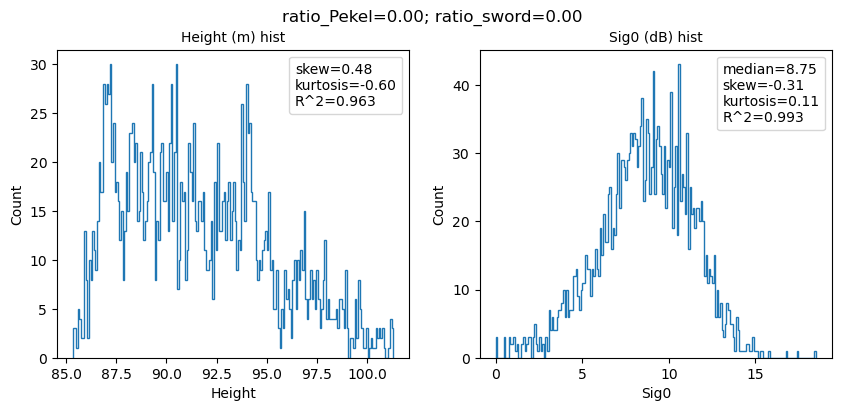

2026-02-16 16:08:50,687 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-16 16:08:50,687 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.388704299926758, 0.25178757309913635, -0.1026262640953064, -0.7272272109985352, 0.14291858673095703, 0.9821062872770555, 0.9950946215838545


Body type: LAND

Processing Label 6 / 131


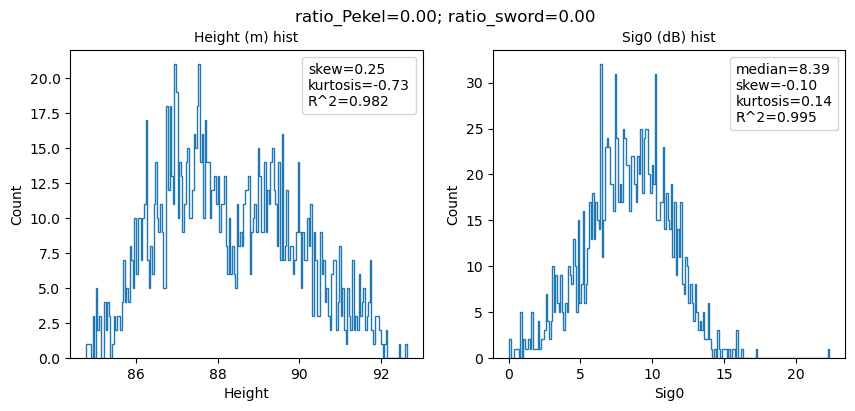

2026-02-16 16:08:50,957 [INFO] Ratio pekel, ratio sword: 0.003304692663582287, 0.0
2026-02-16 16:08:50,958 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):7.7020721435546875, 0.3010956943035126, -0.25085434317588806, 0.015496253967285156, -0.1680450439453125, 0.9810437775980723, 0.9948830129615407


Body type: LAND

Processing Label 7 / 131


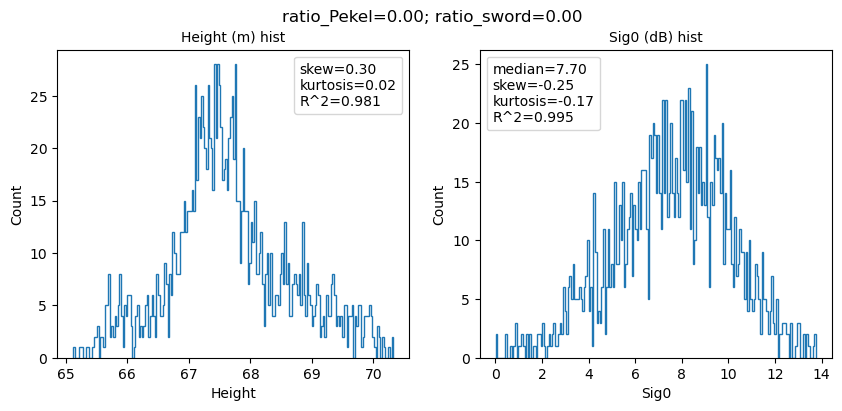

2026-02-16 16:08:51,218 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-16 16:08:51,218 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):7.999671459197998, 0.25725629925727844, -0.24787776172161102, -0.6854543685913086, -0.08007621765136719, 0.9827406066548946, 0.9945037821322361


Body type: LAND

Processing Label 8 / 131


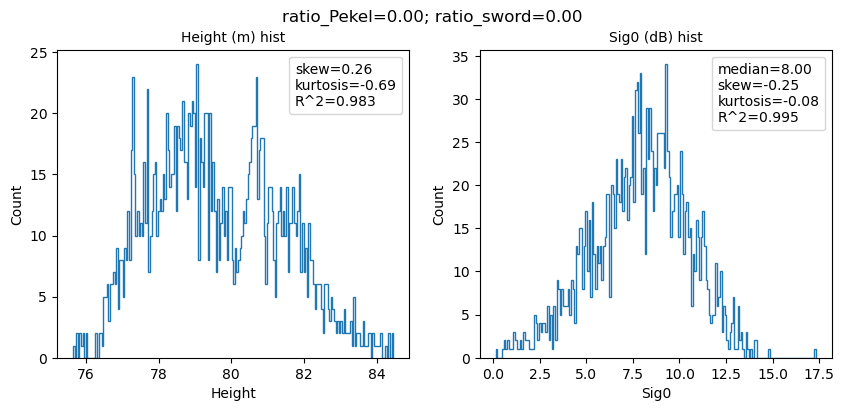

2026-02-16 16:08:51,485 [INFO] Ratio pekel, ratio sword: 0.7578487578487578, 0.4133224133224133
2026-02-16 16:08:51,485 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):11.968284606933594, 0.17975258827209473, -0.018092846497893333, -0.5716137886047363, -0.5653510093688965, 0.9764322147308093, 0.9944041901151345


Body type: LAND

Processing Label 9 / 131


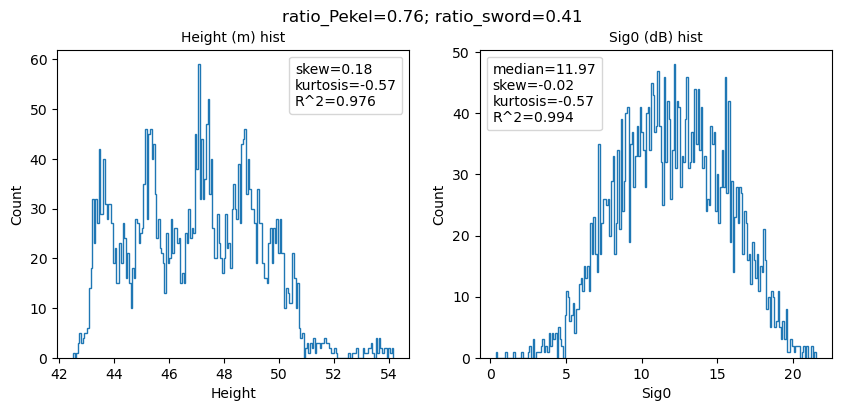

Body type: WATER
Bathtub ring method is applied

Processing Label 10 / 131


/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point 86.915665284545753 26.762735329341776
  return _ogr.Geometry_IsValid(self, *args)
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
2026-02-16 16:08:52,653 [INFO] Ratio pekel, ratio sword: 0.7436759149730036, 0.36369671472927406
2026-02-16 16:08:52,653 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):13.003231048583984, -0.17705568671226501, 0.02631196193397045, -1.062103271484375, -0.12432312965393066, 0.964100355130716, 0.9996309978953323


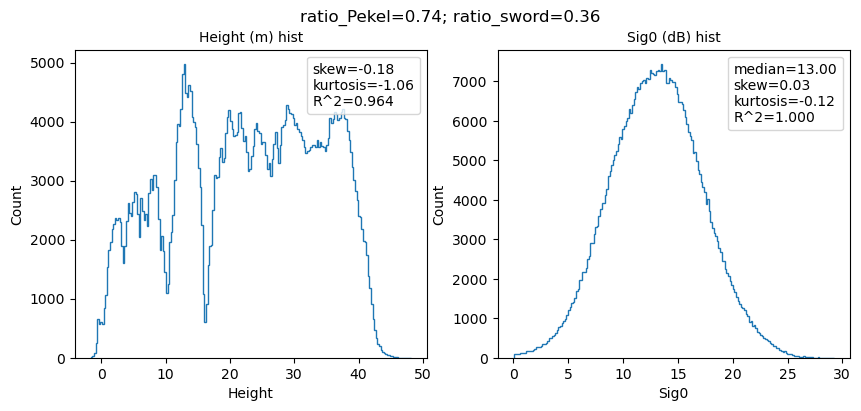

Body type: WATER
Bathtub ring method is applied


/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point 87.110980330657455 26.755126593730491
  return _ogr.Geometry_IsValid(self, *args)
2026-02-16 16:10:06,055 [INFO] Ratio pekel, ratio sword: 0.402901417738213, 0.09066930431915596
2026-02-16 16:10:06,056 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):9.034497261047363, -0.5283883213996887, 0.17271468043327332, 0.09116220474243164, 0.3176603317260742, 0.9729920181977263, 0.9969954626376348



Processing Label 11 / 131


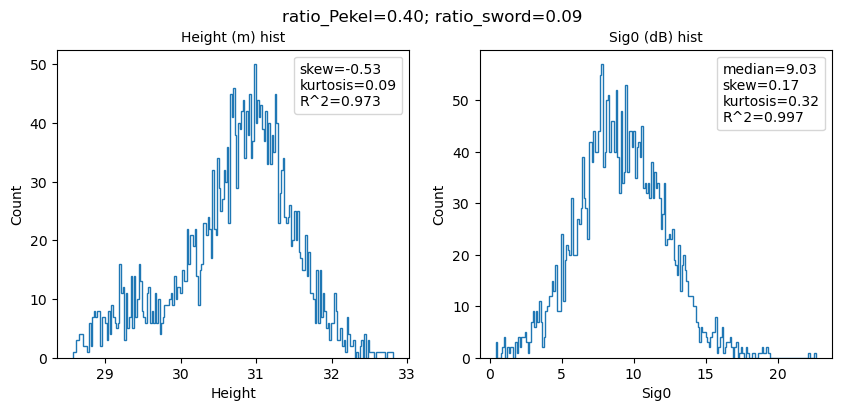

/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point 86.977454804722328 26.69057774419533
  return _ogr.Geometry_IsValid(self, *args)
2026-02-16 16:10:06,342 [INFO] Ratio pekel, ratio sword: 0.006750241080038573, 0.0
2026-02-16 16:10:06,343 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):13.292036056518555, 0.3340495228767395, 0.01111436914652586, -0.9048643112182617, -0.19960355758666992, 0.9642695393735405, 0.9984151716292368


Body type: WATER
Bathtub ring method is applied

Processing Label 12 / 131


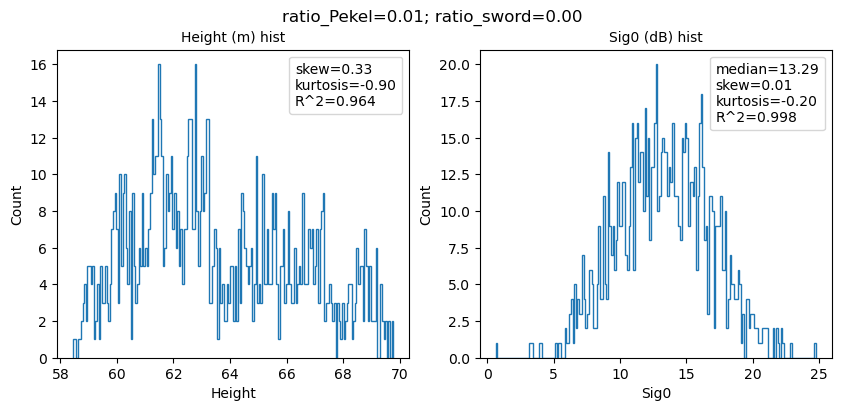

2026-02-16 16:10:06,620 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-16 16:10:06,621 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):11.910476684570312, 0.2000836730003357, 0.16448086500167847, -1.168520450592041, 0.35103607177734375, 0.9526272953472755, 0.997096732636074


Body type: LAND

Processing Label 13 / 131


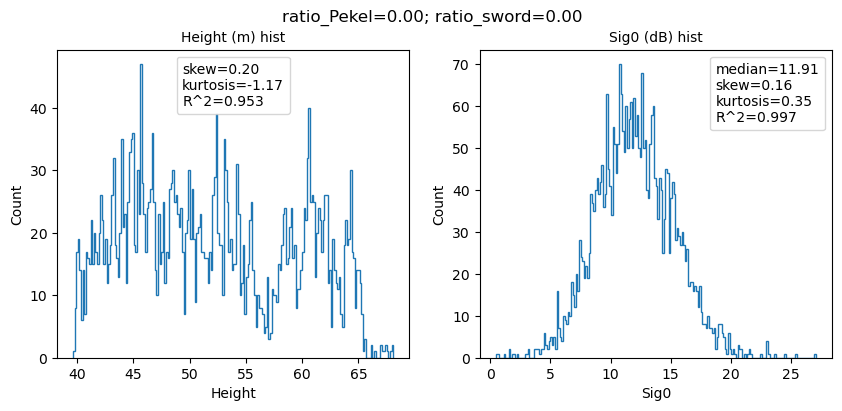

2026-02-16 16:10:06,884 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-16 16:10:06,884 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):7.8352508544921875, 0.2306615114212036, -0.20217406749725342, -0.8811616897583008, 0.02386760711669922, 0.9725106080983521, 0.9960120713908469


Body type: LAND

Processing Label 14 / 131


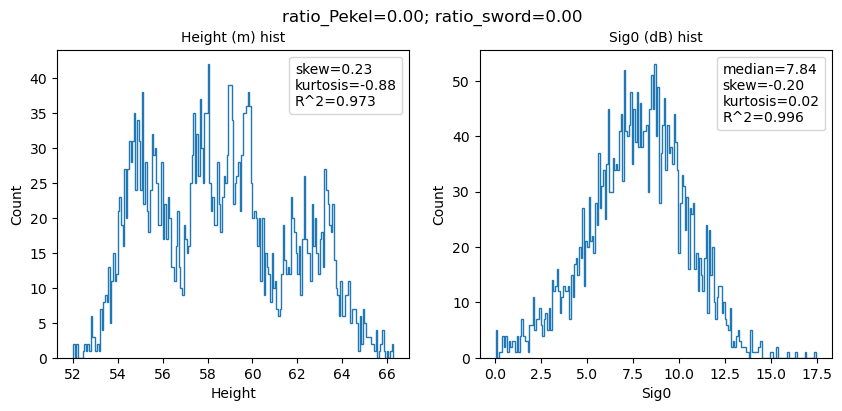

2026-02-16 16:10:07,165 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-16 16:10:07,165 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):9.761431694030762, 0.2702009975910187, 0.10233946144580841, -0.9919862747192383, -0.059478044509887695, 0.9543082072318003, 0.9987154676993187


Body type: LAND

Processing Label 15 / 131


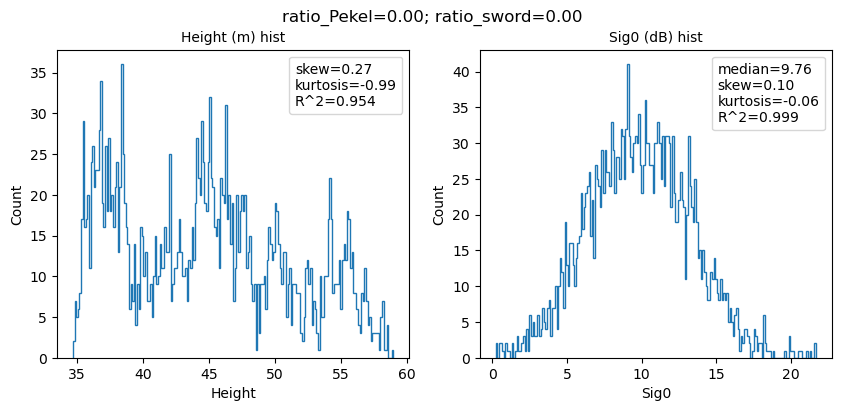

2026-02-16 16:10:07,435 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-16 16:10:07,435 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):7.880143165588379, 0.4222024977207184, -0.22494612634181976, 0.04361605644226074, 0.07822751998901367, 0.9812485794644372, 0.9961712615504871


Body type: LAND

Processing Label 16 / 131


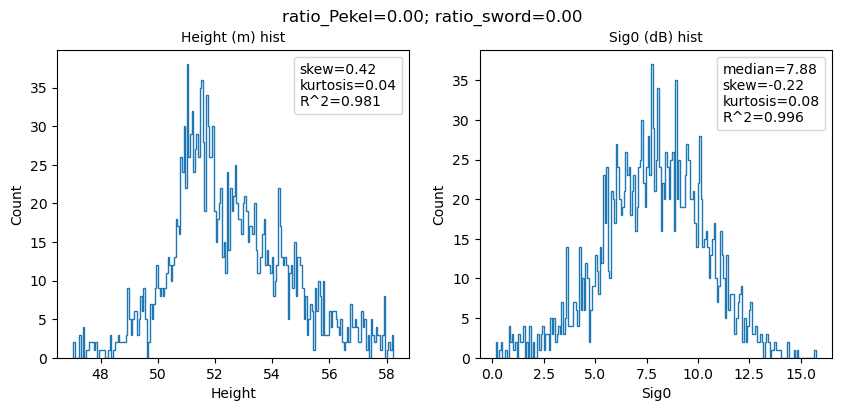

2026-02-16 16:10:07,742 [INFO] Ratio pekel, ratio sword: 0.00014778325123152708, 0.0
2026-02-16 16:10:07,743 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.073176383972168, 0.2857365906238556, -0.2120223343372345, -0.8504800796508789, -0.11549043655395508, 0.971519100689422, 0.9964371979832906


Body type: LAND

Processing Label 17 / 131


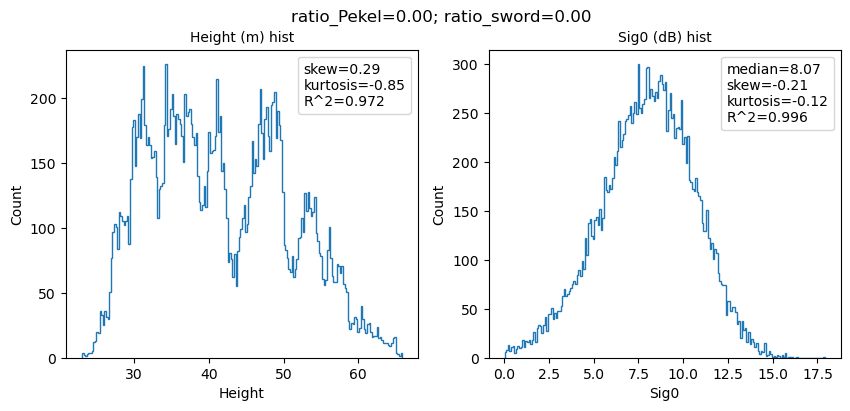

2026-02-16 16:10:08,017 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-16 16:10:08,018 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):7.6937384605407715, -0.2493477314710617, -0.18220290541648865, -0.5315923690795898, 0.09415602684020996, 0.9846773892275335, 0.9940858151523962


Body type: LAND

Processing Label 18 / 131


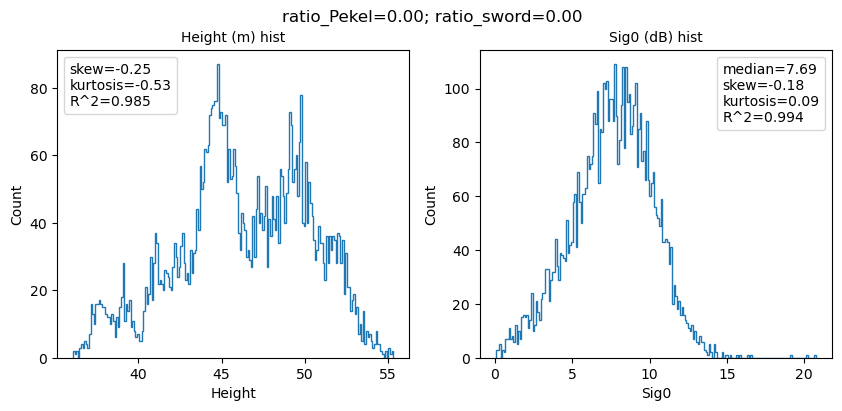

2026-02-16 16:10:08,266 [INFO] Ratio pekel, ratio sword: 0.0010857763300760044, 0.0
2026-02-16 16:10:08,267 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):13.173518180847168, -0.22031834721565247, -0.15301555395126343, -0.31934094429016113, -0.3290598392486572, 0.9903129384970772, 0.9965505080635229


Body type: LAND

Processing Label 19 / 131


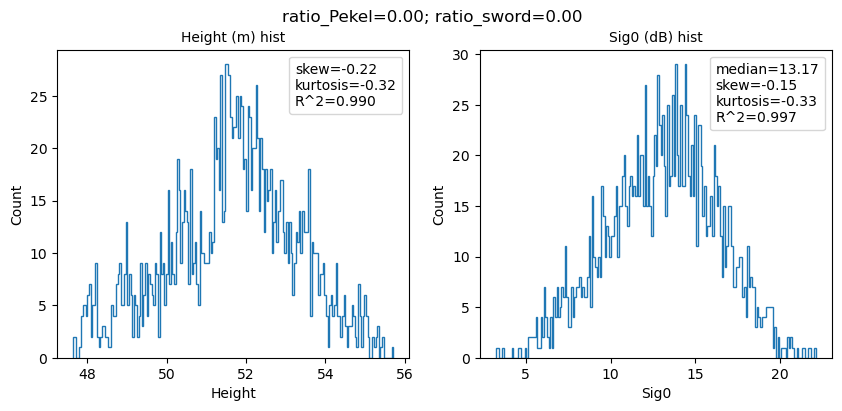

2026-02-16 16:10:08,525 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-16 16:10:08,526 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.34351634979248, 0.4634198546409607, -0.24469122290611267, -0.669990062713623, -0.09357500076293945, 0.9618037853648643, 0.9952311074108119


Body type: LAND

Processing Label 20 / 131


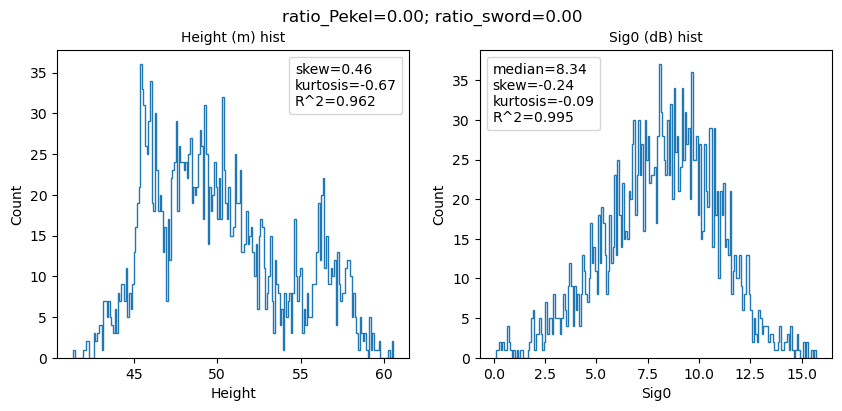

2026-02-16 16:10:08,803 [INFO] Ratio pekel, ratio sword: 0.006105316713304503, 0.0
2026-02-16 16:10:08,804 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.893149375915527, 0.2933006286621094, -0.11795900017023087, -0.7541687488555908, -0.08857965469360352, 0.9755820019008808, 0.9986775048609927


Body type: LAND

Processing Label 21 / 131


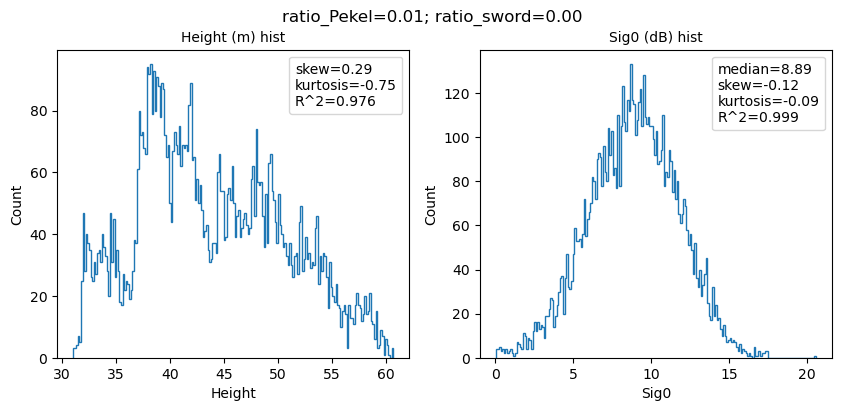

2026-02-16 16:10:09,062 [INFO] Ratio pekel, ratio sword: 0.015363128491620111, 0.0
2026-02-16 16:10:09,062 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):13.191584587097168, -0.0008364213281311095, -0.09049240499734879, -0.7588117122650146, -0.22141528129577637, 0.9873773514104431, 0.9986088729628257


Body type: LAND

Processing Label 22 / 131


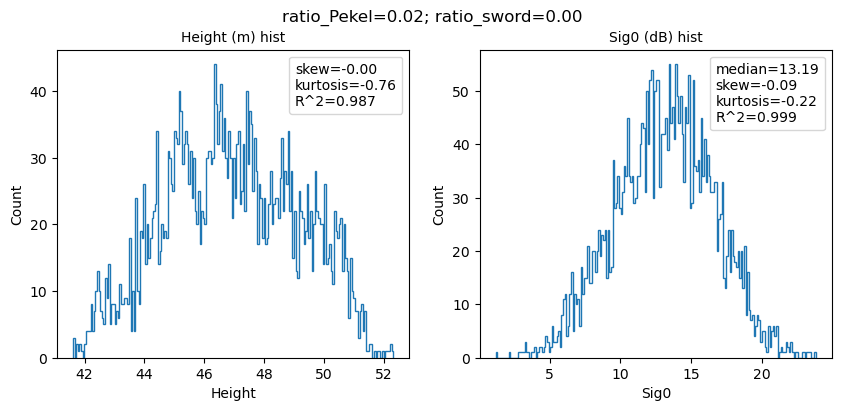

2026-02-16 16:10:09,320 [INFO] Ratio pekel, ratio sword: 0.0008616975441619991, 0.0
2026-02-16 16:10:09,320 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):10.654550552368164, 0.3365577757358551, -0.04289369657635689, -0.6322691440582275, -0.08841300010681152, 0.9798517054483333, 0.999606607490023


Body type: LAND

Processing Label 23 / 131


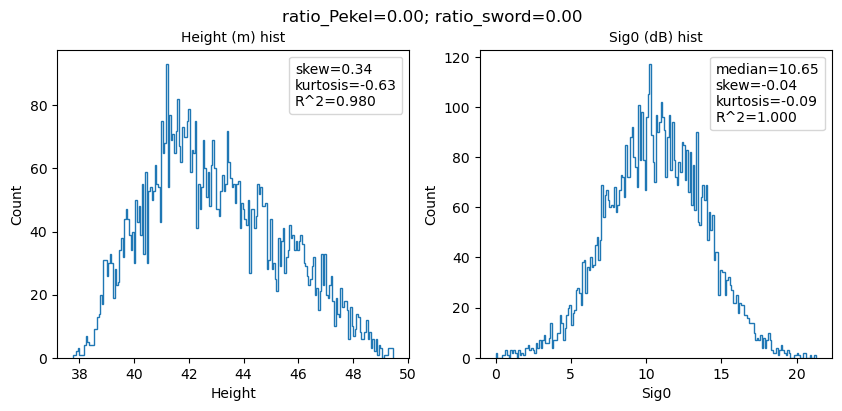

2026-02-16 16:10:09,581 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-16 16:10:09,582 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):7.615863800048828, -0.15612708032131195, -0.3199581801891327, -0.819443941116333, -0.08961820602416992, 0.9791717269353418, 0.9922655170051478


Body type: LAND

Processing Label 24 / 131


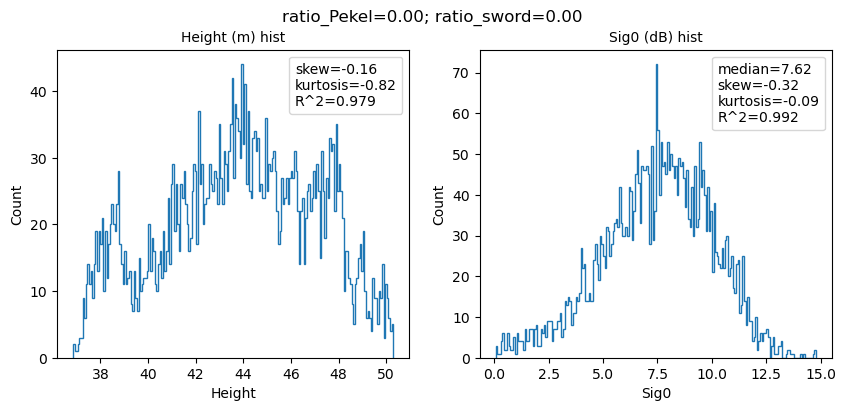

2026-02-16 16:10:09,847 [INFO] Ratio pekel, ratio sword: 0.004138644593895499, 0.0
2026-02-16 16:10:09,847 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):14.627433776855469, 0.5036760568618774, -0.06706739962100983, -0.724921703338623, -0.30468273162841797, 0.9544870180896262, 0.9977042291228446


Body type: LAND

Processing Label 25 / 131


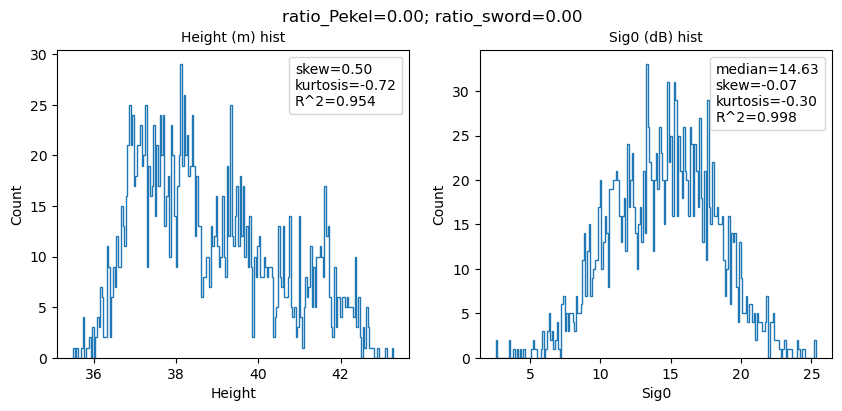

2026-02-16 16:10:10,105 [INFO] Ratio pekel, ratio sword: 0.0009350163627863488, 0.0
2026-02-16 16:10:10,106 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):15.359928131103516, -0.14730055630207062, -0.11225739121437073, -0.8437564373016357, -0.15917325019836426, 0.9803345905832768, 0.9983428304753177


Body type: LAND

Processing Label 26 / 131


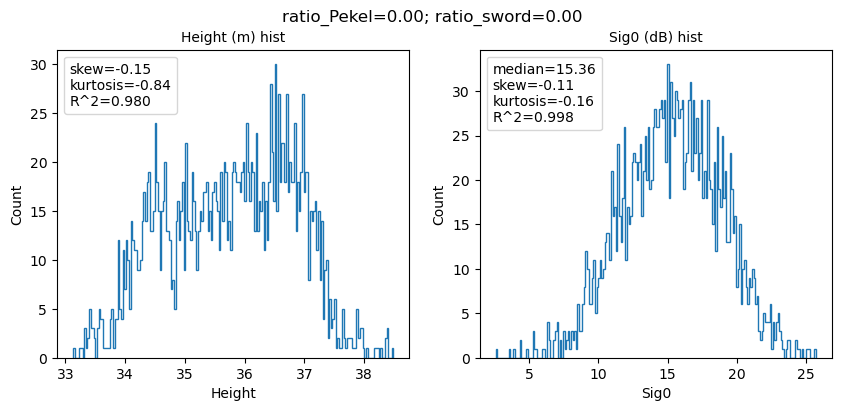

2026-02-16 16:10:10,373 [INFO] Ratio pekel, ratio sword: 0.0015779092702169625, 0.0
2026-02-16 16:10:10,374 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):14.309926986694336, -0.27788016200065613, -0.22255483269691467, -0.3740568161010742, -0.041741132736206055, 0.9908984653216499, 0.9964244589246523


Body type: LAND

Processing Label 27 / 131


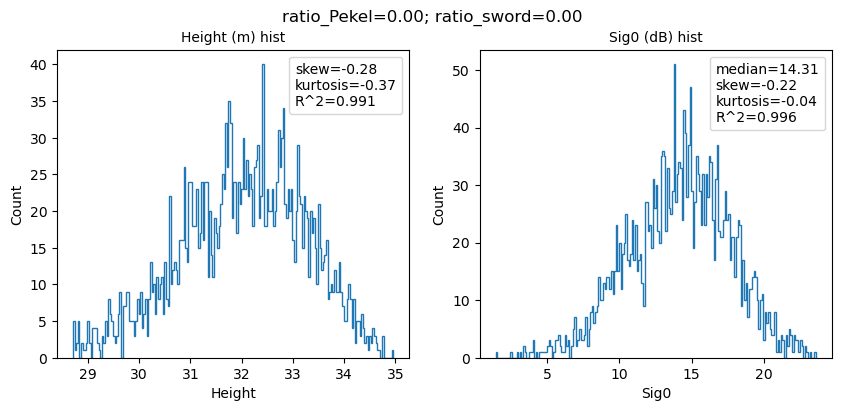

2026-02-16 16:10:10,638 [INFO] Ratio pekel, ratio sword: 0.0009376465072667605, 0.0
2026-02-16 16:10:10,639 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):15.169143676757812, 0.27927500009536743, -0.15386217832565308, -0.8833296298980713, -0.4096255302429199, 0.9710741325983429, 0.9956027957465688


Body type: LAND

Processing Label 28 / 131


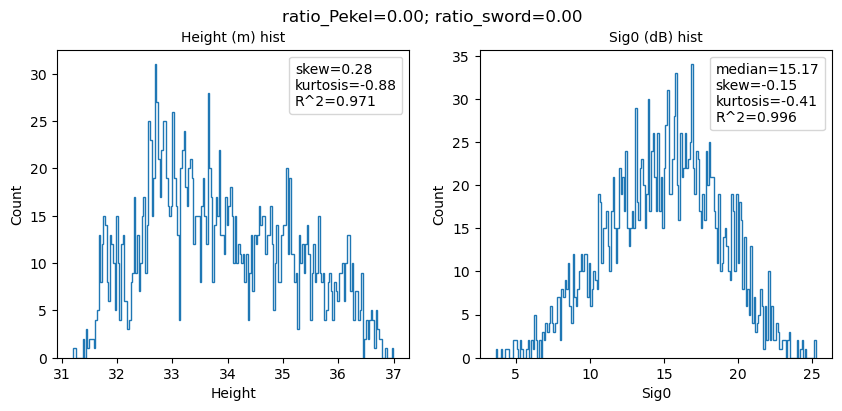

2026-02-16 16:10:10,905 [INFO] Ratio pekel, ratio sword: 0.04871955028107433, 0.0
2026-02-16 16:10:10,906 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):13.084612846374512, 0.368550181388855, 0.18960371613502502, -1.1885625123977661, 0.06148934364318848, 0.9248728970650423, 0.9972236562804322


Body type: LAND

Processing Label 29 / 131


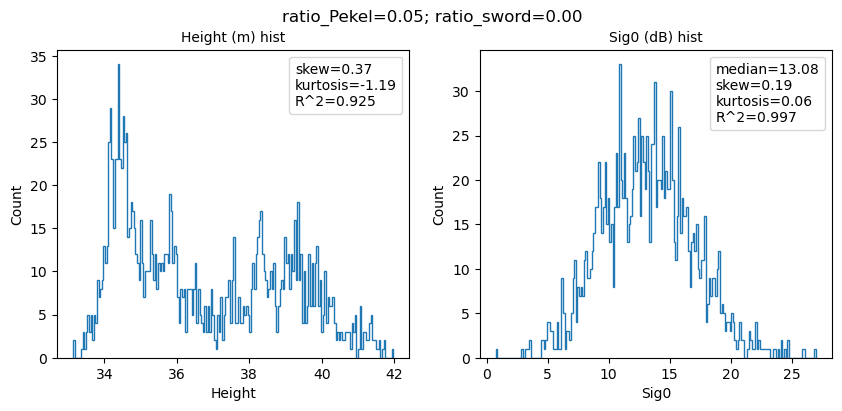

2026-02-16 16:10:11,166 [INFO] Ratio pekel, ratio sword: 0.020958083832335328, 0.0
2026-02-16 16:10:11,167 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):7.238894462585449, 0.26182737946510315, -0.02562638744711876, -0.418210506439209, 0.17489147186279297, 0.9876012417970946, 0.9967583683731049


Body type: LAND

Processing Label 30 / 131


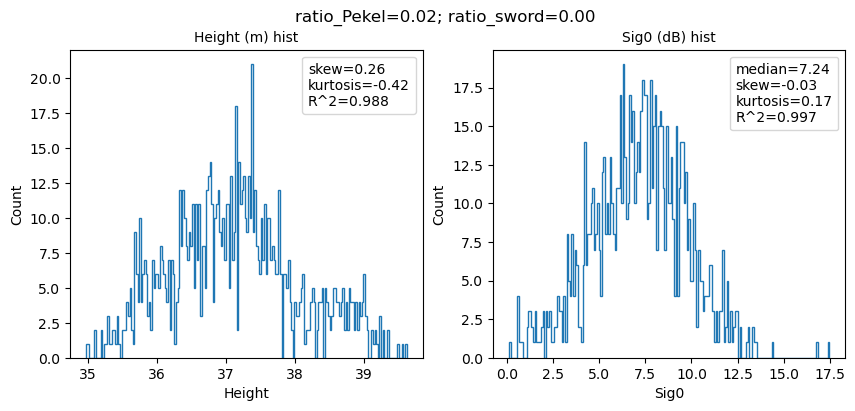

2026-02-16 16:10:11,459 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-16 16:10:11,459 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):7.572381496429443, 0.07046972215175629, -0.3174159526824951, -0.6654284000396729, -0.1437084674835205, 0.989649018747678, 0.9918446656889415


Body type: LAND

Processing Label 31 / 131


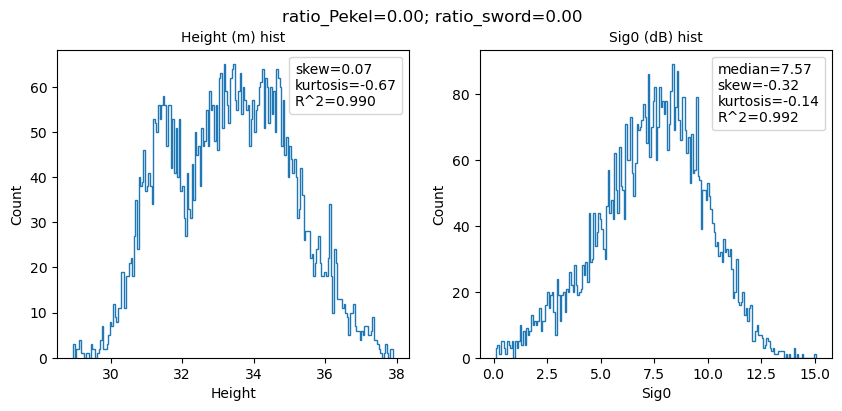

2026-02-16 16:10:11,715 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-16 16:10:11,715 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):7.858421802520752, 0.23456484079360962, -0.1932690143585205, -0.751042366027832, -0.00933074951171875, 0.981776727972166, 0.9968272082803902


Body type: LAND

Processing Label 32 / 131


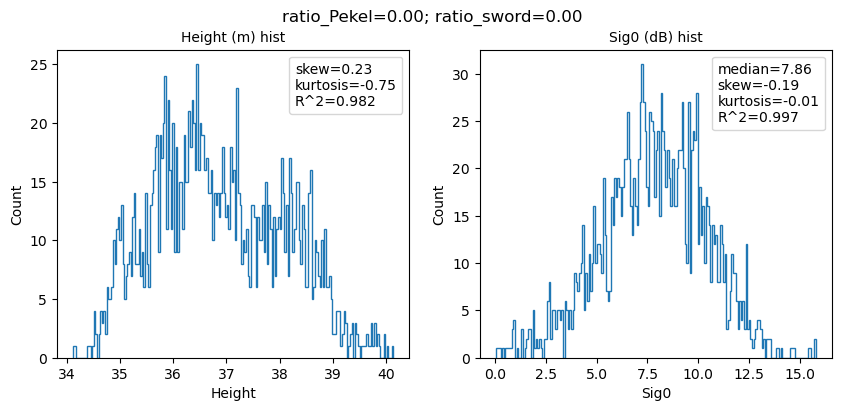

2026-02-16 16:10:12,011 [INFO] Ratio pekel, ratio sword: 0.0028907701837703904, 0.0
2026-02-16 16:10:12,011 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):12.388216018676758, -0.10783813148736954, 0.058751802891492844, -0.8396670818328857, -0.14764046669006348, 0.977362964294754, 0.9993187808455801


Body type: LAND

Processing Label 33 / 131


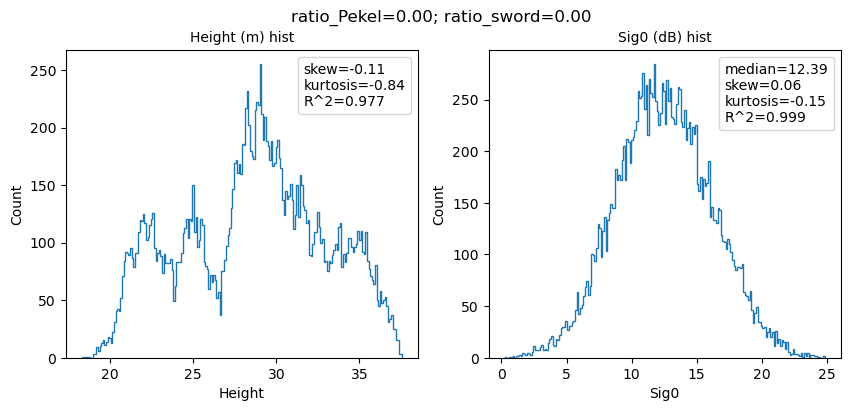

2026-02-16 16:10:12,270 [INFO] Ratio pekel, ratio sword: 0.00022977941176470588, 0.0
2026-02-16 16:10:12,271 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):9.150642395019531, 0.0593625046312809, -0.15260720252990723, -0.5390579700469971, -0.06857633590698242, 0.9931495131819872, 0.997979426098931


Body type: LAND

Processing Label 34 / 131


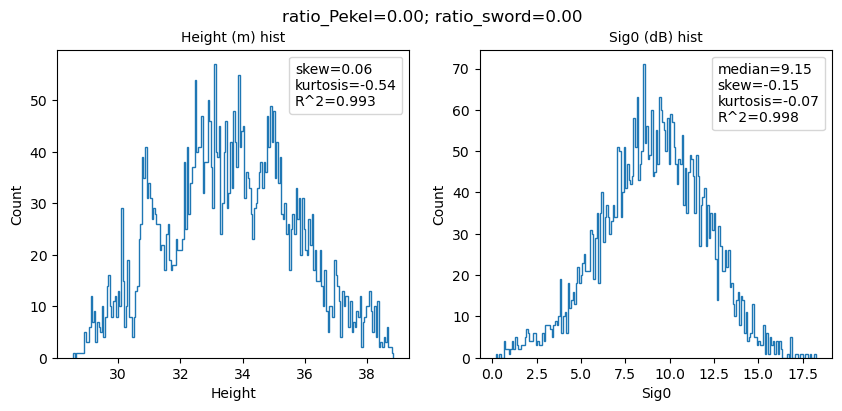

2026-02-16 16:10:12,547 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-16 16:10:12,548 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):10.743727684020996, -0.009749861434102058, 0.1587749719619751, -1.2602559328079224, -0.5301141738891602, 0.9524576521327716, 0.99292234945204


Body type: LAND

Processing Label 35 / 131


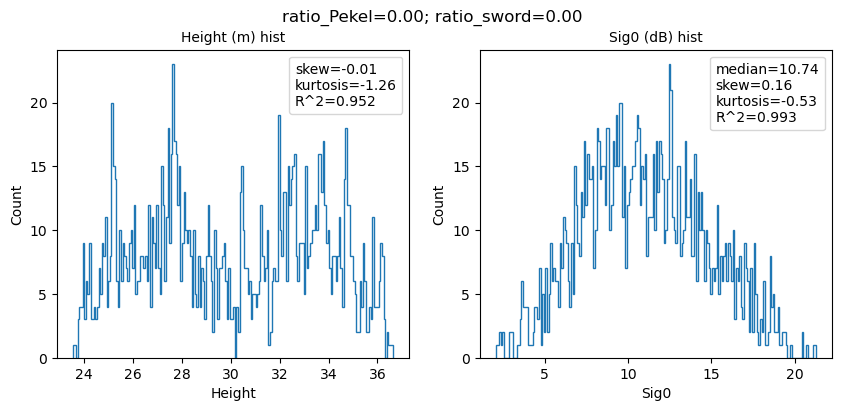

2026-02-16 16:10:12,812 [INFO] Ratio pekel, ratio sword: 0.0016313213703099511, 0.0
2026-02-16 16:10:12,813 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):15.546602249145508, 0.14755789935588837, -0.16917675733566284, -0.6537249088287354, -0.3477635383605957, 0.9884914495661992, 0.9958067794147991


Body type: LAND

Processing Label 36 / 131


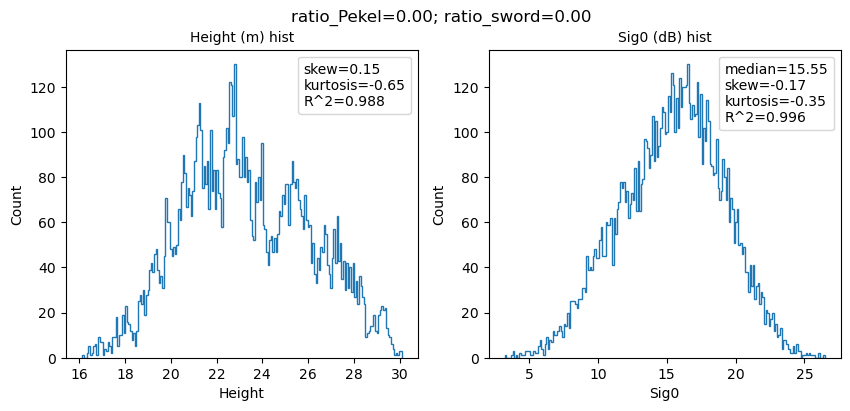

2026-02-16 16:10:13,078 [INFO] Ratio pekel, ratio sword: 0.0030135610246107484, 0.0
2026-02-16 16:10:13,079 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):14.964634895324707, -0.04651452600955963, -0.20431311428546906, -0.9123826026916504, -0.1014561653137207, 0.9796780242907872, 0.9968924121496439


Body type: LAND

Processing Label 37 / 131


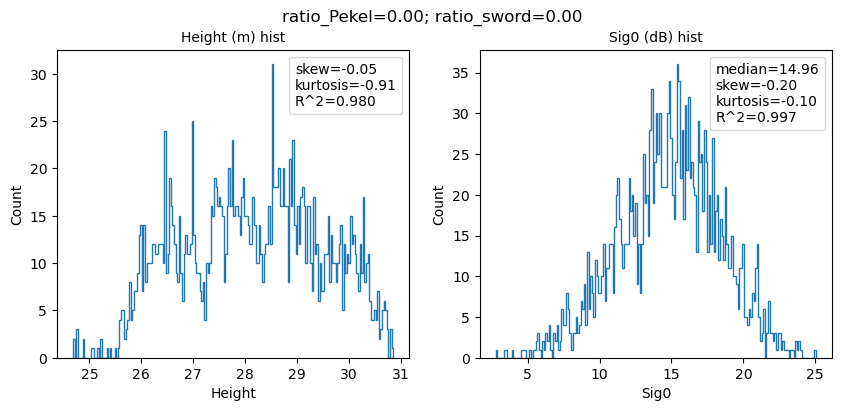

2026-02-16 16:10:13,360 [INFO] Ratio pekel, ratio sword: 0.004334496246960567, 0.0
2026-02-16 16:10:13,360 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):15.005672454833984, -0.16723550856113434, -0.20022815465927124, -0.6350324153900146, -0.012614250183105469, 0.9881680124754268, 0.9973821038307111


Body type: LAND

Processing Label 38 / 131


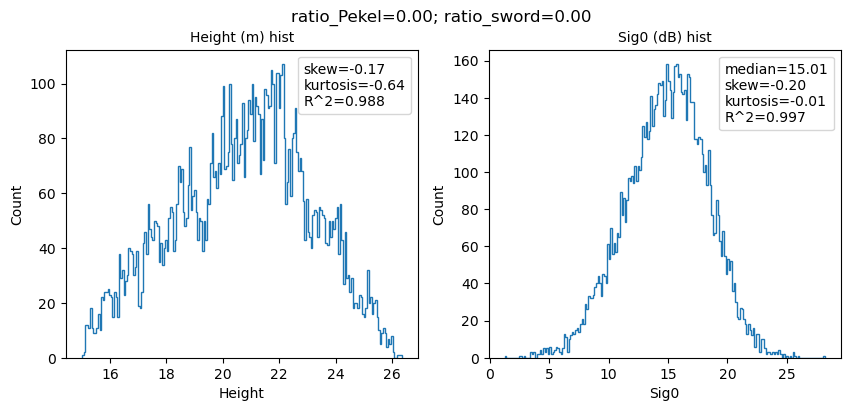

2026-02-16 16:10:13,672 [INFO] Ratio pekel, ratio sword: 0.0005062650297430705, 0.0
2026-02-16 16:10:13,673 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):7.75532341003418, 0.4982711970806122, -0.2574407458305359, -0.11006617546081543, -0.06818604469299316, 0.9787171687979059, 0.9950159830334634


Body type: LAND

Processing Label 39 / 131


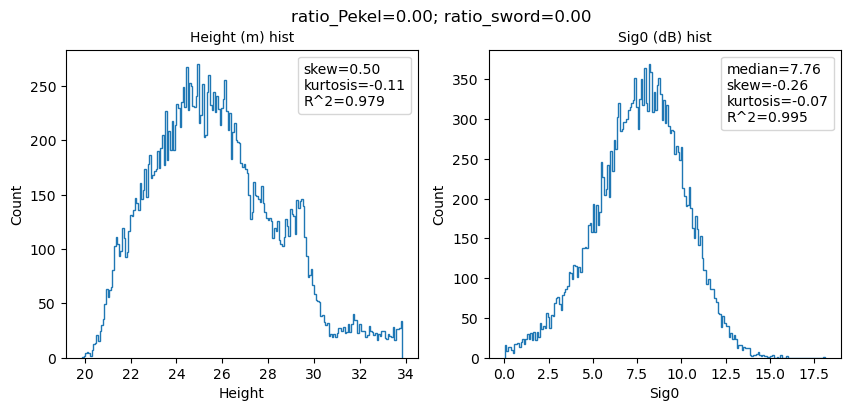

2026-02-16 16:10:13,954 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-16 16:10:13,955 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.339578628540039, -0.10922522842884064, -0.1658739447593689, -0.2040243148803711, 0.1514585018157959, 0.9939051767794674, 0.9971328901402918


Body type: LAND

Processing Label 40 / 131


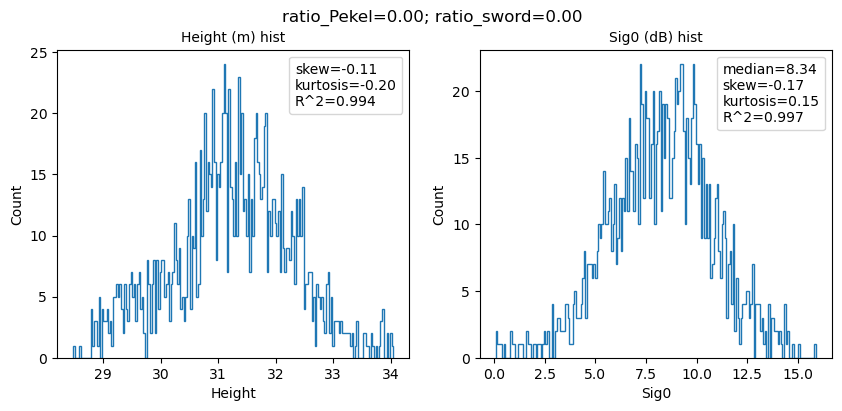

2026-02-16 16:10:14,216 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-16 16:10:14,217 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):7.751648902893066, -0.3045278787612915, -0.26087042689323425, -0.5875506401062012, 0.17099285125732422, 0.9784813193133494, 0.9941580118418113


Body type: LAND

Processing Label 41 / 131


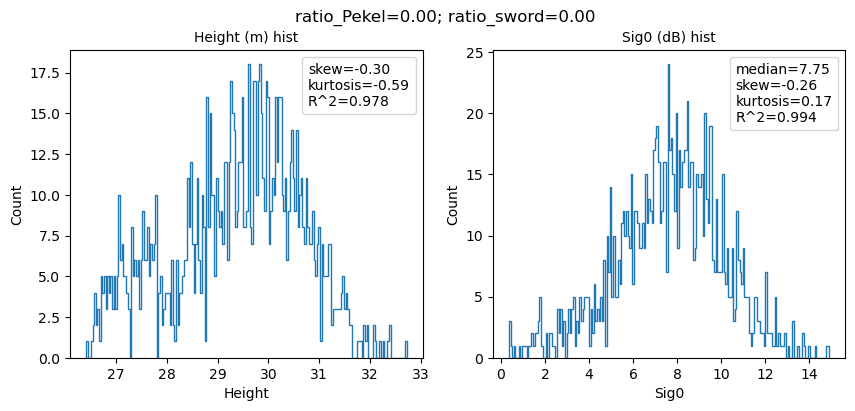

2026-02-16 16:10:14,512 [INFO] Ratio pekel, ratio sword: 0.00041649312786339027, 0.0
2026-02-16 16:10:14,512 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):7.509831428527832, 0.16391289234161377, -0.2741614878177643, -0.7999770641326904, -0.13951349258422852, 0.9813337425209938, 0.9937374462551565


Body type: LAND

Processing Label 42 / 131


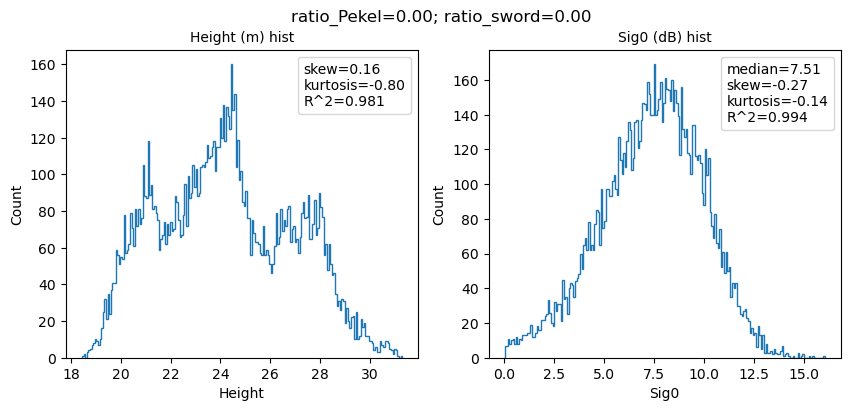

2026-02-16 16:10:14,795 [INFO] Ratio pekel, ratio sword: 0.022708158116063918, 0.0
2026-02-16 16:10:14,795 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):11.475122451782227, -0.035634033381938934, 0.0200521107763052, -1.1178377866744995, 0.14384198188781738, 0.965696902716395, 0.9988688701855587


Body type: LAND

Processing Label 43 / 131


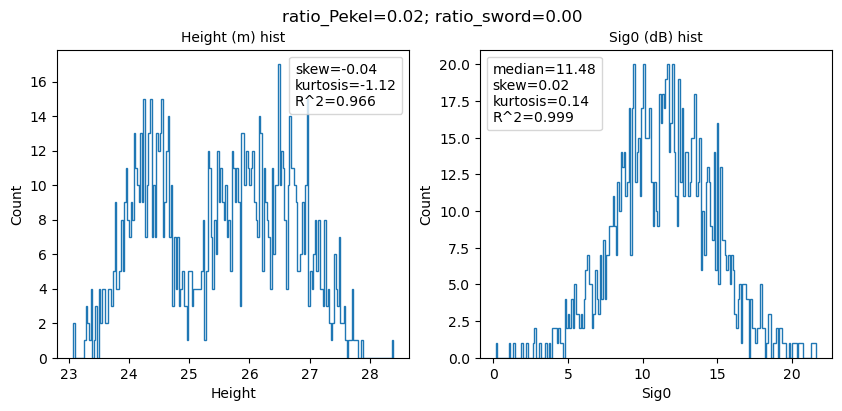

2026-02-16 16:10:15,084 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-16 16:10:15,085 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):9.842269897460938, -0.00261447811499238, -0.2003256231546402, -0.532463550567627, -0.20515918731689453, 0.9903435520186827, 0.9964570849356342


Body type: LAND

Processing Label 44 / 131


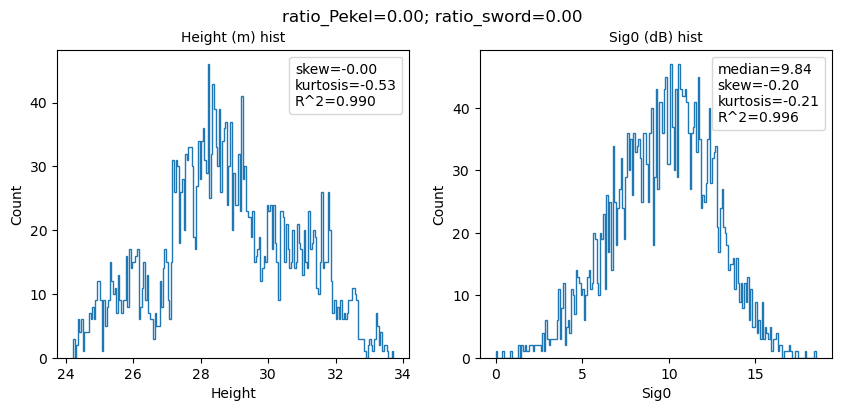

2026-02-16 16:10:15,343 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-16 16:10:15,343 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):7.666668891906738, 0.22061385214328766, -0.26676371693611145, -0.2960529327392578, -0.11820340156555176, 0.9945783175969404, 0.9935748264534067


Body type: LAND

Processing Label 45 / 131


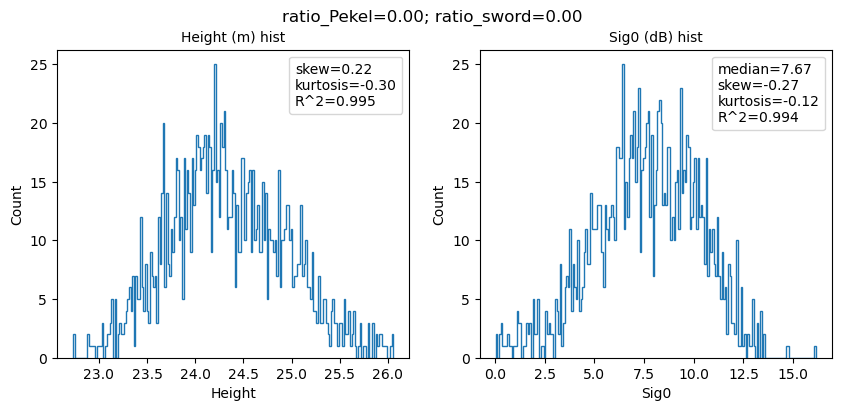

2026-02-16 16:10:15,606 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-16 16:10:15,606 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):7.65132999420166, -0.23976369202136993, -0.27257728576660156, -0.720041036605835, 0.04077267646789551, 0.9799719637726134, 0.9945368305074717


Body type: LAND

Processing Label 46 / 131


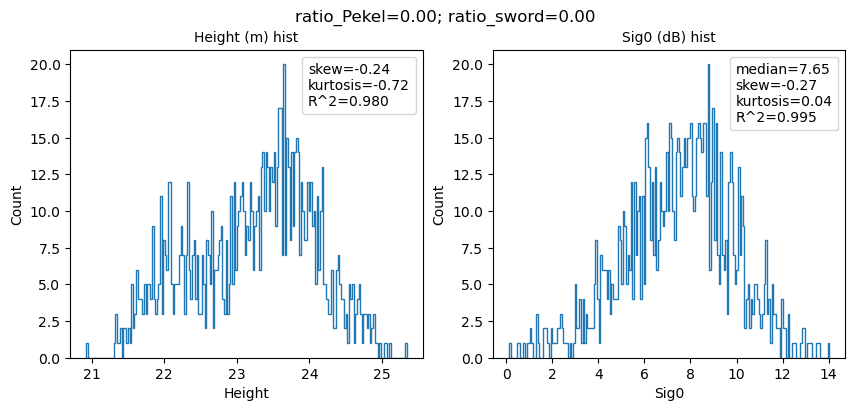

2026-02-16 16:10:15,884 [INFO] Ratio pekel, ratio sword: 0.000983767830791933, 0.0
2026-02-16 16:10:15,884 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.914608001708984, 0.40818652510643005, -0.24428686499595642, -0.6398820877075195, 0.002618074417114258, 0.9711118857753227, 0.9960759540219055


Body type: LAND

Processing Label 47 / 131


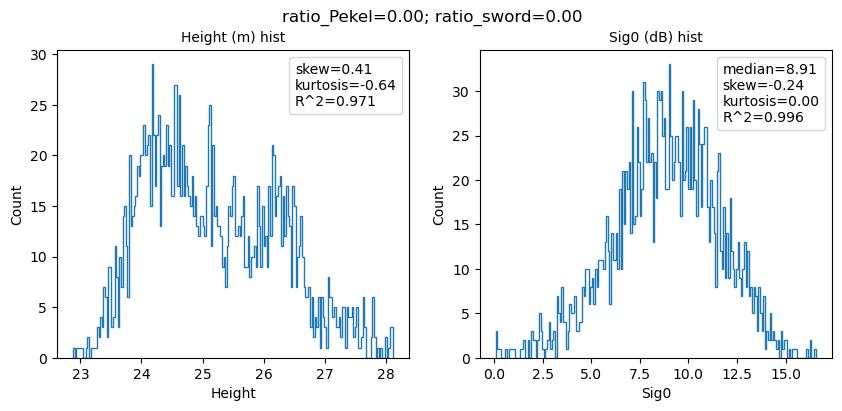

2026-02-16 16:10:16,146 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-16 16:10:16,147 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):7.751497745513916, 0.408726304769516, -0.16074758768081665, -0.2695658206939697, 0.012220144271850586, 0.9837264996796048, 0.9972494829158954


Body type: LAND

Processing Label 48 / 131


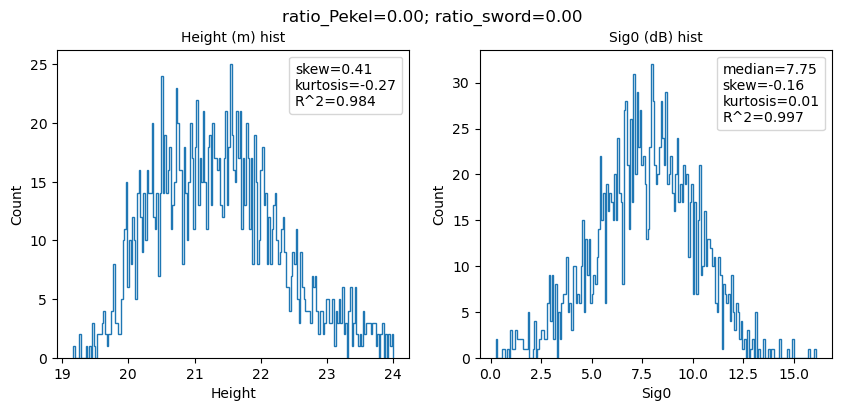

2026-02-16 16:10:16,419 [INFO] Ratio pekel, ratio sword: 0.0008169934640522876, 0.0
2026-02-16 16:10:16,419 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):10.87527084350586, -0.23031605780124664, -0.07740196585655212, -0.7798559665679932, 0.018271207809448242, 0.9802796162455665, 0.9978852638725964


Body type: LAND

Processing Label 49 / 131


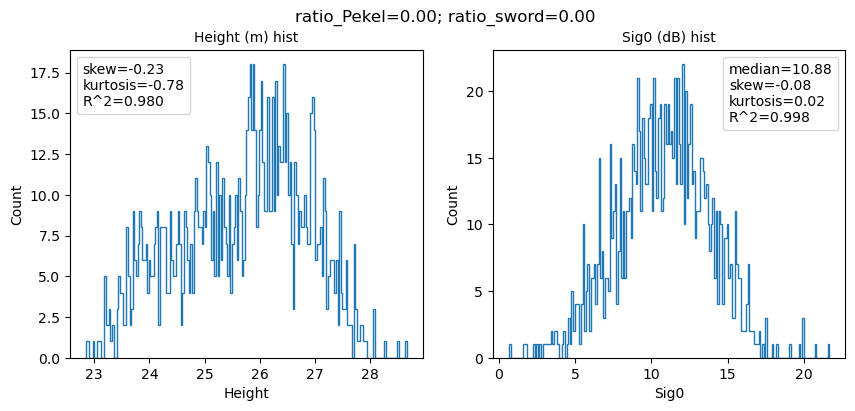

2026-02-16 16:10:16,679 [INFO] Ratio pekel, ratio sword: 0.0009165902841429881, 0.0
2026-02-16 16:10:16,679 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):9.474597930908203, -0.23006671667099, -0.2134878784418106, -0.6257312297821045, 0.0687708854675293, 0.9869961532516972, 0.994697681627143


Body type: LAND

Processing Label 50 / 131


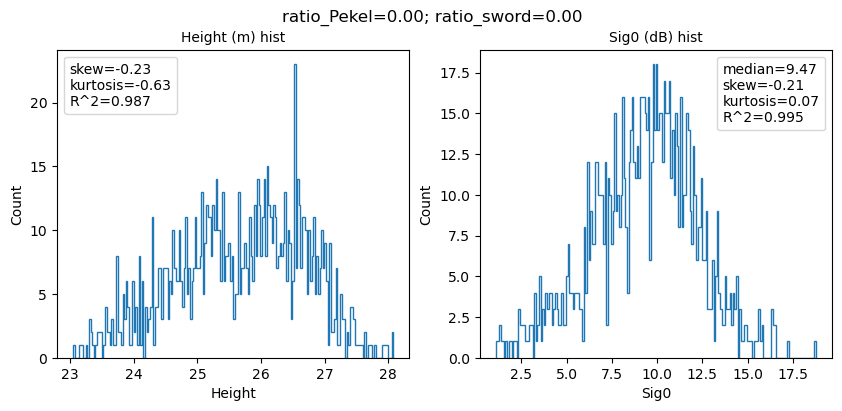

2026-02-16 16:10:16,957 [INFO] Ratio pekel, ratio sword: 0.0001098780353807274, 0.0
2026-02-16 16:10:16,958 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):7.599133491516113, 0.21538516879081726, -0.22876618802547455, -0.5502307415008545, -0.18615317344665527, 0.9889263252684225, 0.9953911309531667


Body type: LAND

Processing Label 51 / 131


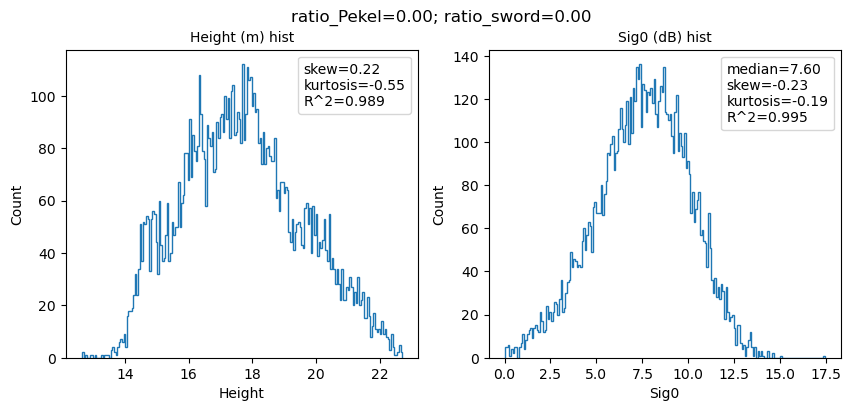

2026-02-16 16:10:17,228 [INFO] Ratio pekel, ratio sword: 0.00042444821731748726, 0.0
2026-02-16 16:10:17,228 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):7.884293556213379, -0.2923855185508728, -0.2699893116950989, -0.24001169204711914, -0.07836127281188965, 0.9909297794902473, 0.9943484854136911


Body type: LAND

Processing Label 52 / 131


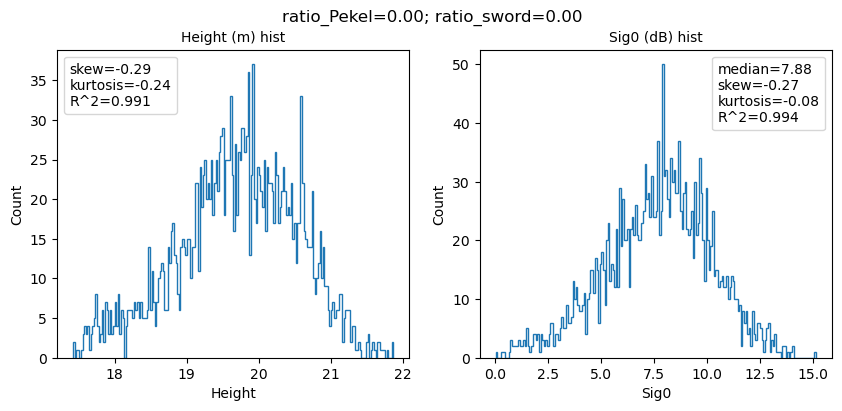

2026-02-16 16:10:17,490 [INFO] Ratio pekel, ratio sword: 0.8888221153846154, 0.5811298076923077
2026-02-16 16:10:17,490 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):9.699128150939941, 0.2063002735376358, 0.2799884080886841, -0.49047255516052246, 0.12549352645874023, 0.9909298784479562, 0.9942278756301297


Body type: LAND

Processing Label 53 / 131


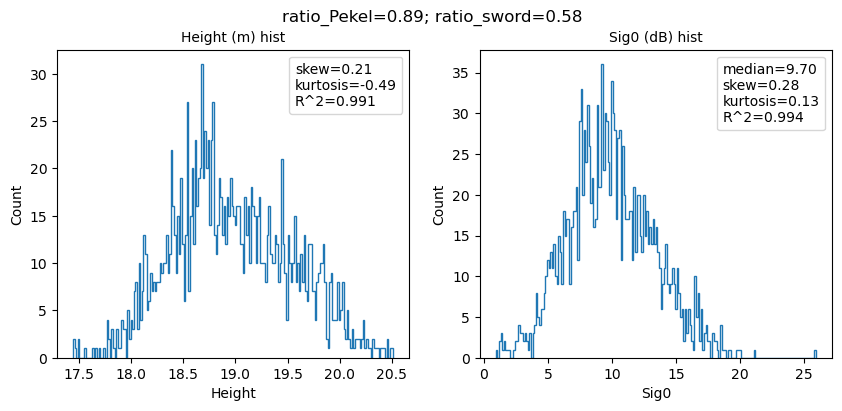

/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point 86.910538637539062 26.569771105392906
  return _ogr.Geometry_IsValid(self, *args)
2026-02-16 16:10:17,781 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-16 16:10:17,781 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.018891334533691, -0.026272321119904518, -0.14665888249874115, 0.1853640079498291, -0.10393881797790527, 0.9951267445679856, 0.9974705711174747


Body type: WATER
Bathtub ring method is applied

Processing Label 54 / 131


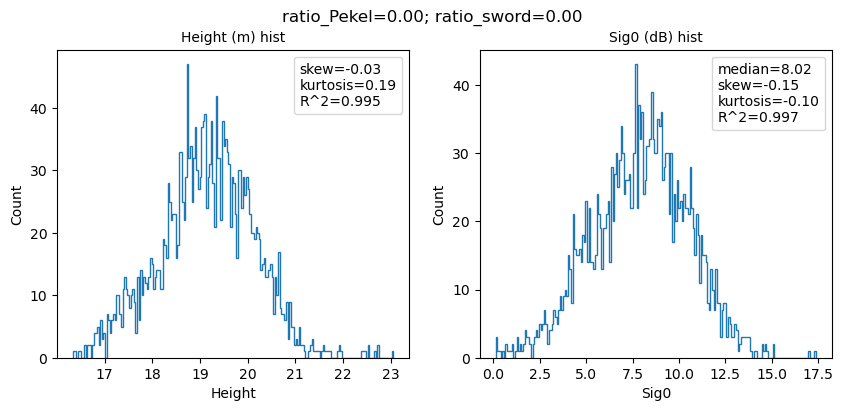

2026-02-16 16:10:18,064 [INFO] Ratio pekel, ratio sword: 0.002054132431126148, 0.0
2026-02-16 16:10:18,065 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.215292930603027, 0.5600287914276123, -0.2503807842731476, -0.5465636253356934, -0.058309316635131836, 0.9560712719290763, 0.9950878351289308


Body type: LAND

Processing Label 55 / 131


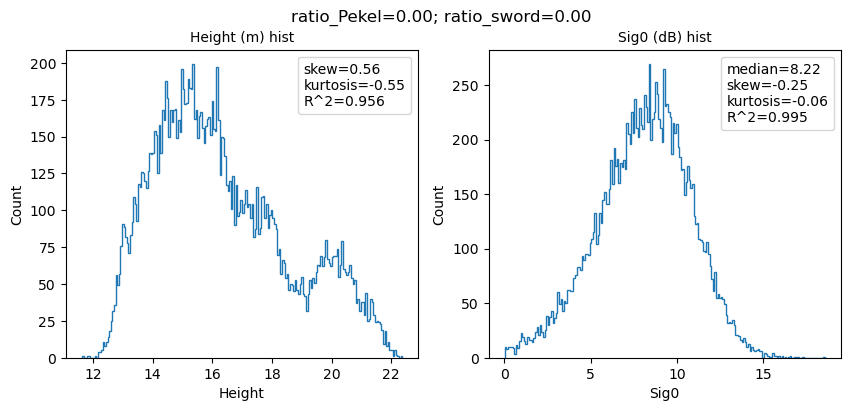

2026-02-16 16:10:18,332 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-16 16:10:18,332 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):9.085958480834961, 0.18718811869621277, -0.24169117212295532, -0.5872855186462402, 0.03414416313171387, 0.9881783164056381, 0.996272952326253


Body type: LAND

Processing Label 56 / 131


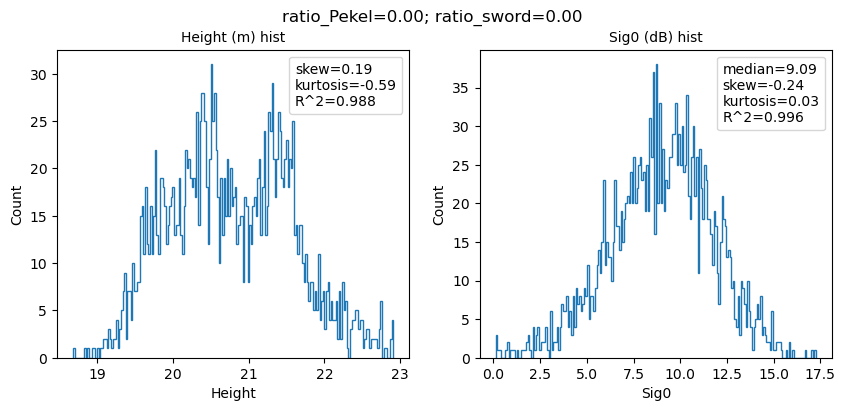

2026-02-16 16:10:18,612 [INFO] Ratio pekel, ratio sword: 0.002604565650375364, 0.0
2026-02-16 16:10:18,613 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):7.9338788986206055, 0.3115185797214508, -0.2117905169725418, -0.8383898735046387, 0.06987690925598145, 0.9711036429390877, 0.995556295806448


Body type: LAND

Processing Label 57 / 131


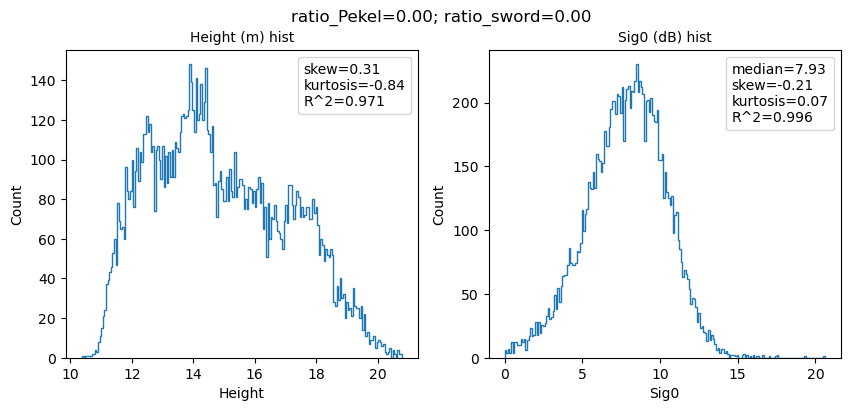

2026-02-16 16:10:18,880 [INFO] Ratio pekel, ratio sword: 0.0026666666666666666, 0.0
2026-02-16 16:10:18,880 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):13.35399055480957, 0.3437400758266449, -0.32884812355041504, -0.24744033813476562, -0.07512068748474121, 0.9846194791151884, 0.9925033645668029


Body type: LAND

Processing Label 58 / 131


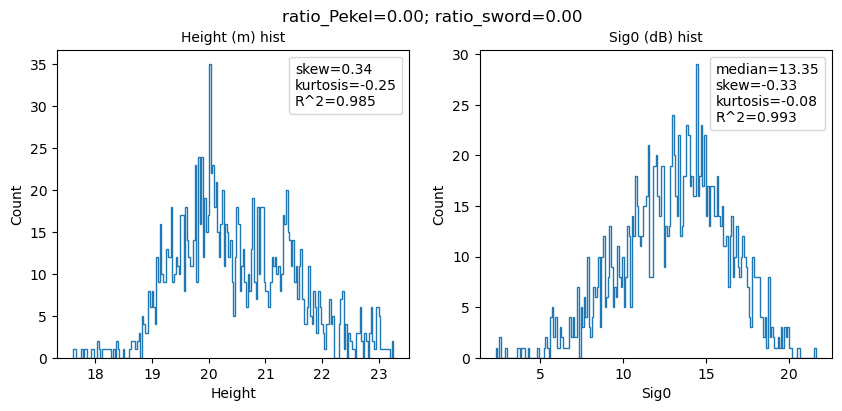

2026-02-16 16:10:19,141 [INFO] Ratio pekel, ratio sword: 0.0038204393505253103, 0.0
2026-02-16 16:10:19,141 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):16.199277877807617, -0.25215137004852295, -0.3444920480251312, -0.2837972640991211, -0.15413546562194824, 0.993067828843894, 0.9905581408807971


Body type: LAND

Processing Label 59 / 131


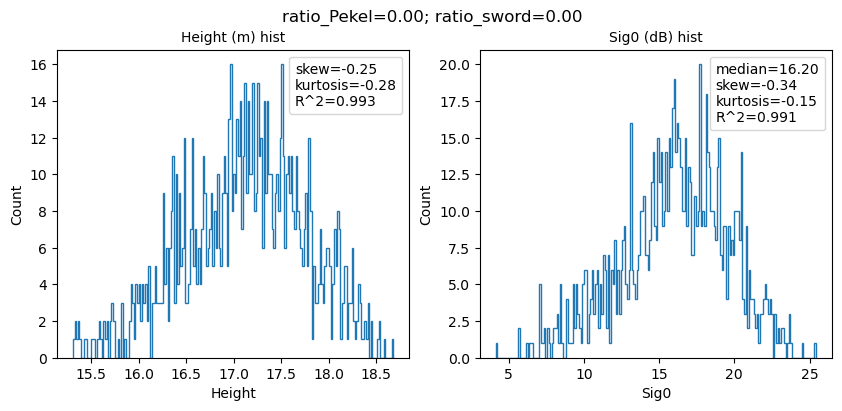

2026-02-16 16:10:19,421 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-16 16:10:19,422 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.914655685424805, 0.1478203535079956, -0.18415912985801697, -0.8953404426574707, 0.0013623237609863281, 0.9760990552630547, 0.9968099148084432


Body type: LAND

Processing Label 60 / 131


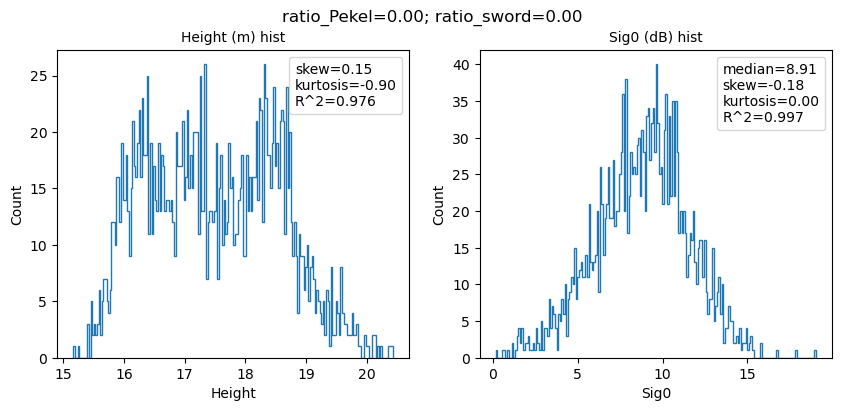

2026-02-16 16:10:19,692 [INFO] Ratio pekel, ratio sword: 0.0068371393408997675, 0.0
2026-02-16 16:10:19,693 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):9.691235542297363, 0.2291492372751236, 0.30068308115005493, -1.1053102016448975, 0.7799150943756104, 0.9557249084837199, 0.991488129090749


Body type: LAND

Processing Label 61 / 131


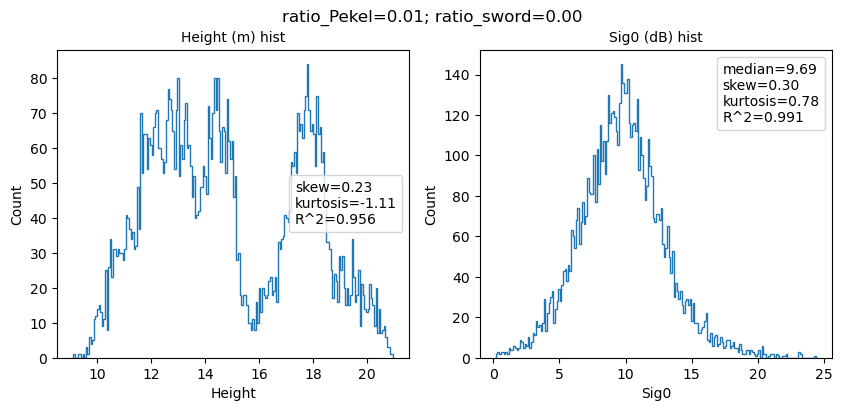

2026-02-16 16:10:19,971 [INFO] Ratio pekel, ratio sword: 0.00015725743041358704, 0.0
2026-02-16 16:10:19,972 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):12.121234893798828, 0.32051169872283936, -0.059423185884952545, -0.3443644046783447, -0.1562342643737793, 0.9854875709800901, 0.9993335558519969


Body type: LAND

Processing Label 62 / 131


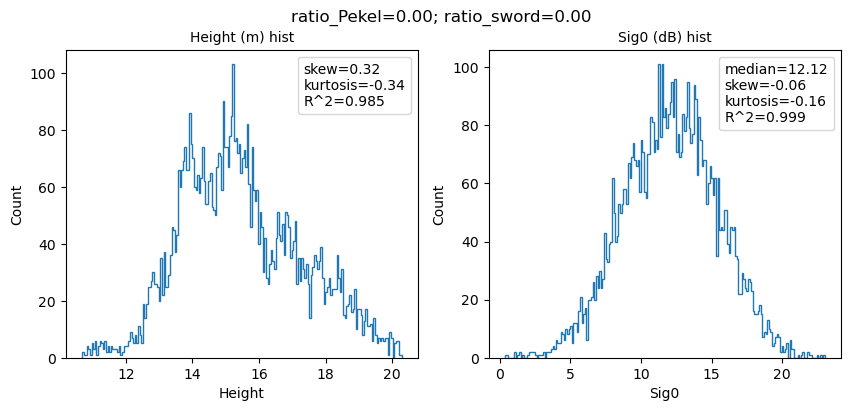

2026-02-16 16:10:20,233 [INFO] Ratio pekel, ratio sword: 0.004103967168262654, 0.0
2026-02-16 16:10:20,234 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):14.969340324401855, 0.17678968608379364, -0.14344628155231476, -1.0539920330047607, -0.24587440490722656, 0.9653408664964463, 0.9973542984379482


Body type: LAND

Processing Label 63 / 131


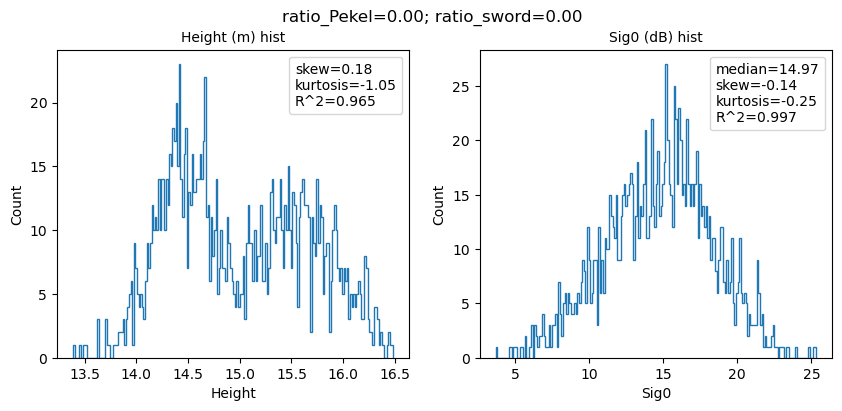

2026-02-16 16:10:20,498 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-16 16:10:20,498 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):15.585424423217773, -0.08008376508951187, -0.23710806667804718, -0.5164880752563477, -0.23111581802368164, 0.9945230289132677, 0.9944858313387971


Body type: LAND

Processing Label 64 / 131


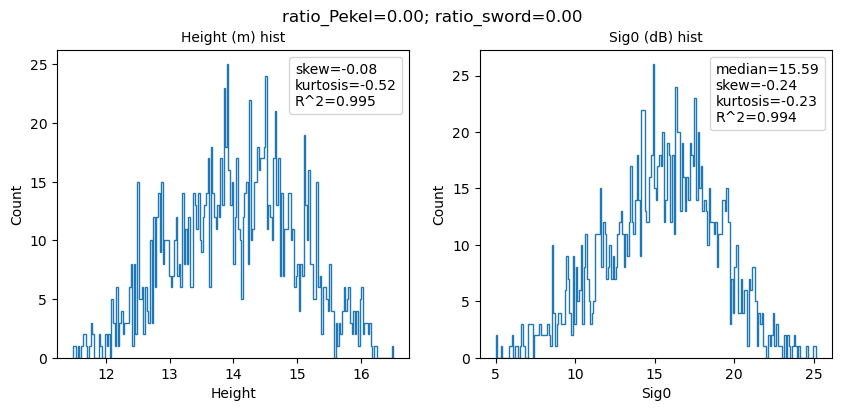

2026-02-16 16:10:20,752 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-16 16:10:20,752 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):7.685791015625, 0.29472649097442627, -0.30482375621795654, -0.6475865840911865, 0.02425241470336914, 0.9822830689093532, 0.9932527624319567


Body type: LAND

Processing Label 65 / 131


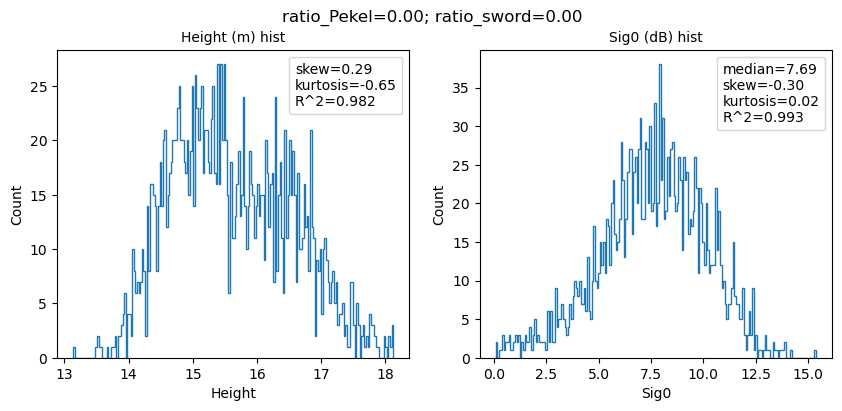

2026-02-16 16:10:21,022 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-16 16:10:21,022 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):15.46543025970459, -0.0935431495308876, -0.3144513666629791, -0.7484719753265381, -0.3258504867553711, 0.9861497838183014, 0.9898908560324295


Body type: LAND

Processing Label 66 / 131


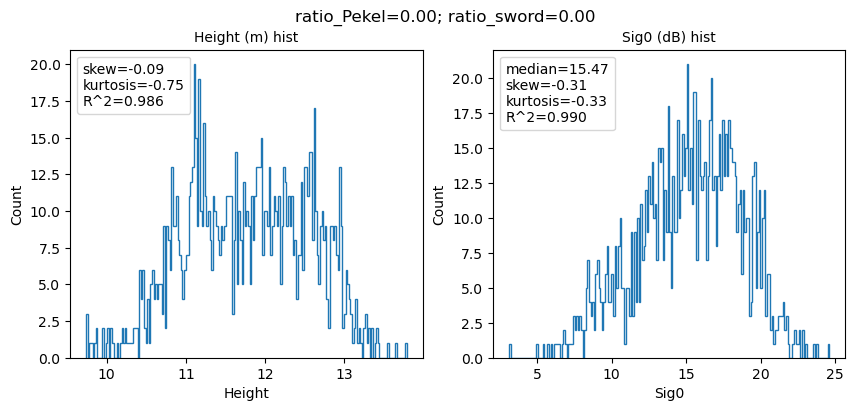

2026-02-16 16:10:21,298 [INFO] Ratio pekel, ratio sword: 0.12136395267919277, 0.2523312456506611
2026-02-16 16:10:21,299 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):11.518705368041992, -2.0048742294311523, -0.3574947416782379, 2.672060012817383, 0.11285710334777832, 0.6486642794850168, 0.9903494722576873


Body type: LAND

Processing Label 67 / 131


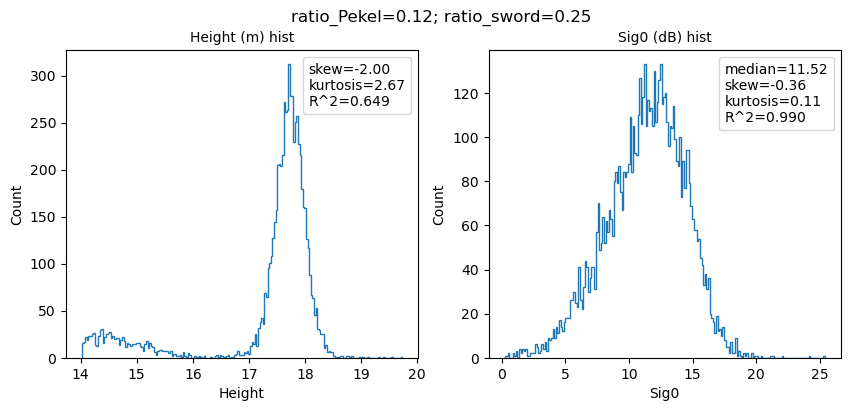

2026-02-16 16:10:21,567 [INFO] Ratio pekel, ratio sword: 0.0017316017316017316, 0.0
2026-02-16 16:10:21,568 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):11.582680702209473, 0.3494662642478943, -0.15350447595119476, -0.9315919876098633, -0.27390193939208984, 0.9595628690936947, 0.9963312744744275


Body type: LAND

Processing Label 68 / 131


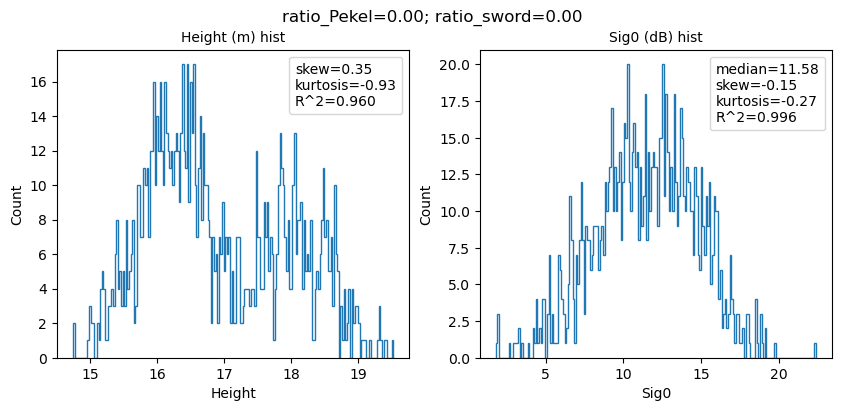

2026-02-16 16:10:21,872 [INFO] Ratio pekel, ratio sword: 0.011270947649414208, 0.0
2026-02-16 16:10:21,872 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):11.191964149475098, 0.39663591980934143, 0.12688323855400085, -0.2723207473754883, 0.3040313720703125, 0.9811295666754081, 0.9982119681714322


Body type: LAND

Processing Label 69 / 131


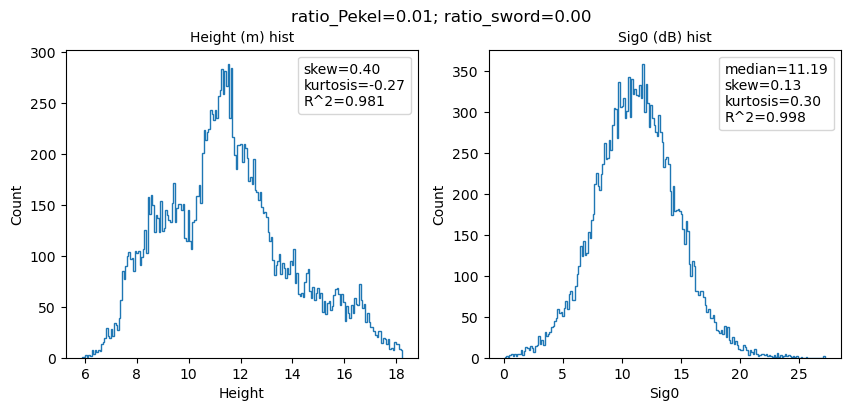

2026-02-16 16:10:22,146 [INFO] Ratio pekel, ratio sword: 0.004382761139517896, 0.0
2026-02-16 16:10:22,147 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):15.89116096496582, -0.31184548139572144, -0.18669810891151428, -0.4990830421447754, -0.14716458320617676, 0.9796258243641582, 0.9964976686029429


Body type: LAND

Processing Label 70 / 131


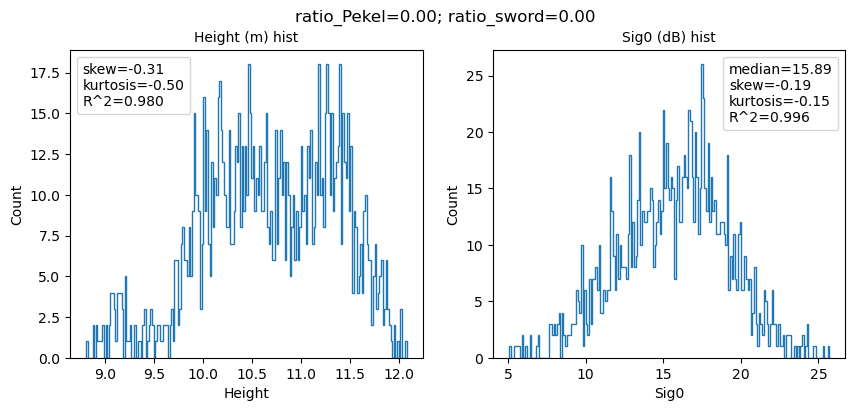

2026-02-16 16:10:22,415 [INFO] Ratio pekel, ratio sword: 0.004580852038479157, 0.0
2026-02-16 16:10:22,416 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):16.34566879272461, -0.36197569966316223, -0.2778853476047516, -0.22540926933288574, -0.31828832626342773, 0.983678968512696, 0.9921800386866639


Body type: LAND

Processing Label 71 / 131


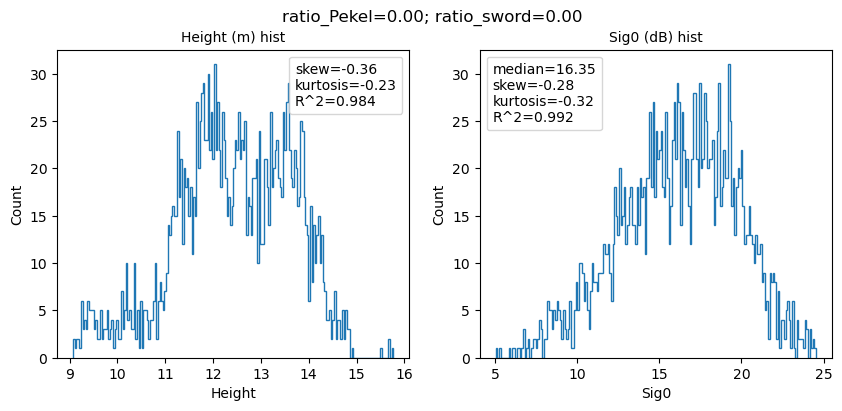

2026-02-16 16:10:22,683 [INFO] Ratio pekel, ratio sword: 0.0025210084033613447, 0.0
2026-02-16 16:10:22,684 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):16.220184326171875, -0.18135182559490204, -0.15142488479614258, -0.6264791488647461, -0.36575889587402344, 0.989489677441032, 0.9954370090688764


Body type: LAND

Processing Label 72 / 131


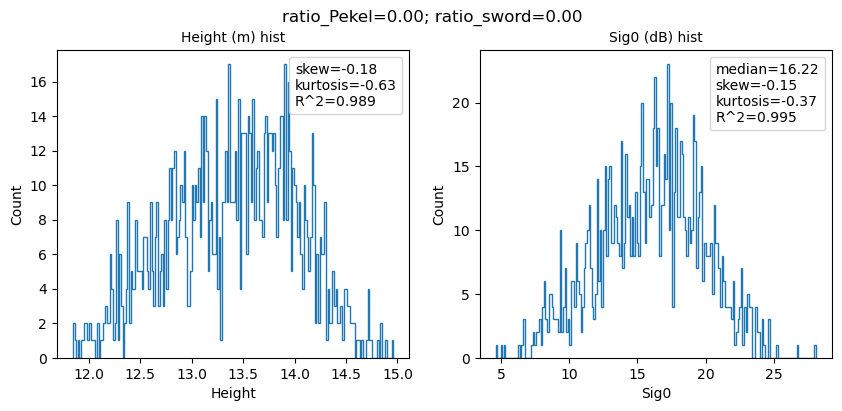

2026-02-16 16:10:22,944 [INFO] Ratio pekel, ratio sword: 0.0006119951040391676, 0.0
2026-02-16 16:10:22,945 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):14.396160125732422, 0.08108276128768921, -0.09275148808956146, -0.5375118255615234, -0.468569278717041, 0.9929969724421929, 0.9954608369011444


Body type: LAND

Processing Label 73 / 131


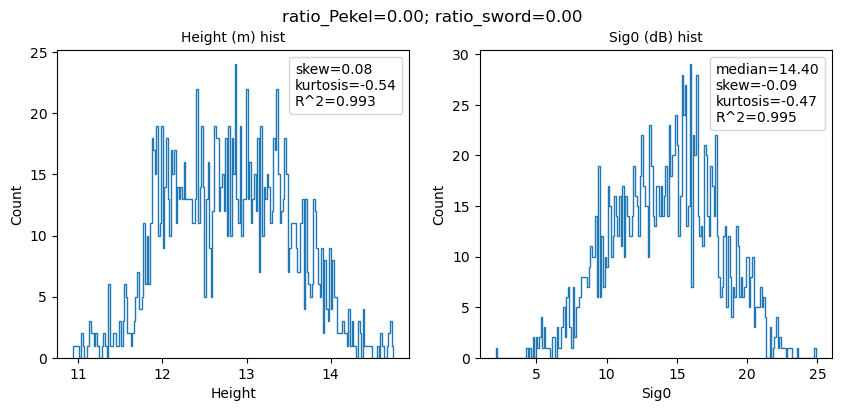

2026-02-16 16:10:23,210 [INFO] Ratio pekel, ratio sword: 0.0026402640264026403, 0.0
2026-02-16 16:10:23,210 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):7.757268905639648, 0.07426180690526962, -0.264671266078949, -0.6733050346374512, -0.0274810791015625, 0.9916225411268241, 0.9948701175929111


Body type: LAND

Processing Label 74 / 131


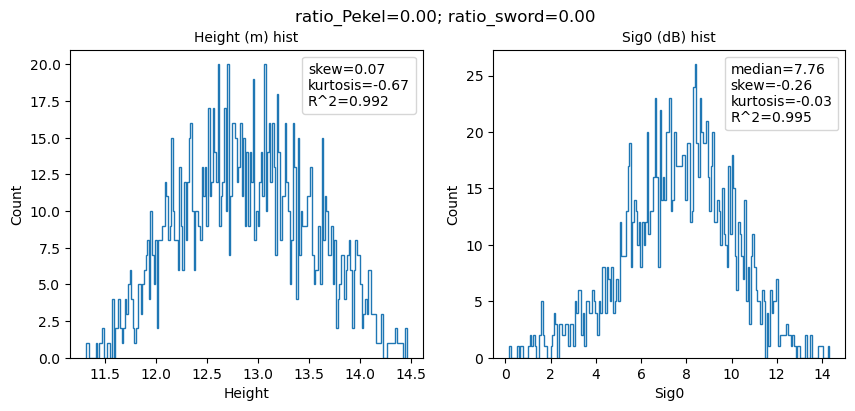

2026-02-16 16:10:23,504 [INFO] Ratio pekel, ratio sword: 0.029149883400466398, 0.0
2026-02-16 16:10:23,505 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):15.153721809387207, 0.5330119729042053, -0.1918117105960846, -0.2496967315673828, -0.19522929191589355, 0.968411192749184, 0.9965135822479364


Body type: LAND

Processing Label 75 / 131


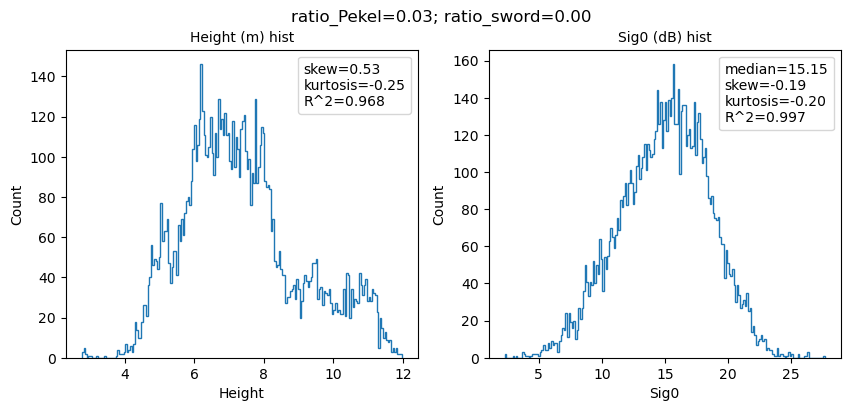

2026-02-16 16:10:23,781 [INFO] Ratio pekel, ratio sword: 0.0006605019815059445, 0.0
2026-02-16 16:10:23,782 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):16.230194091796875, 0.3245932459831238, -0.20120130479335785, -0.5435581207275391, -0.4070885181427002, 0.9841946450565136, 0.9939352768855603


Body type: LAND

Processing Label 76 / 131


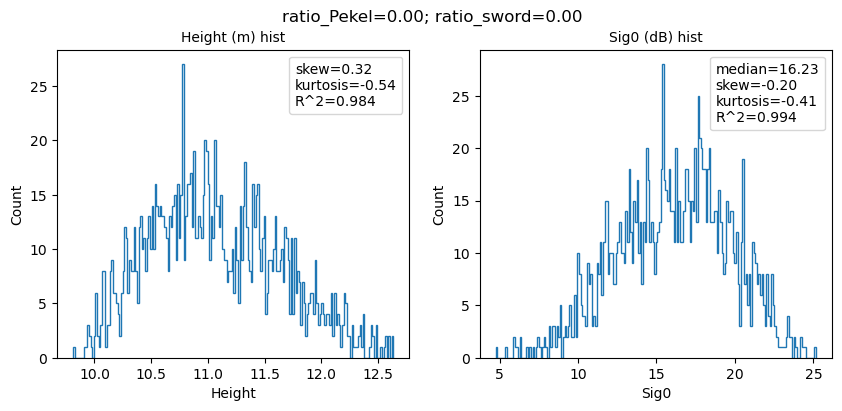

2026-02-16 16:10:24,086 [INFO] Ratio pekel, ratio sword: 0.0017388491245096849, 0.0
2026-02-16 16:10:24,086 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.292242050170898, 0.09451045840978622, -0.16504284739494324, -0.7455048561096191, 0.09428000450134277, 0.9876349349181889, 0.9967135387945162


Body type: LAND

Processing Label 77 / 131


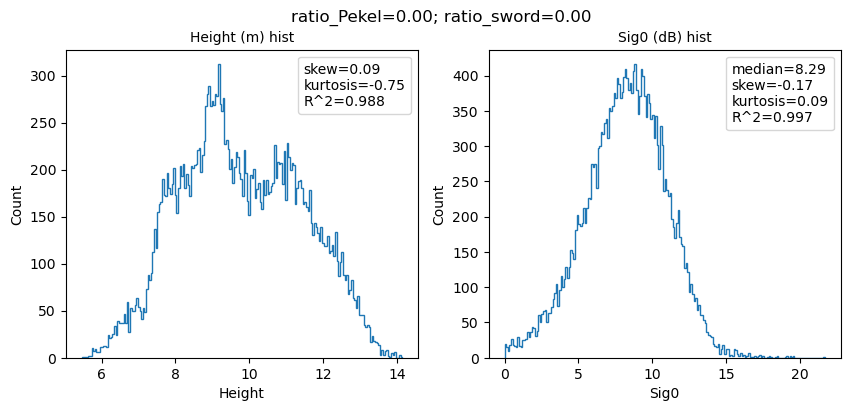

2026-02-16 16:10:24,362 [INFO] Ratio pekel, ratio sword: 0.0008373456144023446, 0.0
2026-02-16 16:10:24,362 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.030145645141602, 0.12248274683952332, -0.2604811489582062, -0.9652032852172852, -0.041533470153808594, 0.9766387295169764, 0.9953498201571797


Body type: LAND

Processing Label 78 / 131


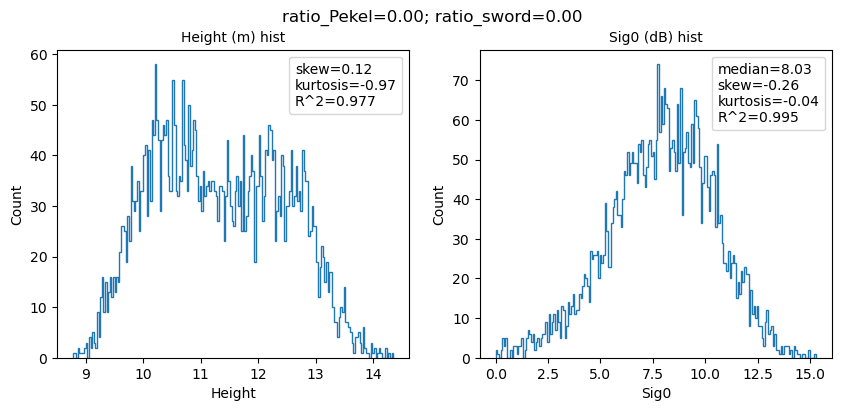

2026-02-16 16:10:24,631 [INFO] Ratio pekel, ratio sword: 0.0263013698630137, 0.0
2026-02-16 16:10:24,632 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):13.652557373046875, 0.056447312235832214, -0.2858674228191376, 0.06648039817810059, -0.21719861030578613, 0.9946698042217411, 0.9927240526841257


Body type: LAND

Processing Label 79 / 131


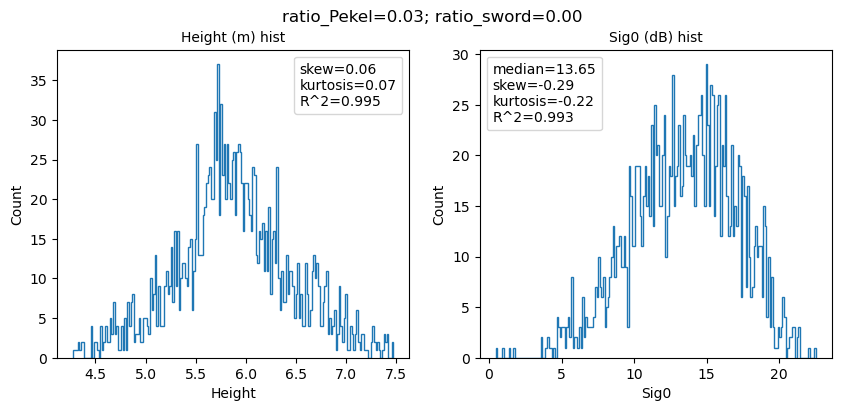

2026-02-16 16:10:24,896 [INFO] Ratio pekel, ratio sword: 0.0166358595194085, 0.0
2026-02-16 16:10:24,897 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):14.416604995727539, -0.008108368143439293, 0.04022527113556862, -0.9527013301849365, -0.533402681350708, 0.9765650359519571, 0.9953284178847324


Body type: LAND

Processing Label 80 / 131


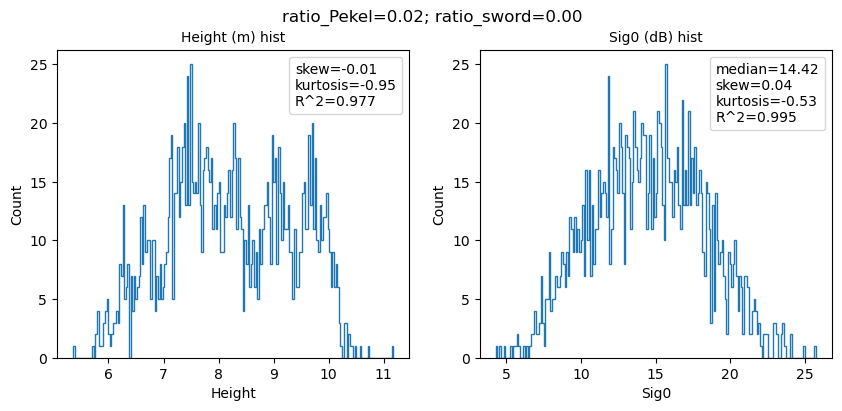

2026-02-16 16:10:25,150 [INFO] Ratio pekel, ratio sword: 0.0036253776435045317, 0.0
2026-02-16 16:10:25,150 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):12.603507041931152, -0.27292439341545105, 0.02831920050084591, -0.5615341663360596, -0.25298118591308594, 0.9859679509702381, 0.9988770450428405


Body type: LAND

Processing Label 81 / 131


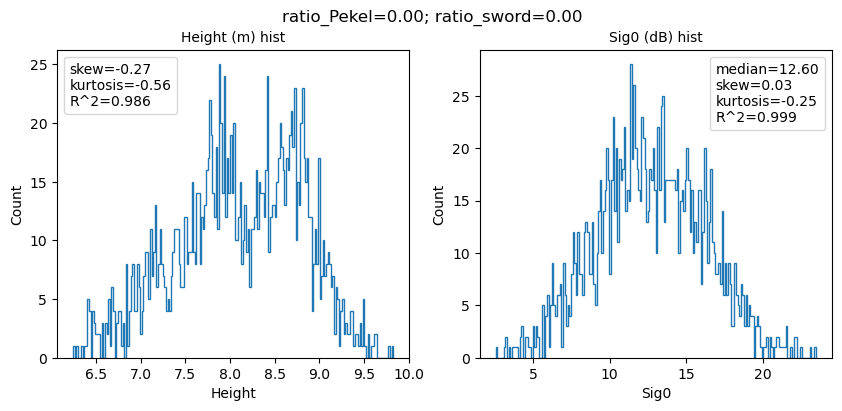

2026-02-16 16:10:25,409 [INFO] Ratio pekel, ratio sword: 0.09816612729234088, 0.0
2026-02-16 16:10:25,409 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.382377624511719, 0.9134768843650818, -0.1894880086183548, 1.158668041229248, 0.2064533233642578, 0.9481579543568519, 0.9958855862257799


Body type: LAND

Processing Label 82 / 131


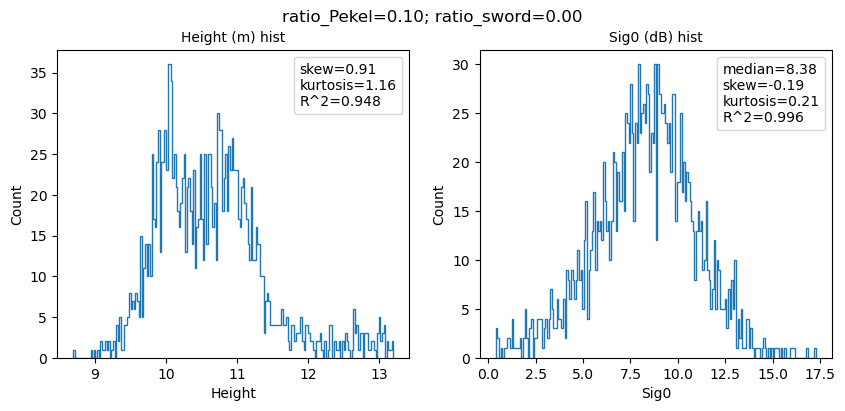

2026-02-16 16:10:25,683 [INFO] Ratio pekel, ratio sword: 0.5906829488919041, 0.3071008593396653
2026-02-16 16:10:25,683 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.950983047485352, -0.03840000182390213, -0.3048385679721832, -0.06643223762512207, -0.08361291885375977, 0.9984364204590835, 0.9935810362649438


Body type: LAND

Processing Label 83 / 131


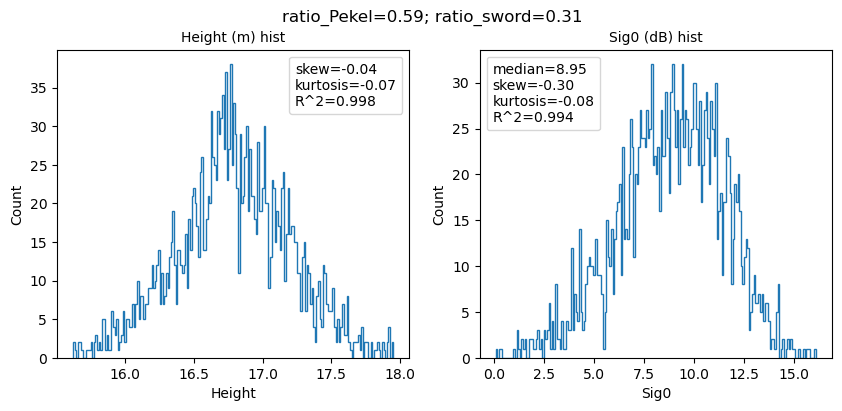

/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point 86.950930894551973 26.526576935322762
  return _ogr.Geometry_IsValid(self, *args)
2026-02-16 16:10:25,963 [INFO] Ratio pekel, ratio sword: 0.27249575551782684, 1.0
2026-02-16 16:10:25,964 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.211454391479492, -0.14636088907718658, -0.2814192771911621, -0.13762521743774414, -0.08317971229553223, 0.9970366553982135, 0.9940849246091507


Body type: WATER
Bathtub ring method is applied

Processing Label 84 / 131


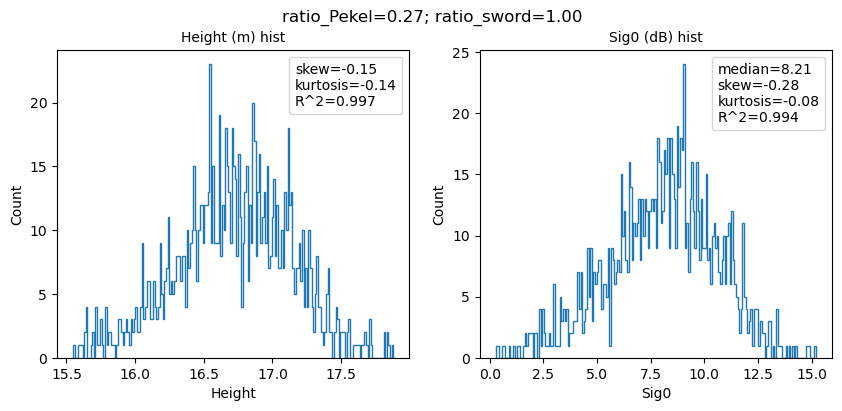

/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point 86.94129799062992 26.524449189074435
  return _ogr.Geometry_IsValid(self, *args)
2026-02-16 16:10:26,224 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-16 16:10:26,224 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):9.403502464294434, -0.10695981234312057, -0.2932458221912384, -0.45302891731262207, -0.039896249771118164, 0.9952882510290982, 0.9942775065681945


Body type: WATER
Bathtub ring method is applied

Processing Label 85 / 131


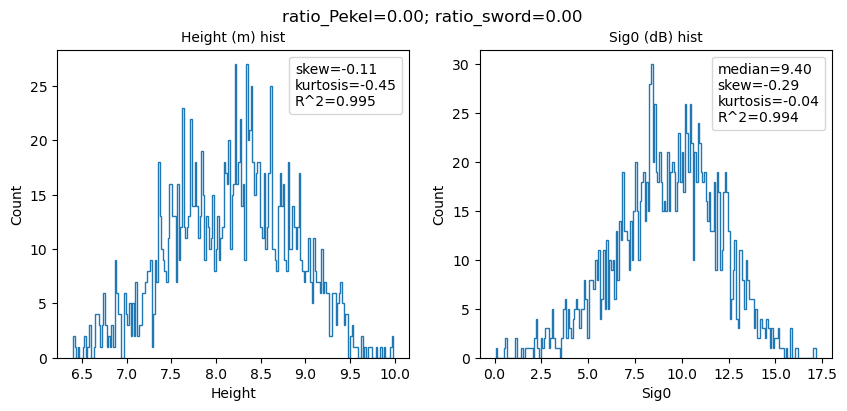

2026-02-16 16:10:26,516 [INFO] Ratio pekel, ratio sword: 0.028619864379736737, 0.0
2026-02-16 16:10:26,517 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):11.24433422088623, 0.4816010594367981, -0.16648666560649872, -0.650160551071167, -0.016236543655395508, 0.9628858343441823, 0.9982299681714796


Body type: LAND

Processing Label 86 / 131


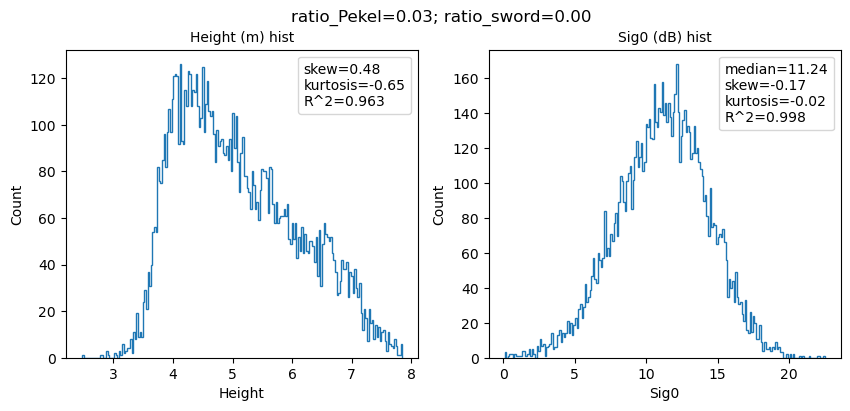

2026-02-16 16:10:26,787 [INFO] Ratio pekel, ratio sword: 0.001774622892635315, 0.0
2026-02-16 16:10:26,787 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):9.589859008789062, 0.6645413041114807, -0.10830606520175934, 0.48936963081359863, 0.06183576583862305, 0.9665180548729907, 0.9986281342949315


Body type: LAND

Processing Label 87 / 131


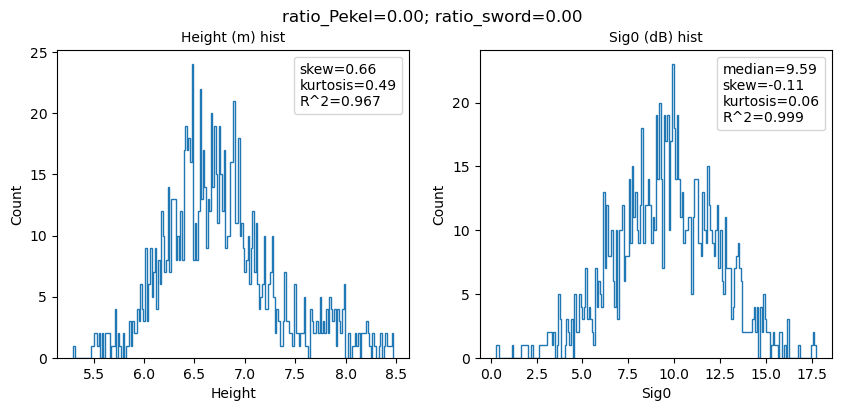

2026-02-16 16:10:27,049 [INFO] Ratio pekel, ratio sword: 0.0028763183125599234, 0.0
2026-02-16 16:10:27,049 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):13.828725814819336, -0.5130956768989563, -0.018142791464924812, -0.8065016269683838, -0.3249368667602539, 0.9436288445245483, 0.9982298044999611


Body type: LAND

Processing Label 88 / 131


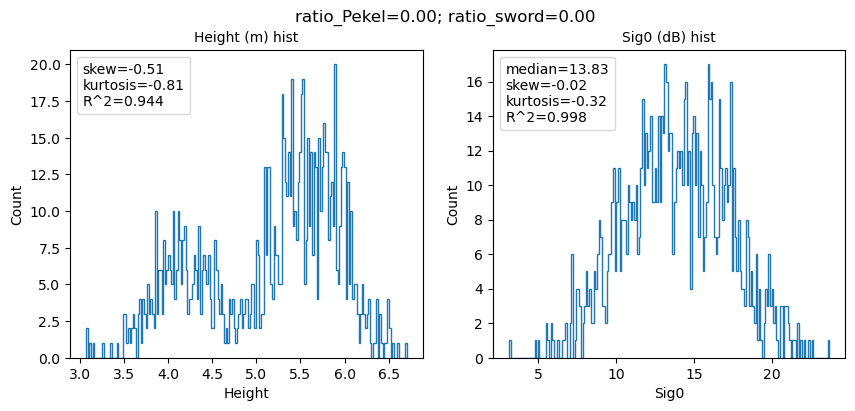

2026-02-16 16:10:27,334 [INFO] Ratio pekel, ratio sword: 0.03096888364548002, 0.0
2026-02-16 16:10:27,334 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):15.388648986816406, 0.25145405530929565, -0.19766658544540405, -0.530825138092041, -0.2733902931213379, 0.9890707658905147, 0.9959180696533031


Body type: LAND

Processing Label 89 / 131


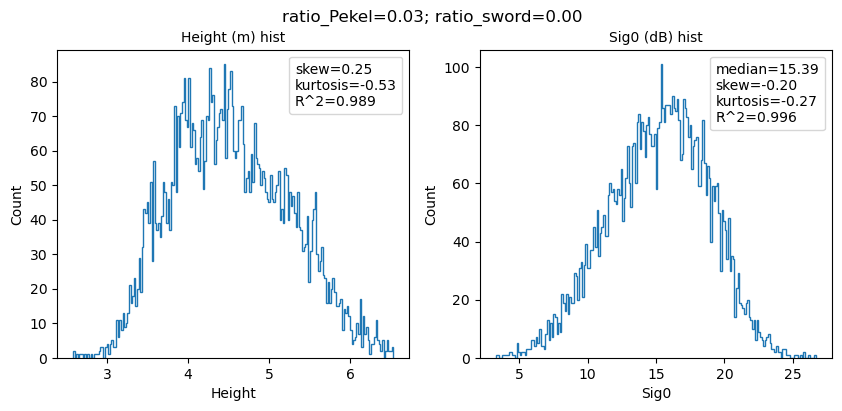

2026-02-16 16:10:27,617 [INFO] Ratio pekel, ratio sword: 0.8880170017982671, 0.9861042994932157
2026-02-16 16:10:27,617 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):11.436624526977539, -0.280758798122406, 0.04131544381380081, -0.16784930229187012, -0.31553077697753906, 0.9906861984226113, 0.9984983505928677


Body type: LAND

Processing Label 90 / 131


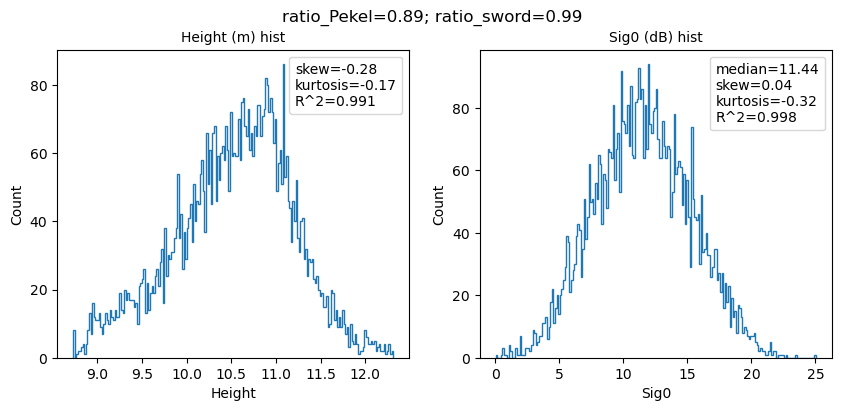

2026-02-16 16:10:27,950 [INFO] Ratio pekel, ratio sword: 0.17079889807162535, 0.0
2026-02-16 16:10:27,950 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.527118682861328, 0.671450138092041, -0.2789101004600525, 0.1907820701599121, -0.007165431976318359, 0.967100614136907, 0.9939778818382076


Body type: WATER
Bathtub ring method is applied

Processing Label 91 / 131


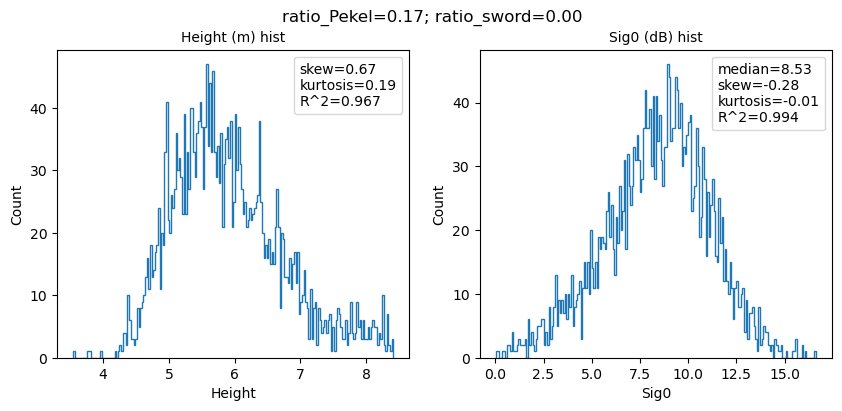

2026-02-16 16:10:28,230 [INFO] Ratio pekel, ratio sword: 0.008632908130395568, 0.0
2026-02-16 16:10:28,231 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):9.604567527770996, 0.27776631712913513, -0.030539948493242264, -0.8651745319366455, 0.1342020034790039, 0.966776176002751, 0.9989522122401099


Body type: LAND

Processing Label 92 / 131


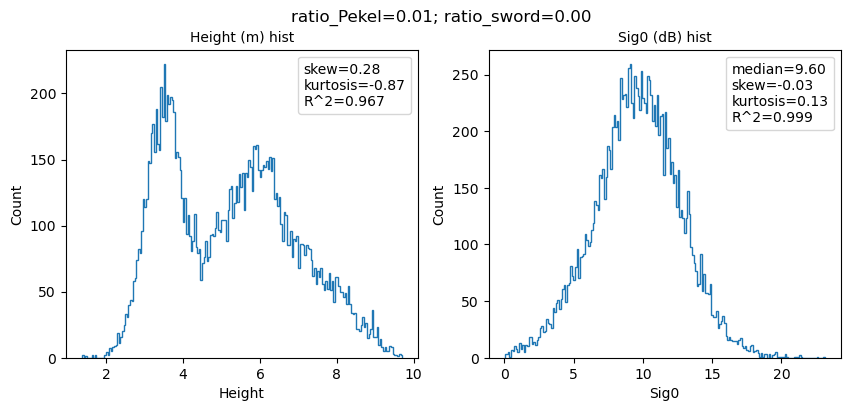

2026-02-16 16:10:28,495 [INFO] Ratio pekel, ratio sword: 0.029318036966220522, 0.0
2026-02-16 16:10:28,495 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):16.29437255859375, 0.23813466727733612, -0.20384684205055237, -0.09177112579345703, -0.13858819007873535, 0.9944394473956003, 0.996790591429638


Body type: LAND

Processing Label 93 / 131


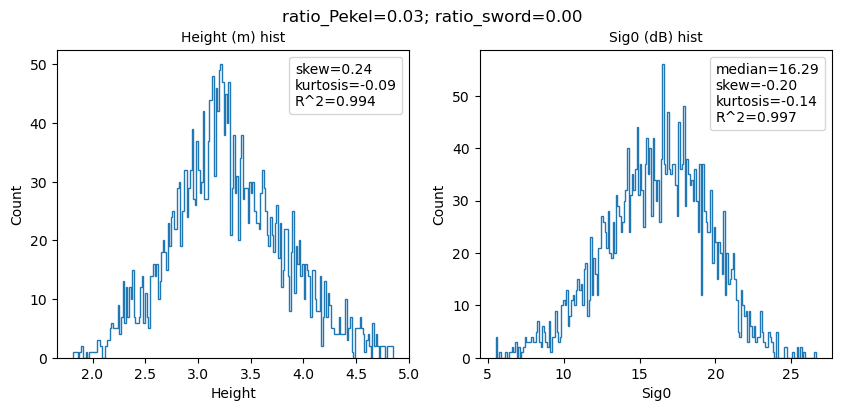

2026-02-16 16:10:28,766 [INFO] Ratio pekel, ratio sword: 0.9858977057461586, 0.9404335929278047
2026-02-16 16:10:28,766 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):11.143804550170898, 0.23453888297080994, 0.12029203772544861, -0.3286595344543457, -0.3002307415008545, 0.9928606688229333, 0.9976539850732091


Body type: LAND

Processing Label 94 / 131


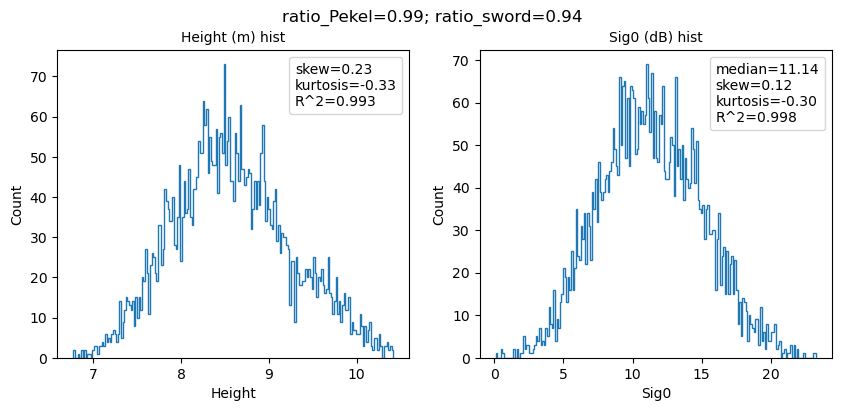

/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point 86.842196023436131 26.478870093950412
  return _ogr.Geometry_IsValid(self, *args)
2026-02-16 16:10:29,095 [INFO] Ratio pekel, ratio sword: 0.13683483068417415, 0.0
2026-02-16 16:10:29,096 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):9.206957817077637, -0.2733992338180542, -0.2948826253414154, 0.4891667366027832, 0.19731545448303223, 0.9867392339174375, 0.9940417521660887


Body type: WATER
Bathtub ring method is applied

Processing Label 95 / 131


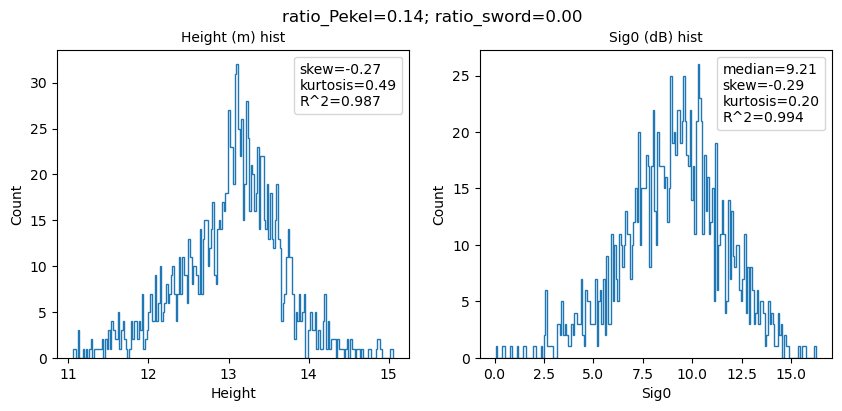

2026-02-16 16:10:29,361 [INFO] Ratio pekel, ratio sword: 0.7669305189094108, 0.0
2026-02-16 16:10:29,362 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):7.94618034362793, -0.1147533655166626, -0.21276697516441345, -0.4087967872619629, -0.11824727058410645, 0.9965535005164939, 0.9958322684793062


Body type: LAND

Processing Label 96 / 131


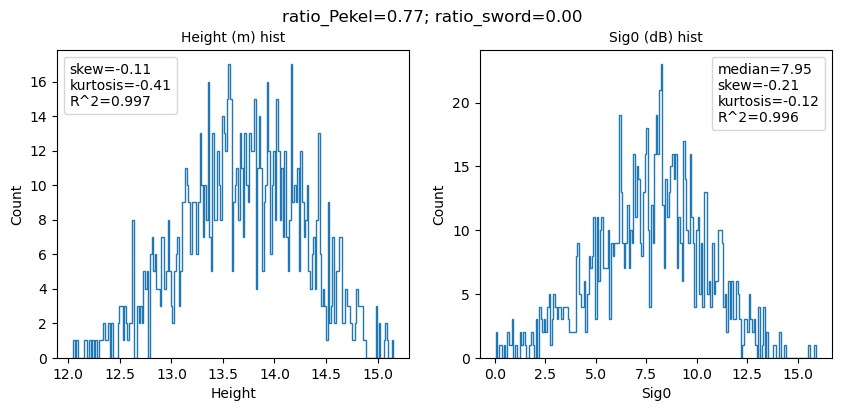

/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point 87.029246449899887 26.506212164548558
  return _ogr.Geometry_IsValid(self, *args)
2026-02-16 16:10:29,647 [INFO] Ratio pekel, ratio sword: 0.004081632653061225, 0.0
2026-02-16 16:10:29,648 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):14.870054244995117, -0.17858387529850006, -0.10786338150501251, -0.1297154426574707, -0.14226818084716797, 0.9955590615193765, 0.9983482744886665


Body type: WATER
Bathtub ring method is applied

Processing Label 97 / 131


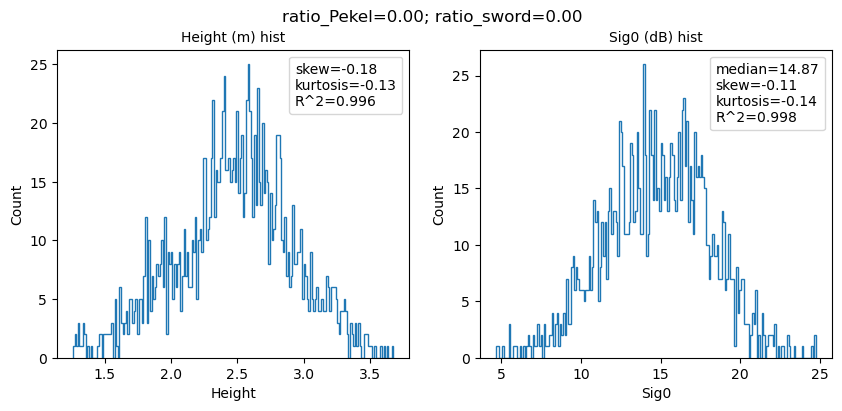

2026-02-16 16:10:29,909 [INFO] Ratio pekel, ratio sword: 1.0, 1.0
2026-02-16 16:10:29,909 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):11.276456832885742, 0.22204133868217468, 0.2684299349784851, -0.38387346267700195, -0.4481675624847412, 0.9934955427676754, 0.9884638098545582


Body type: LAND

Processing Label 98 / 131


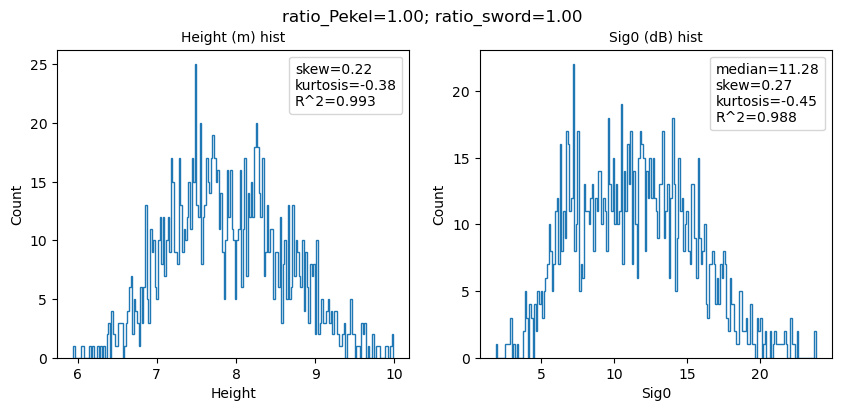

/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point 86.863189949063354 26.473887588954312
  return _ogr.Geometry_IsValid(self, *args)
2026-02-16 16:10:30,177 [INFO] Ratio pekel, ratio sword: 0.9994158878504673, 0.9307827102803738
2026-02-16 16:10:30,177 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):11.888935089111328, -0.20983758568763733, 0.27414119243621826, -0.6816327571868896, -0.16516661643981934, 0.9858764941475096, 0.9938471914986289


Body type: WATER
Bathtub ring method is applied

Processing Label 99 / 131


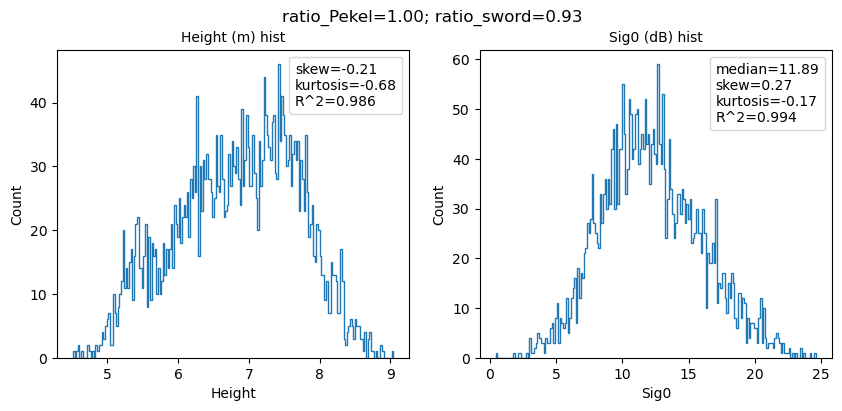

2026-02-16 16:10:30,489 [INFO] Ratio pekel, ratio sword: 0.005852516582130316, 0.0
2026-02-16 16:10:30,489 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):11.634359359741211, 0.29189711809158325, -0.041032321751117706, -0.09444284439086914, 0.15177130699157715, 0.9929115521718098, 0.9990905062052464


Body type: WATER
Bathtub ring method is applied

Processing Label 100 / 131


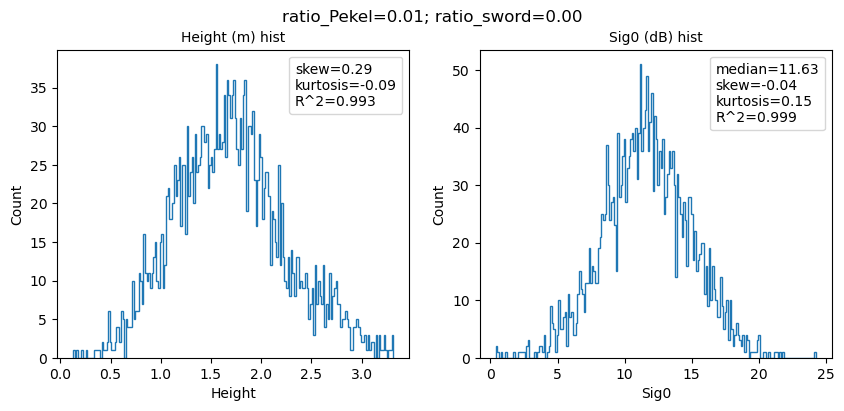

2026-02-16 16:10:30,766 [INFO] Ratio pekel, ratio sword: 0.004455760661998727, 0.0
2026-02-16 16:10:30,766 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):13.765081405639648, -0.07714451849460602, -0.09550687670707703, -0.6951265335083008, -0.1883249282836914, 0.9901936856673093, 0.9985204972296761


Body type: LAND

Processing Label 101 / 131


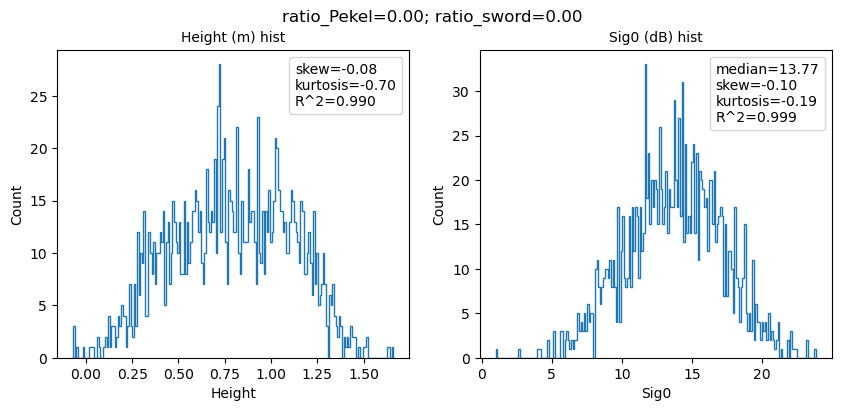

2026-02-16 16:10:31,026 [INFO] Ratio pekel, ratio sword: 0.05309218203033839, 0.0
2026-02-16 16:10:31,026 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):14.379816055297852, 0.6343852877616882, -0.051172733306884766, -0.29523181915283203, -0.11713838577270508, 0.9553378063234006, 0.9990506347405181


Body type: LAND

Processing Label 102 / 131


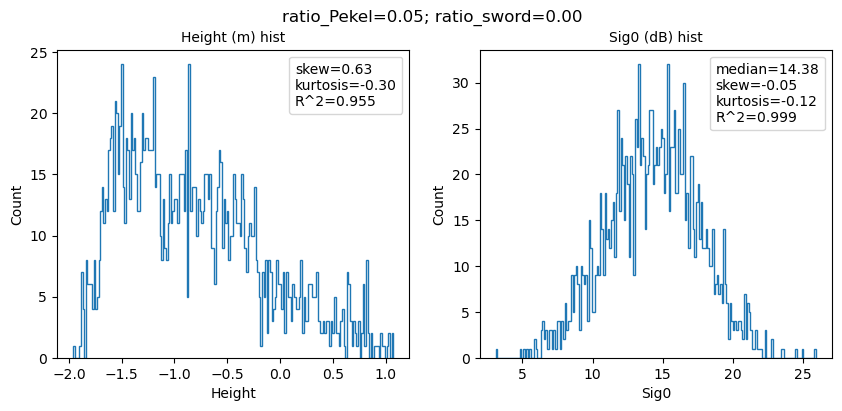

2026-02-16 16:10:31,296 [INFO] Ratio pekel, ratio sword: 0.8606286186931348, 0.19189412737799835
2026-02-16 16:10:31,297 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):10.220809936523438, -0.12589481472969055, 0.2862206697463989, -0.4076089859008789, 0.10088825225830078, 0.9951949843590644, 0.9950957023619941


Body type: LAND

Processing Label 103 / 131


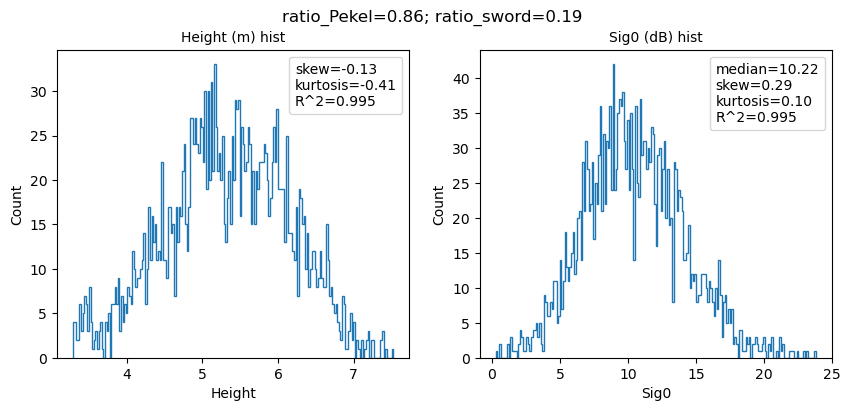

/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point 86.797415062132657 26.443516664928239
  return _ogr.Geometry_IsValid(self, *args)
2026-02-16 16:10:31,583 [INFO] Ratio pekel, ratio sword: 0.17206835592221567, 0.0
2026-02-16 16:10:31,584 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):7.464173316955566, 0.057647012174129486, -0.1862996220588684, 0.3399078845977783, -0.1277482509613037, 0.9968219189823497, 0.9963319893902535


Body type: WATER
Bathtub ring method is applied

Processing Label 104 / 131


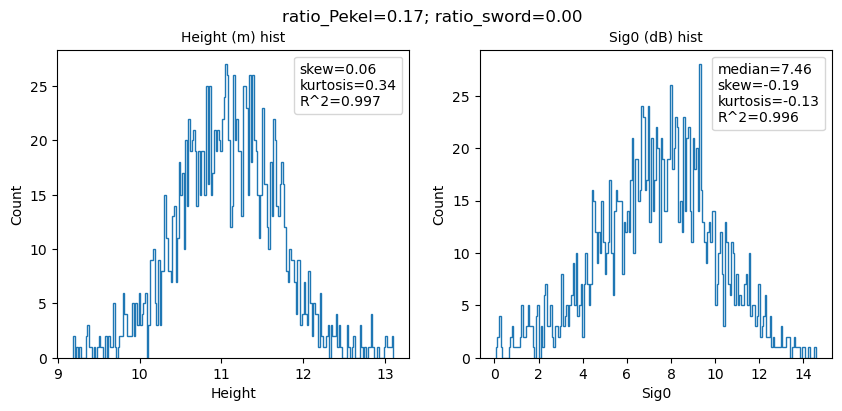

2026-02-16 16:10:31,855 [INFO] Ratio pekel, ratio sword: 0.029936305732484077, 0.0
2026-02-16 16:10:31,855 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):14.253314971923828, 0.30543193221092224, -0.14132407307624817, -0.09264802932739258, -0.048880577087402344, 0.9927668389529306, 0.9980090932636203


Body type: LAND

Processing Label 105 / 131


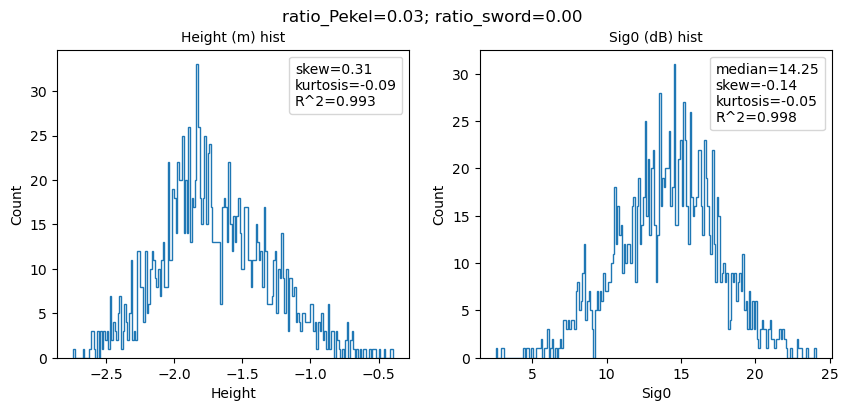

2026-02-16 16:10:32,118 [INFO] Ratio pekel, ratio sword: 0.006389776357827476, 0.0
2026-02-16 16:10:32,118 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):13.517019271850586, -0.3369143009185791, -0.23515699803829193, -0.38312673568725586, -0.1148686408996582, 0.9860591146691889, 0.9960634568323647


Body type: LAND

Processing Label 106 / 131


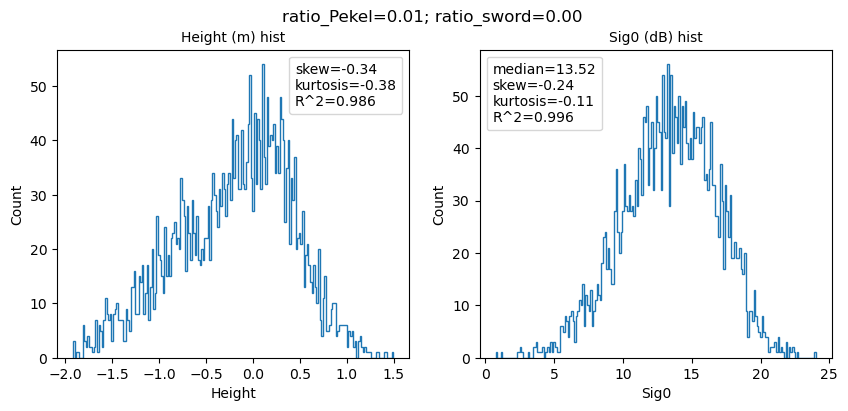

2026-02-16 16:10:32,410 [INFO] Ratio pekel, ratio sword: 0.023921200750469045, 0.0
2026-02-16 16:10:32,410 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):11.845684051513672, 0.24300771951675415, -0.12429032474756241, -0.6945188045501709, -0.07694292068481445, 0.9837690496304594, 0.9988207564474618


Body type: LAND

Processing Label 107 / 131


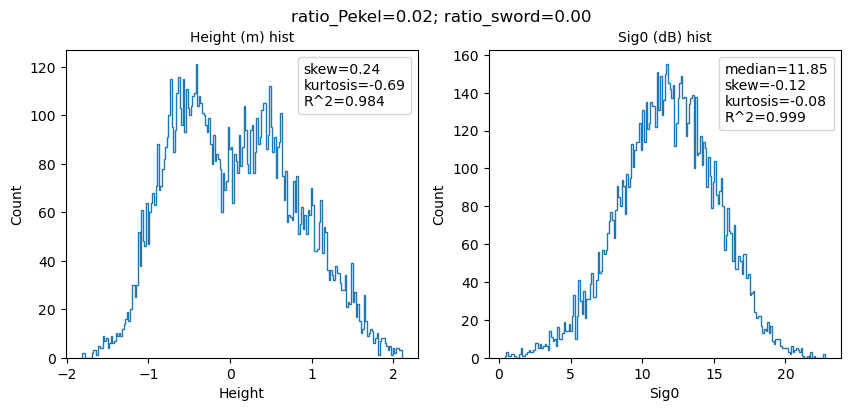

2026-02-16 16:10:32,686 [INFO] Ratio pekel, ratio sword: 0.7337239583333334, 0.0
2026-02-16 16:10:32,686 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):7.099948883056641, 0.28375643491744995, -0.14756247401237488, -0.1317143440246582, -0.25356149673461914, 0.9926340308035769, 0.9963562321538582


Body type: LAND

Processing Label 108 / 131


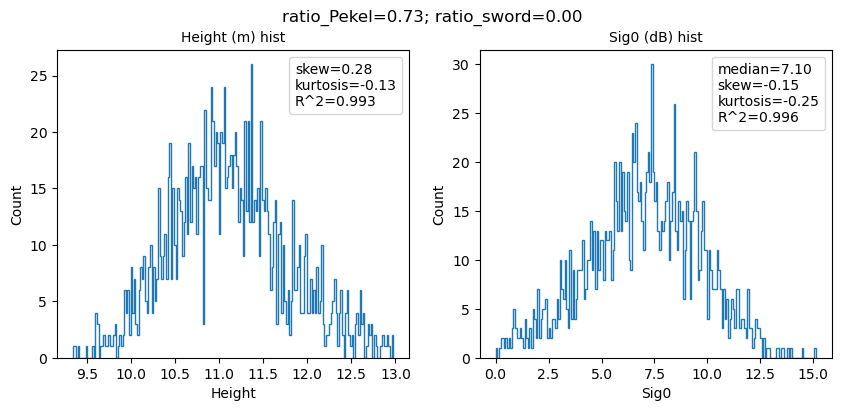

/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point 87.015322571858178 26.469714558994163
  return _ogr.Geometry_IsValid(self, *args)
2026-02-16 16:10:32,965 [INFO] Ratio pekel, ratio sword: 0.010606060606060607, 0.0
2026-02-16 16:10:32,966 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):14.109906196594238, -0.20358096063137054, -0.1409994512796402, -0.15394091606140137, -0.16018295288085938, 0.9858012150894353, 0.9982159438548117


Body type: WATER
Bathtub ring method is applied

Processing Label 109 / 131


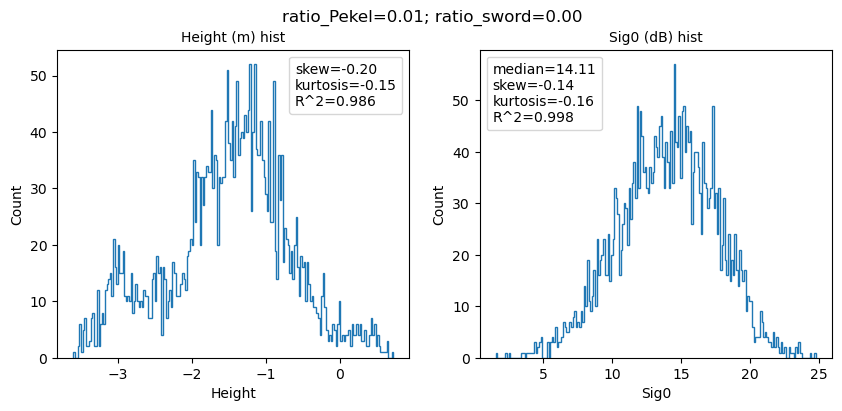

2026-02-16 16:10:33,236 [INFO] Ratio pekel, ratio sword: 1.0, 0.6520046710782406
2026-02-16 16:10:33,237 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):10.304384231567383, 0.2046246975660324, 0.4449502229690552, -0.23311543464660645, 0.20524191856384277, 0.9948603863412161, 0.9874384400434647


Body type: LAND

Processing Label 110 / 131


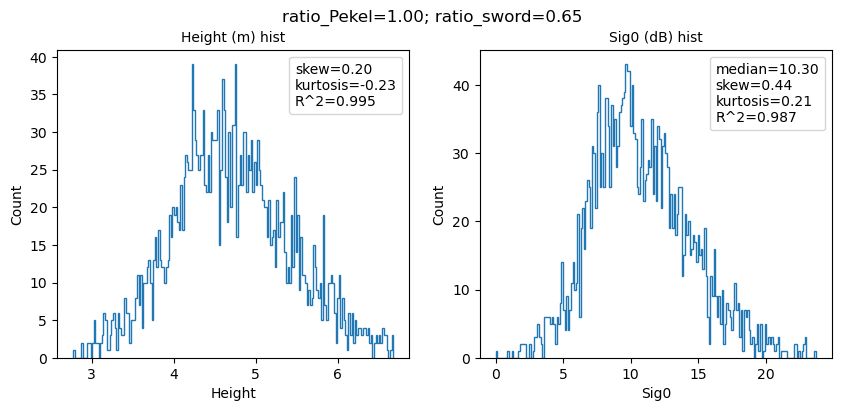

2026-02-16 16:10:33,530 [INFO] Ratio pekel, ratio sword: 0.08151382823871907, 0.0
2026-02-16 16:10:33,530 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):14.242844581604004, 0.1630050390958786, -0.1716836392879486, -0.8096051216125488, -0.18692231178283691, 0.9825105670076681, 0.9974193867820441


Body type: WATER
Bathtub ring method is applied

Processing Label 111 / 131


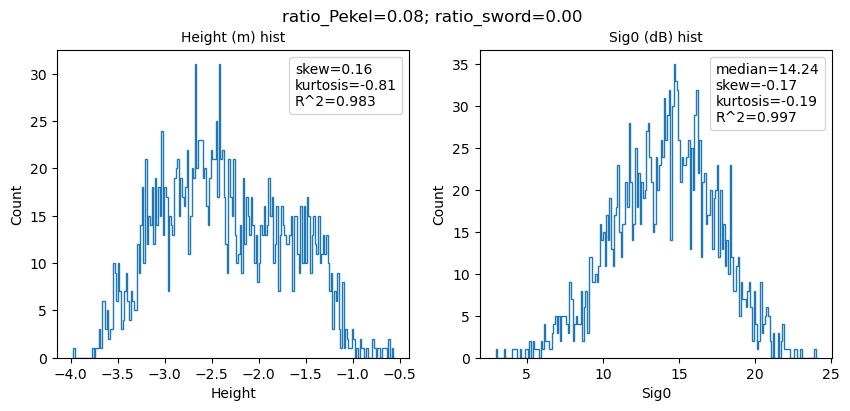

2026-02-16 16:10:33,812 [INFO] Ratio pekel, ratio sword: 0.014985014985014986, 0.0
2026-02-16 16:10:33,813 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):9.109452247619629, -0.005413086619228125, -0.19927263259887695, -0.5022978782653809, -0.009640216827392578, 0.9938985888234585, 0.9974145295183394


Body type: LAND

Processing Label 112 / 131


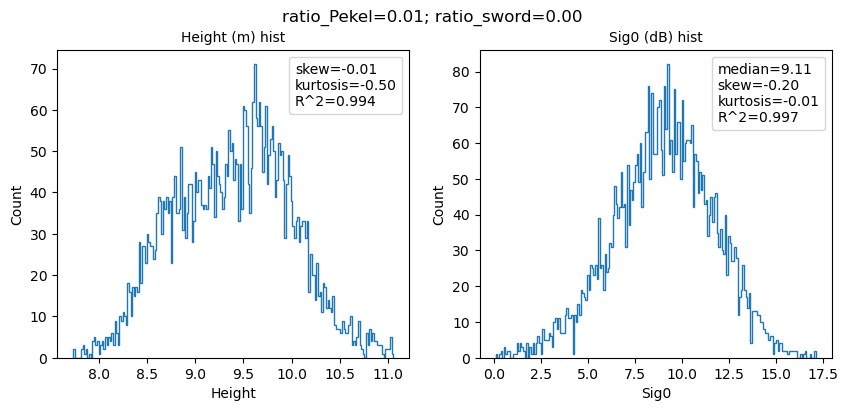

2026-02-16 16:10:34,089 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-16 16:10:34,090 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.508868217468262, 0.4623488485813141, -0.22915366291999817, 0.25543928146362305, -0.19701838493347168, 0.9852415175504994, 0.9953694593358036


Body type: LAND

Processing Label 113 / 131


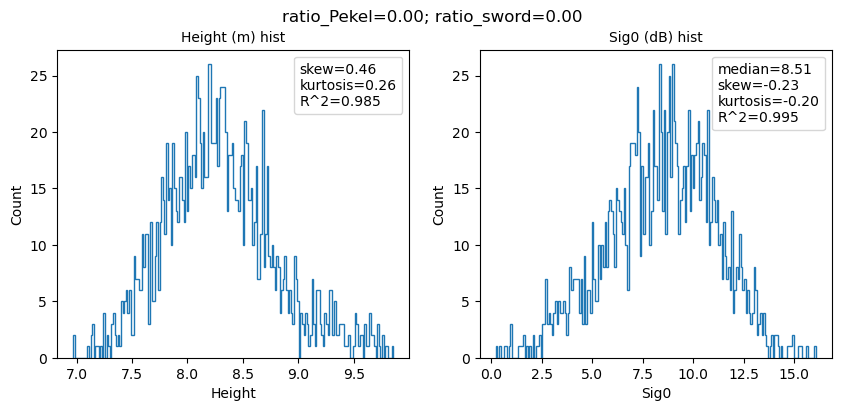

2026-02-16 16:10:34,371 [INFO] Ratio pekel, ratio sword: 0.0004583301504850661, 0.0
2026-02-16 16:10:34,371 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.16517162322998, -0.31805652379989624, -0.20503206551074982, -0.29640960693359375, 0.09544849395751953, 0.9827404266500381, 0.996281017759117


Body type: LAND

Processing Label 114 / 131


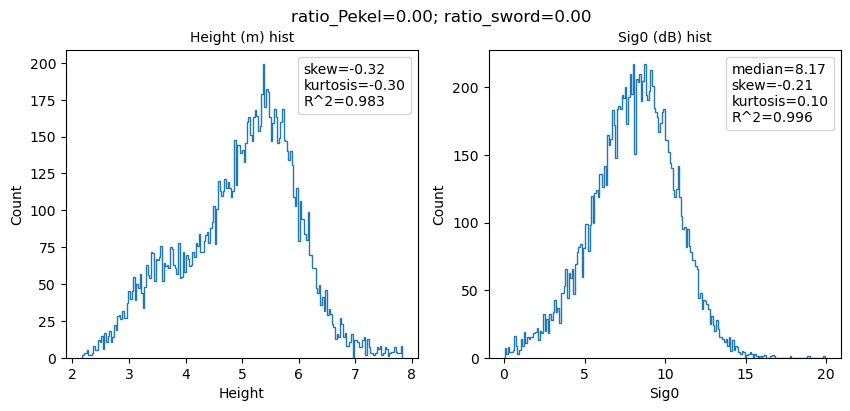

2026-02-16 16:10:34,647 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-16 16:10:34,647 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.913382530212402, 0.6012925505638123, -0.226904958486557, 0.46517109870910645, 0.16828393936157227, 0.9748150305462582, 0.9946961805170942


Body type: LAND

Processing Label 115 / 131


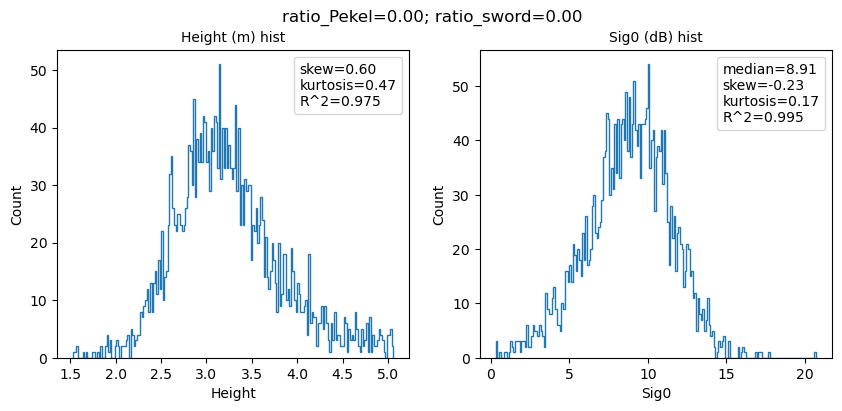

2026-02-16 16:10:34,926 [INFO] Ratio pekel, ratio sword: 0.0005045408678102926, 0.04053144971409351
2026-02-16 16:10:34,927 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):15.787728309631348, 0.20672833919525146, -0.23884162306785583, -0.5436909198760986, -0.08002853393554688, 0.9880534182410827, 0.9962202020549646


Body type: LAND

Processing Label 116 / 131


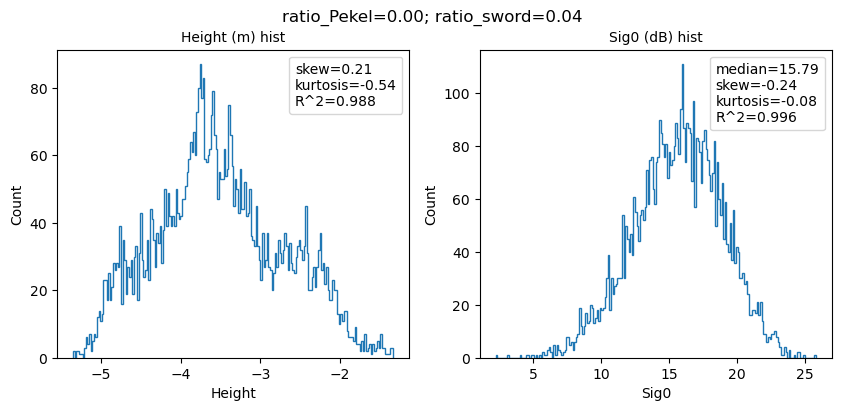

2026-02-16 16:10:35,185 [INFO] Ratio pekel, ratio sword: 0.0007551729346020238, 0.0
2026-02-16 16:10:35,185 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):9.953736305236816, 0.977424681186676, -0.16080522537231445, 1.115060806274414, 0.10370254516601562, 0.9415406958125211, 0.9981444599471351


Body type: LAND

Processing Label 117 / 131


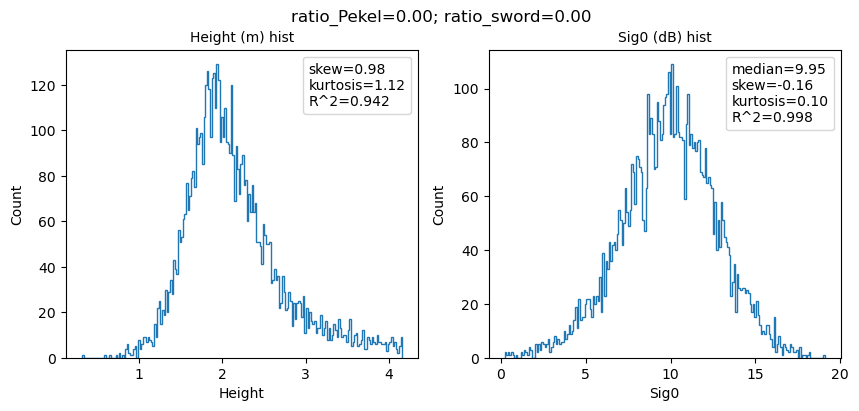

2026-02-16 16:10:35,475 [INFO] Ratio pekel, ratio sword: 0.011658031088082901, 0.0
2026-02-16 16:10:35,475 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):9.069016456604004, 0.015064982697367668, -0.17069295048713684, -0.6605362892150879, 0.010133981704711914, 0.9915385675549955, 0.9979446084334628


Body type: LAND

Processing Label 118 / 131


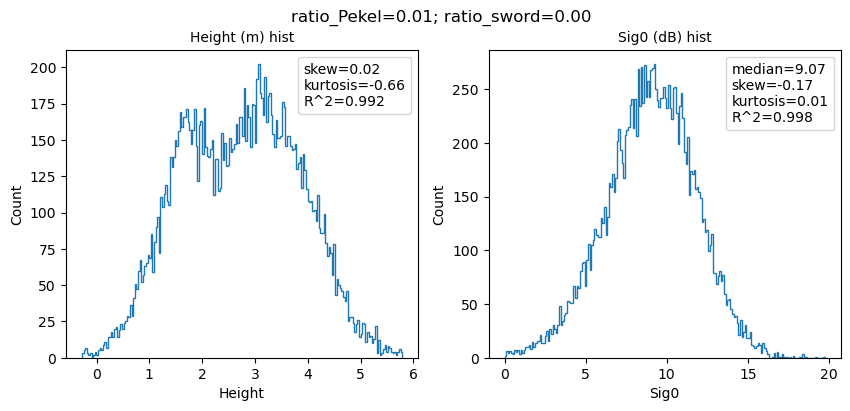

2026-02-16 16:10:35,743 [INFO] Ratio pekel, ratio sword: 0.007982969664715274, 0.0
2026-02-16 16:10:35,743 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.7025146484375, 0.24002507328987122, -0.140787735581398, -0.04402971267700195, -0.012530803680419922, 0.9954508106211408, 0.9978637136557637


Body type: LAND

Processing Label 119 / 131


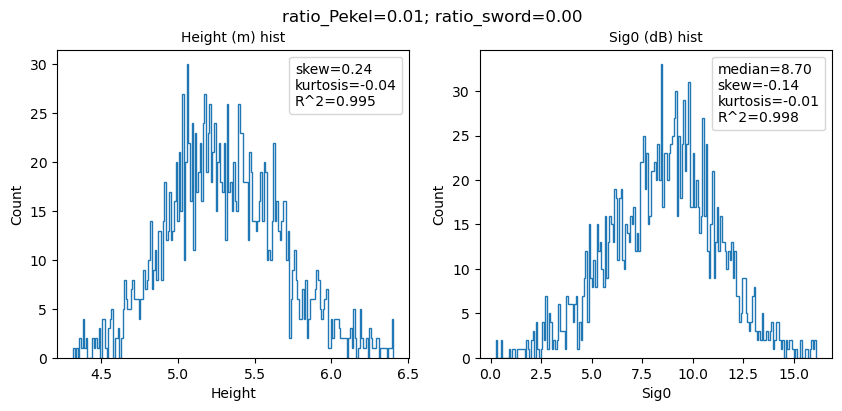

/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
2026-02-16 16:10:36,005 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-16 16:10:36,005 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.215439796447754, -0.10262173414230347, -0.3633578419685364, -0.14380741119384766, -0.08832645416259766, 0.9981734758225882, 0.9903447249335566


Body type: LAND

Processing Label 120 / 131


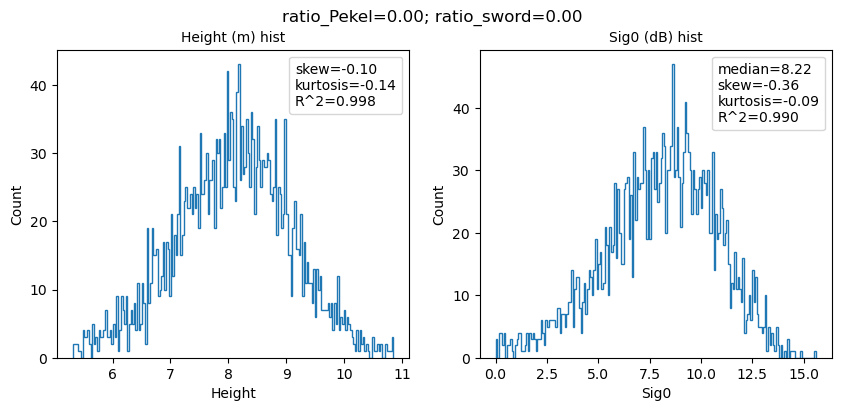

2026-02-16 16:10:36,264 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-16 16:10:36,265 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.692873001098633, 0.46809467673301697, -0.13991636037826538, 0.36900854110717773, 0.37862253189086914, 0.9833083077079243, 0.9941690924246004


Body type: LAND

Processing Label 121 / 131


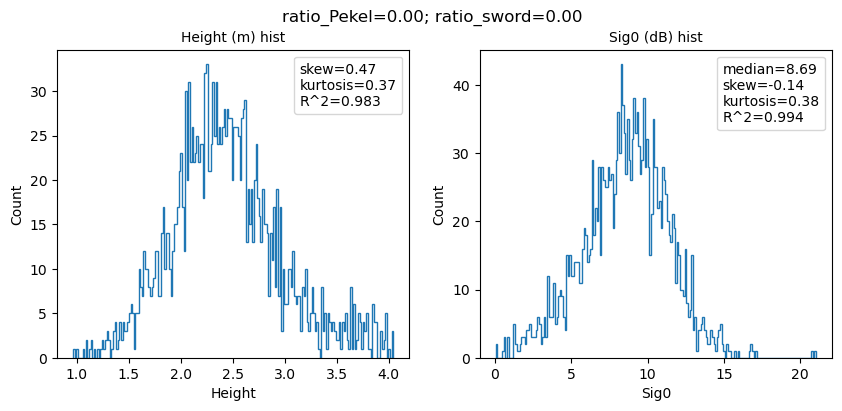

2026-02-16 16:10:36,525 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-16 16:10:36,526 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.751907348632812, 0.23226529359817505, -0.10268931090831757, 0.15943431854248047, 0.04345822334289551, 0.9958527627657395, 0.9983211374339507


Body type: LAND

Processing Label 122 / 131


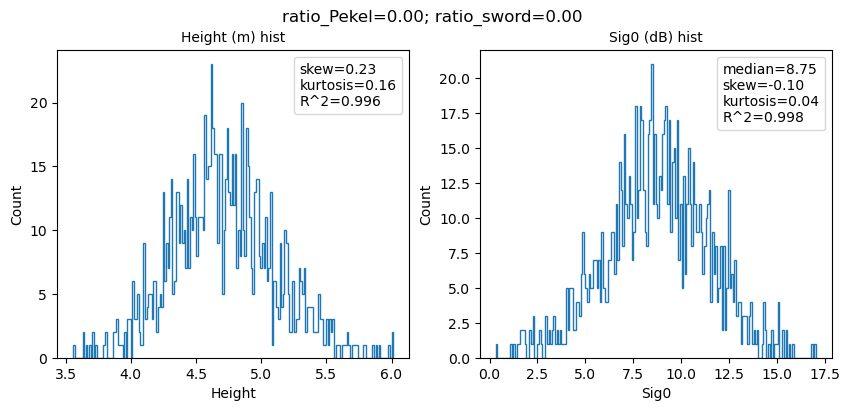

/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
2026-02-16 16:10:36,795 [INFO] Ratio pekel, ratio sword: 0.013207547169811321, 0.0
2026-02-16 16:10:36,796 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):7.169389724731445, -0.001446978305466473, -0.08516733348369598, -0.25028038024902344, -0.38234424591064453, 0.9987973049633675, 0.9970036231224071


Body type: LAND

Processing Label 123 / 131


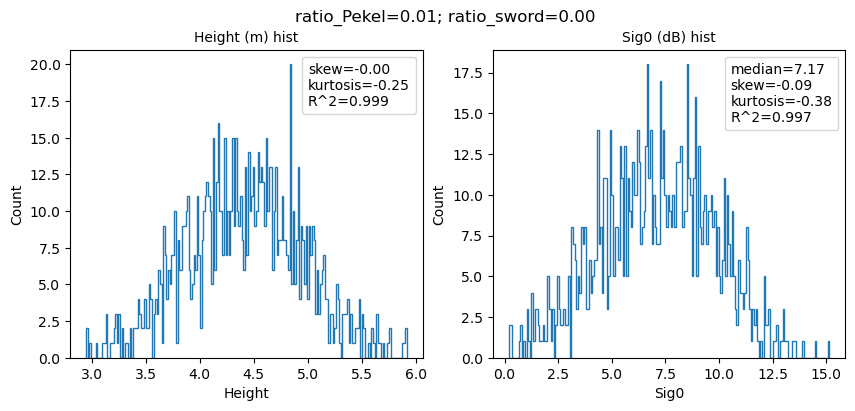

2026-02-16 16:10:37,078 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-16 16:10:37,078 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):9.524496078491211, 0.8756709098815918, -0.11761967092752457, 0.5759549140930176, 0.00021147727966308594, 0.9462958264529978, 0.9983908038264911


Body type: LAND

Processing Label 124 / 131


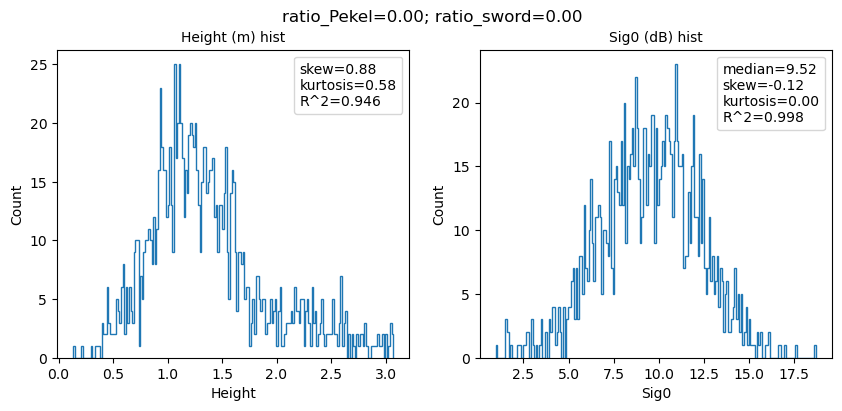

2026-02-16 16:10:37,344 [INFO] Ratio pekel, ratio sword: 0.9370693615066605, 0.5720410350635431
2026-02-16 16:10:37,344 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):16.978370666503906, -0.1959470808506012, 0.03842724859714508, -1.0830390453338623, -0.742067813873291, 0.9546187229765943, 0.9892813774635407


Body type: LAND

Processing Label 125 / 131


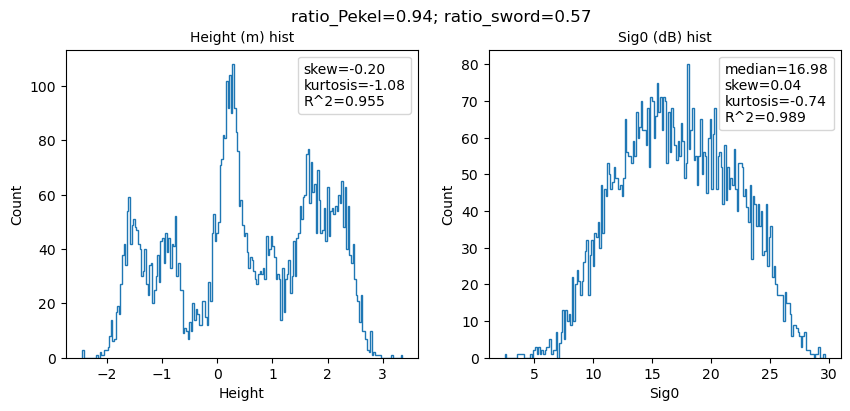

2026-02-16 16:10:37,699 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-16 16:10:37,700 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):9.634264945983887, 0.0840095803141594, -0.07905743271112442, -0.023164749145507812, -0.023473262786865234, 0.9977032788275019, 0.999074025862942


Body type: WATER
Bathtub ring method is applied

Processing Label 126 / 131


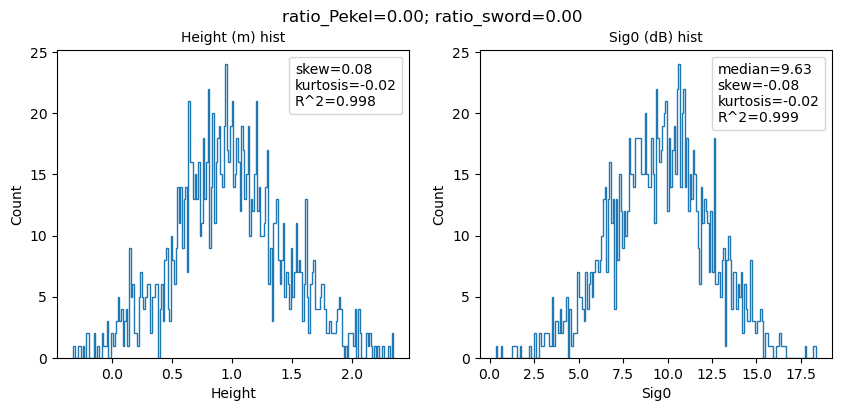

2026-02-16 16:10:38,885 [INFO] Ratio pekel, ratio sword: 0.00039909538379672744, 0.0
2026-02-16 16:10:38,886 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.830399513244629, 0.1349235624074936, -0.1716909408569336, -0.07822203636169434, -0.0008573532104492188, 0.9973894660283926, 0.9976017178074389


Body type: LAND

Processing Label 127 / 131


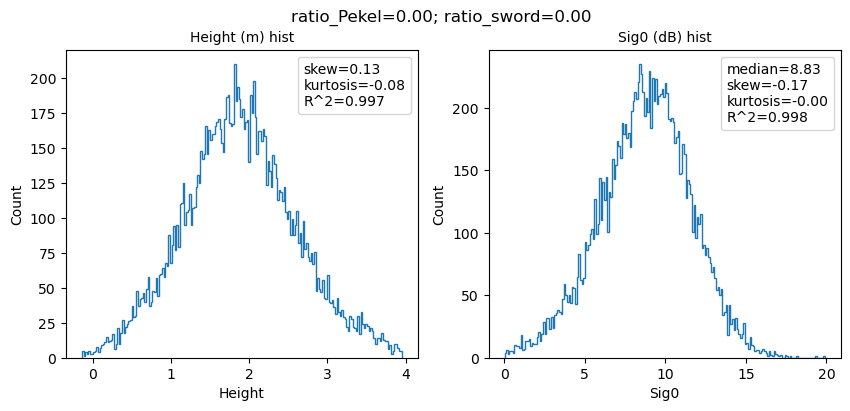

2026-02-16 16:10:39,152 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-16 16:10:39,153 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):9.056293487548828, 0.4915339946746826, -0.2375776469707489, 0.008657455444335938, 0.049764156341552734, 0.9820090043202153, 0.9954206893346823


Body type: LAND

Processing Label 128 / 131


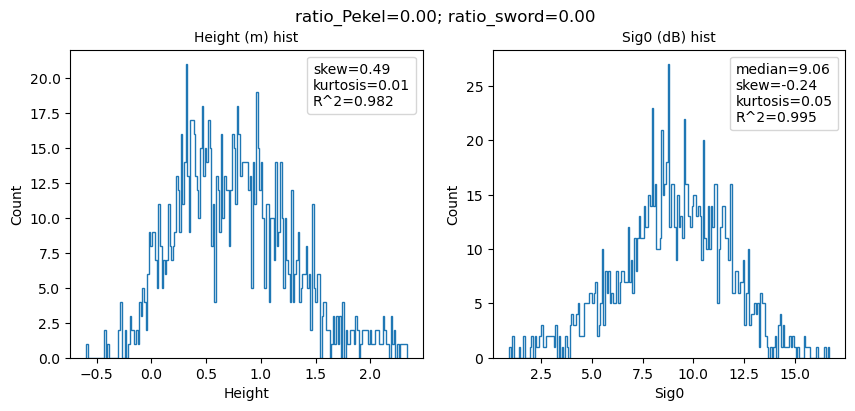

2026-02-16 16:10:39,420 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-16 16:10:39,420 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.671650886535645, 0.19368429481983185, -0.1880371868610382, -0.1008903980255127, 0.22296929359436035, 0.9958205116799881, 0.9951049592546908


Body type: LAND

Processing Label 129 / 131


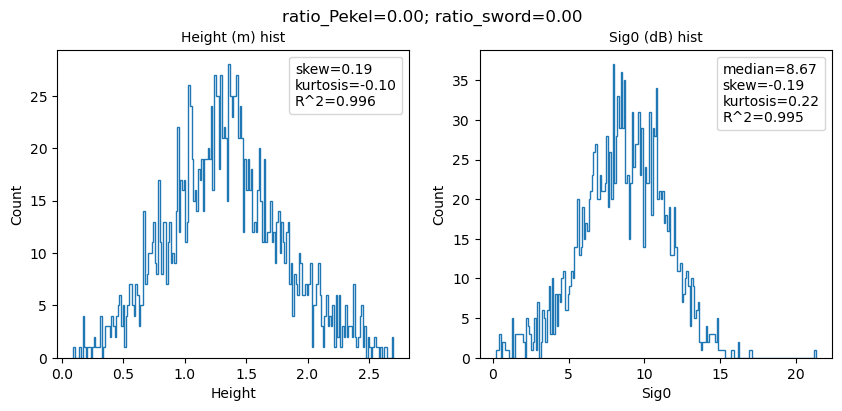

2026-02-16 16:10:39,688 [INFO] Ratio pekel, ratio sword: 0.005396430053964301, 0.0
2026-02-16 16:10:39,689 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):10.190921783447266, 0.518856942653656, -0.20117467641830444, -0.008065223693847656, -0.15213370323181152, 0.9796474897105553, 0.9961579402029631


Body type: LAND

Processing Label 130 / 131


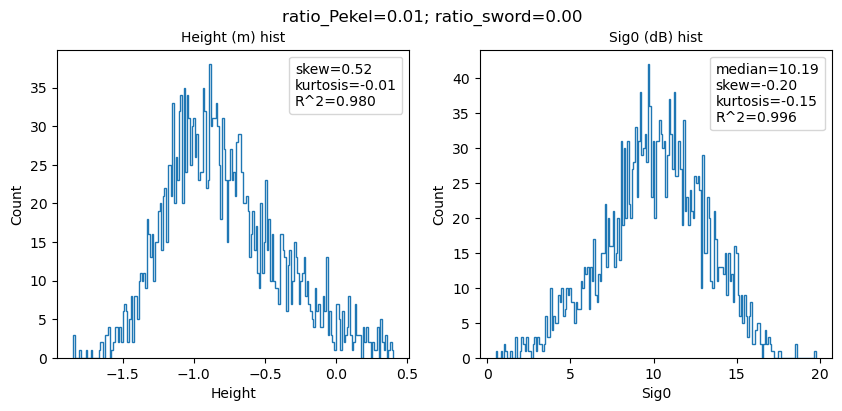

2026-02-16 16:10:39,958 [INFO] Ratio pekel, ratio sword: 0.006711409395973154, 0.0
2026-02-16 16:10:39,959 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):9.662822723388672, 1.5382657051086426, -0.2638973593711853, 3.1747493743896484, 0.2487332820892334, 0.8717017562801914, 0.9950702758421415


Body type: LAND

Processing Label 131 / 131


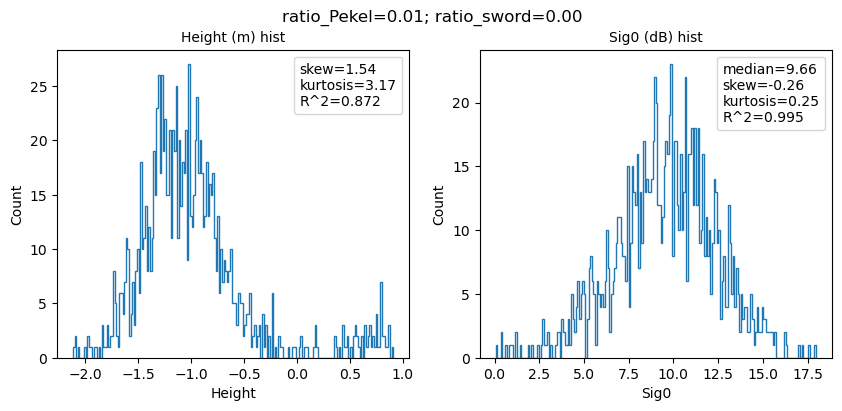

Body type: LAND


2026-02-16 16:31:18,068 [INFO] Filtering using flags


In [11]:
# Load class FloodPlain, necessary for access to bathtub ring subroutine
fpdem = Floodplain(None)

# Initialize main FPDEM dataframe
fpdem_land = pd.DataFrame()

# Loop over all PIXC files
for ip, pixc_file in enumerate(inputpixcfiles):
    
    print(f"Processing PIXC {ip+1}/{len(inputpixcfiles)}")
    
    cycle = os.path.basename(pixc_file)[16:19]
    if os.path.isdir(os.path.join(output_dir, f'cycle{cycle}')) is False:
        os.mkdir(os.path.join(output_dir, f'cycle{cycle}'))
    
    # Get PIXCVec file (currently not used at all -- commented lines in floodplain/io/nc.py)
    vec_file = inputvecfiles[ip]
    # Load PixcReader class, and read pixc file
    pixc_reader = PixcReader(polygon_mask, pixc_file, vec_file)

    # Pre-processing of PIXC: extract water points (classification > 2), exclude near-range points, 
    # and clusters whose area is smaller than the given threshold
    water, min_range_ind_to_remove = pre_processing_pixc(pixc_reader, 
                                                         cross_track_min, threshold, 
                                                         sig0_qual)

    # Select only points of classification 3, 4 and some 5 if in Pekel mask 95%-100%,
    # remove all isolated points if some remains in pre-processing,
    # and define clusters / label the detected water bodies
    label_tab, count, classification_tab, \
               height_tab, sig0_tab, \
               azimuth_index_tab, range_index_tab, \
               latitude_tab, \
               longitude_tab = compute_label_and_remove_small_object(water,
                                                                     pixc_reader.range_size, pixc_reader.azimuth_size,
                                                                     pekel_X_100_poly,
                                                                     body_min_size, body_connectivity, 
                                                                     plot=plot, outpath=output_dir, cycle=cycle)
    print(f"Number of water bodies found : {count}")
    
    # Initialize selected PIXC FPDEM dataframe
    fpdem_land_pixc = pd.DataFrame()
    
    # Loop over all detected water bodies in the PIXC
    for label in range(1, count+1):
        
        print(f"\nProcessing Label {label} / {count}")
        
        # Return water_extract (-> GeoDataFrame), only points corresponding to the processed label
        water_extract = compute_subwater_extract_from_label(water, label_tab, 
                                                            azimuth_index_tab, range_index_tab, label)
        if len(water_extract) == 0:
            continue
        
        if approach == 'mixed':
            # TODO: Delete once the new PIXC products have corrected dark_water elevation
            #       At the moment the dark water height is too bad to be used in categorization of bodies
            # This geodataframe is used to parametrize the water body and select its type (land, water or land_water)
            water_extractCateg = water_extract[(water_extract.classification == 3) | 
                                               (water_extract.classification == 4)]
            if len(water_extractCateg) == 0:
                continue
                
            # Plot height and sig0
            if plot == 'yes':
                height_to_plot = np.where(label_tab == label, height_tab, 0)[l0:l1, c0:c1]
                height_to_plot[np.where(height_to_plot == 0)] = np.nan
                sig_to_plot = 10*np.log10(np.where(label_tab == label, sig0_tab, 0)[l0:l1, c0:c1])
                sig_to_plot[np.where(sig_to_plot == 0)] = np.nan
                fig, (ax, ax2) = plt.subplots(nrows=1, ncols=2, layout='constrained')
                ax.set_title("Height(m) for cycle: " + cycle + "-- label: " + str(label))
                im = ax.imshow(height_to_plot)
                fig.colorbar(im, shrink=0.5, ax=ax)
                ax2.set_title("Sig0 (dB)")
                im2 = ax2.imshow(sig_to_plot)
                fig.colorbar(im2, shrink=0.5, ax=ax2)
                plt.show()

            # Find the category the water body belongs to
            water_body_type, categ_params = find_body_category(water_extractCateg, pekel_0_100_poly, poly_sword, plot=plot)
            print(f"Body type: {water_body_type}")

            # Apply different method depending on body category
            # LAND => direct extraction
            # WATER => Bathtub ring method
            # WATER_LAND => clustering method
            #         LAND => direct extraction
            #         WATER => Bathtub ring method
            if water_body_type == "LAND":
                fpdem_land_pixc = pd.concat([fpdem_land_pixc, water_extract[['longitude', 'latitude',
                                                                               'height', 'sig0', 'classification',
                                                                               'azimuth_index', 'range_index']]])
                
            elif water_body_type == "WATER":
                print('Bathtub ring method is applied')
                res_bathtub = fpdem.compute_bathtub_method(water_extract)
                fpdem_land_pixc = pd.concat([fpdem_land_pixc, res_bathtub])
                
            elif water_body_type == "WATER_LAND":
                print('Clustering method is applied')
                
                # Over one cycle (selected or first one of the list) extract height 
                # to obtain range and azimuth extrema
                l0, l1, c0, c1 = get_range_azimuth_extrema(water_extract, 
                                                           pixc_reader.range_size, pixc_reader.azimuth_size)
            
                # Create 4D matrix with all variables used for clustering (h, sig0, lon, lat)
                sub_image = prepare_clustering_image(height_tab, sig0_tab, latitude_tab, longitude_tab,
                                                     label_tab, label, l0, l1, c0, c1)
                
                # Load class Clustering_Method and initialize its variables
                clust = Clustering_Method(sub_image, label, output_dir, cycle, plot=plot)
                
                # Filter outliers and normalize height and sig0
                clust.normalize_data(filter_method=clustering_outlier_filter_method) # isolation_forest/zscore
                
                if clustering_method == 'birch' or clustering_method == 'kmeans':
                    clust.clustering_method(method=clustering_method)
                elif clustering_method == 'hdbscan_tsne':
                    clust.tsne()
                    clust.clustering_tsne_hdbscan()
                else:
                    clust.umap()
                    clust.clustering_umap_hdbscan()
                
                # Categorize the different clusters into LAND or WATER
                clust.get_water_soil_labels(water_extract, pekel_0_100_poly, poly_sword)

                # For WATER cluster
                if clust.sub_img_labeled_water is not None:
                    geom = gpd.points_from_xy(clust.sub_img_labeled_water[:, 2], 
                                              clust.sub_img_labeled_water[:, 3])
                    water_extract_w = water_extract[water_extract.geometry.isin(geom)]
                    
                    if clustering_contour == 'bathtub':
                        res_bathtub = fpdem.compute_bathtub_method(water_extract_w)
                    elif clustering_contour == 'concavehull':
                        concave_hull = gpd.GeoSeries([MultiPoint(water_extract_w['geometry'].values)]).concave_hull(ratio=0.05,
                                                                                                                    allow_holes=True)
                        list_coords = shapely.get_coordinates(concave_hull.exterior).tolist()
                        res_bathtub = gpd.GeoDataFrame(geometry=[Point(i) for i in list_coords], crs=4326)
                        res_bathtub['longitude'] = pd.Series(res_bathtub.geometry.get_coordinates().x.values)
                        res_bathtub['latitude'] = pd.Series(res_bathtub.geometry.get_coordinates().y.values)
                        col_list = ['height', 'sig0', 'azimuth_index', 'range_index', 'classification']
                        res_bathtub[col_list] = res_bathtub.apply(find_attributes, args=(water, 2,), axis=1)
                        res_bathtub = res_bathtub.drop(['geometry'], axis=1)
                        
                    fpdem_land_pixc = pd.concat([fpdem_land_pixc, res_bathtub])
                    
                # For LAND cluster
                if clust.sub_img_labeled_land is not None:
                    geom = [Point(lon, lat) for lon, lat in zip(clust.sub_img_labeled_land[:, 2], 
                                                                clust.sub_img_labeled_land[:, 3])]
                    water_extract_l = water_extract[water_extract.geometry.isin(geom)]
                    fpdem_land_pixc = pd.concat([fpdem_land_pixc, water_extract_l[['longitude', 'latitude',
                                                                                    'height', 'sig0', 'classification',
                                                                                    'azimuth_index', 'range_index']]])

        elif approach == 'bathtub':
            res_bathtub = fpdem.compute_bathtub_method(water_extract)
            fpdem_land_pixc = pd.concat([fpdem_land_pixc, res_bathtub])

            
    # Remove borders points
    range_min = int(np.min(fpdem_land_pixc.range_index))
    range_max = int(np.max(fpdem_land_pixc.range_index))
    fpdem_land_pixc = remove_borders(fpdem_land_pixc.copy(), range_min, range_max-1,
                                     pixc_reader.azimuth_min, pixc_reader.azimuth_max-1,
                                     min_range_ind_to_remove)
    
    # Filter according to user defined lat-lon box
    try:
        fpdem_land_pixc = fpdem_land_pixc.loc[(fpdem_land_pixc['longitude'] > longitude_min) &
                                              (fpdem_land_pixc['longitude'] < longitude_max) &
                                              (fpdem_land_pixc['latitude'] > latitude_min) &
                                              (fpdem_land_pixc['latitude'] < latitude_max)]
    except:
        print('No filtering on latitude and longitude as none seems to be givven as inputs')
    
    # Add quality flags, time and elevation columns
    fpdem_land_pixc[['classification_qual', 'geolocation_qual',
                      'time', 'elevation']] = fpdem_land_pixc.apply(find_attributes, args=(water, 1,), axis=1)
    
    # Flag filtering (more could be added later on)
    fpdem_land_pixc = filter_data_based_on_quality_flag(fpdem_land_pixc, 
                                                        classification_qual, geolocation_qual)

    # Get utm coordinates
    lambdafunc = lambda row: pd.Series([*utm.from_latlon(row['latitude'], row['longitude'])[0:2], row['height']])
    fpdem_land_pixc[['x', 'y', 'z']] = fpdem_land_pixc.apply(lambdafunc, axis=1)
            
    # Merge all PIXC results
    fpdem_land = pd.concat([fpdem_land, fpdem_land_pixc])
        

In [12]:
# Transforming the Dataframe with all results into a GeoDataFrame
geom = gpd.points_from_xy(fpdem_land.longitude, fpdem_land.latitude)
fpdem_land = gpd.GeoDataFrame(fpdem_land, geometry=geom, crs=water.crs)

# Removing/filtering points (from Pekel if selected and isolated points)

1 - Remove all points if within Pekel occurrences >X2% (defined in parameter 'filtering_pekel_end_val' at the beginning of the code)

2 - Remove isolated points using DBSCAN

In [13]:
# Some final filtering on the FPDEM results
res_data = final_filtering_FPDEM_results(fpdem_land, filtering_pekel_end, pekel_X2_100_poly,
                                         distance_to_neighbors, number_of_neighbors, output_dir)

2026-02-16 16:32:31,166 [INFO] Remove isolated points
2026-02-16 16:32:35,798 [INFO]         69 points were removed
/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
2026-02-16 16:32:44,116 [INFO] Created 588,536 records
2026-02-16 16:32:44,136 [INFO] The results of DBSCAN labeling were written in file "results_fpdem_labels_dbscan.shp" 


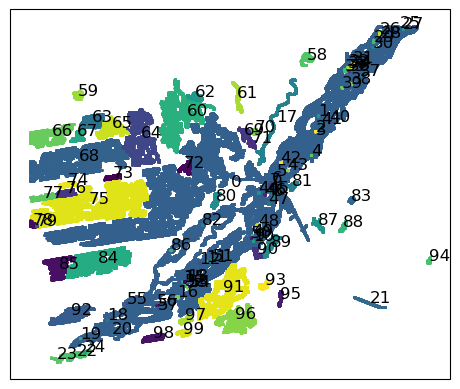

In [14]:
# Plot all clusters on which area extraction/polygonization will be performed
N_cluster = len(np.unique(res_data.lab_dbscan.values))
fig = plt.figure()
ax1 = fig.add_subplot(111, projection=tiler.crs)
cmap = plt.get_cmap('viridis')
colors = [cmap(i) for i in np.linspace(0, 1, N_cluster)]
random.shuffle(colors)
for k, color in enumerate(colors, start=0):
    res_data2 = res_data[res_data.lab_dbscan == k]
    ax1.scatter(res_data2.longitude.values, res_data2.latitude.values, c=np.array([color]), s=1)
    lon_avg = (np.min(res_data2.longitude) + np.max(res_data2.longitude)) / 2
    lat_avg = (np.min(res_data2.latitude) + np.max(res_data2.latitude)) / 2
    ax1.annotate(k, xy=(lon_avg, lat_avg), xycoords='data', color='black', fontsize=12)
plt.show()

# Plotting ungridded FPDEM results

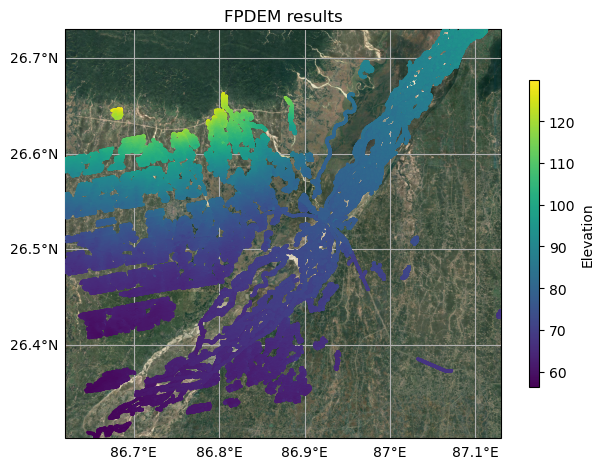

In [15]:
extent = [np.min(res_data.longitude.values), np.max(res_data.longitude.values), 
         np.min(res_data.latitude.values), np.max(res_data.latitude.values)]
hmin = min(res_data.elevation.values)
hmax = max(res_data.elevation.values)

fig = plt.figure(layout='tight')
ax = fig.add_subplot(1, 1, 1, projection=tiler.crs)
ax.set_title(f'FPDEM results')
ax.set_extent(extent, geodetic)
ax.add_image(tiler, 13)
cs = res_data.plot(ax=ax, kind='scatter', x='longitude', y='latitude', c="elevation", 
               zorder=5, transform=wgs84, s=1, vmin=hmin, vmax=hmax, colorbar=False)
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=hmin, vmax=hmax))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.75, aspect=30, label='Elevation')
gl = ax.gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False

plt.show()

# Write FPDEM ungridded file

In [16]:
fpdem.res_pointcloud = res_data
fpdem.inputpixcfiles = inputpixcfiles
fpdem.inputvecfiles = inputvecfiles
fpdem.output_path = output_dir
fpdem.tile_name = tile_name
fpdem.first_date_name = first_date
fpdem.last_date_name = last_date

In [17]:
fpdem.write_fpdem_pointcloud_output()

2026-02-16 16:32:52,765 [INFO] Writing the ungridded netcdf with FPDEM results
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/toshp.py:37: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  'range_index', 'azimuth_index', 'time']].to_file(filename, driver=driver, schema=schema, crs=prj,
2026-02-16 16:33:09,925 [WARNING] Normalized/laundered field name: 'range_index' to 'range_inde'
2026-02-16 16:33:09,925 [WARNING] Normalized/laundered field name: 'azimuth_index' to 'azimuth_in'
2026-02-16 16:33:56,739 [INFO] Writing FPDEM pointcloud file
2026-02-16 16:33:57,234 [INFO] Write output file: OK


# Extract Area : Get Polygons of the AOI for rasterization

In [18]:
output_fpdem_pointcloud_name = compute_name(output_dir, FPDEM_POINTCLOUD_BASENAME, tile_name,
                                            first_date, last_date)
output_mask_name = os.path.join(output_dir, FPDEM_BASENAME + MASK_SUFFIX)

In [19]:
extract_area = Extract_Area(None, 
                            input_file=output_fpdem_pointcloud_name, 
                            output_file=output_mask_name, 
                            ch_ratio=plg_ch_ratio)

extract_area.ch_ratio = plg_ch_ratio
extract_area.output_path = output_dir

In [20]:
extract_area.load_input_extract_area()
extract_area.extract_area_polygons()

2026-02-16 16:33:58,287 [INFO] There are 100 clusters (on which to extract polygons for rasterization)


# Rasterization

In [21]:
output_fpdem_raster_name = compute_name(output_dir, FPDEM_RASTER_BASENAME, tile_name,
                                        first_date, last_date)

In [22]:
fpdem_raster = FPDEM_Raster(None, 
                            input_file=output_fpdem_pointcloud_name, 
                            output_file=output_fpdem_raster_name, 
                            mask=output_mask_name)
fpdem_raster.resolution = raster_resolution
fpdem_raster.mode = raster_mode
fpdem_raster.plot = plot

zone nb and letter: 45 R


2026-02-16 16:35:41,875 [INFO] The filtering (MAD, 3sigma) removed 1204 points out of 588536.
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/scripts/process_raster.py:212: RuntimeWarning: Mean of empty slice
  dist_mean = np.nanmean(distances_filtered, axis=1)
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/scripts/process_raster.py:213: RuntimeWarning: All-NaN slice encountered
  dist_min = np.nanmin(distances_filtered, axis=1)
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/scripts/process_raster.py:224: RuntimeWarning: invalid value encountered in divide
  z = np.nansum(elevation_tab / distances_filtered, axis=1) / np.nansum(1. / distances_filtered, axis=1)
/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/pyproj/

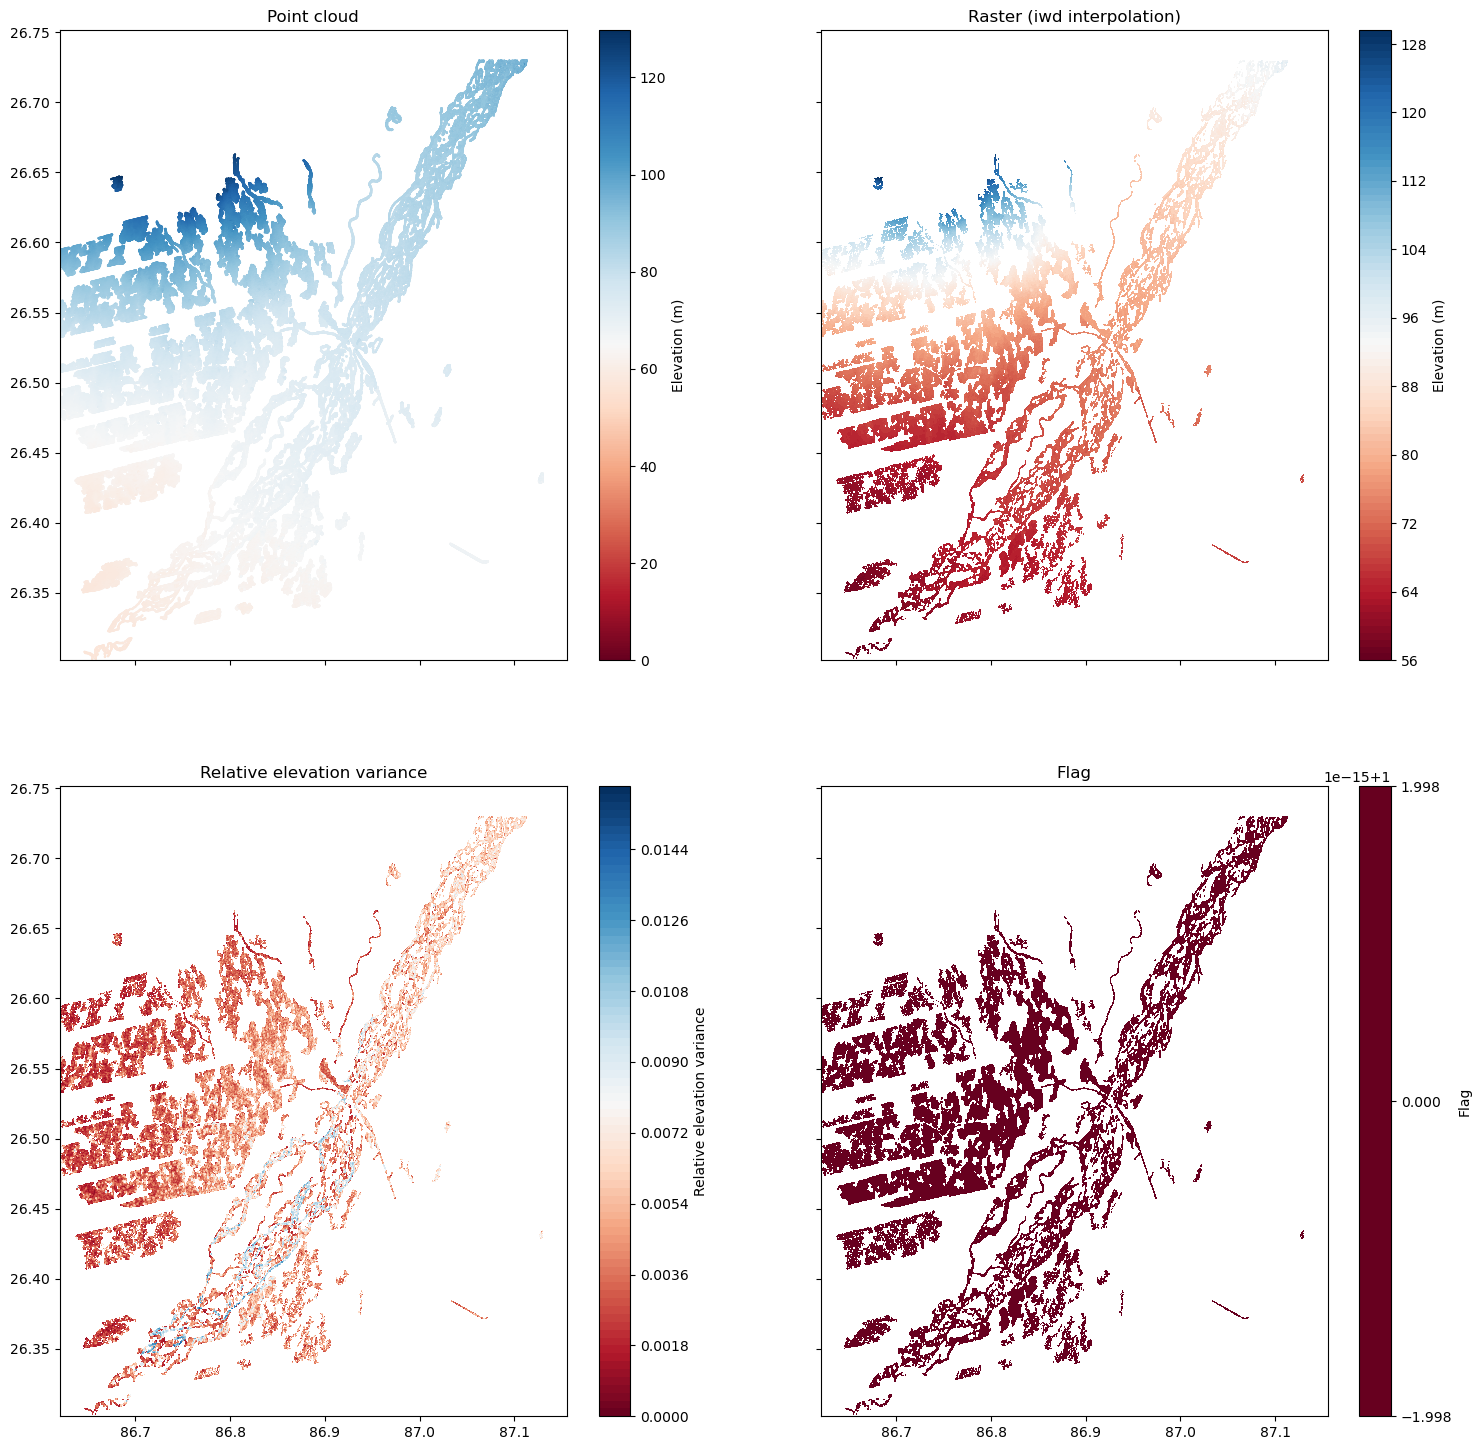

In [23]:
fpdem_raster.load_input_fpdem_raster()
fpdem_raster.compute_fpdem_raster()

In [24]:
fpdem_raster.write_fpdem_raster()

2026-02-16 16:36:12,275 [INFO] Writing FPDEM raster file
